# Load packages

In [24]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib import patches, ticker, dates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.colors import LogNorm
import seaborn as sns
import cmocean as cmo
from datetime import datetime, timedelta
import os
import glob
from tqdm import tqdm
from tqdm.notebook import tqdm as notebook
from os import chdir
import gsw as gsw
from scipy.optimize import least_squares
from sklearn.metrics import mean_squared_error, r2_score, explained_variance_score, mean_absolute_error
from sklearn.linear_model import LinearRegression, HuberRegressor
import statsmodels.api as sm
from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.stats import linregress, normaltest, shapiro, pearsonr, median_abs_deviation, entropy, norm
import pymannkendall as mk
from scipy.interpolate import PchipInterpolator
import timezonefinder, pytz
tf = timezonefinder.TimezoneFinder()
from datetime import datetime
import warnings
from ftplib import FTP
from io import BytesIO
import re
import statsmodels.formula.api as smf
import cartopy
import cartopy.crs as ccrs
from cartopy.feature import NaturalEarthFeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from sklearn.exceptions import InconsistentVersionWarning
import pickle
import pvlib
import import_ipynb
import copernicusmarine

# Set matplotlib parameters
mpl.rcParams['figure.facecolor'] = '1'
mpl.rcParams['mathtext.default'] = 'regular'

# Set font parameters
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 10}
mpl.rc('font', **font)


# Data Processing

## Define directories

In [2]:
root = '/Volumes/Tommy/BGC-ARGO'
resdir = '/Users/tommyrk/Library/CloudStorage/Dropbox/Papers - Current/BGC-Argo NPP Paper/DATA'
figdir = '/Users/tommyrk/Library/CloudStorage/Dropbox/Papers - Current/BGC-Argo NPP Paper/FINAL_FIGURES'

# This loads in a biomes file from Fay & McKinley 2014 - if you wish to look at regional variability
biomes = xr.open_dataset(f'{resdir}/Time_Varying_Biomes_25KM.nc').MeanBiomes

## Define functions for data processing

In [ ]:
def in_situ_dark(xds):
    valid_indices_chla = ~np.isnan(xds['CHLA']).all(dim='N_LEVELS')
    valid_indices_pres = xds['PRES'].max(dim='N_LEVELS') > 950
    
    valid_indices_combined = np.where(valid_indices_chla & valid_indices_pres)

    if np.all(valid_indices_combined == False):
        return np.nan

    else:
        first_5_indices = valid_indices_combined[0][:5]
    
        # Apply running median to each N_PROF CHLA with window size of 5 only for the selected columns
        chla_running_median = xds['CHLA'].rolling(N_LEVELS=5, min_periods=1, center=True).median()
        chla_running_median_first_5 = chla_running_median.isel(N_PROF=first_5_indices)
    
        # Apply the where condition and handle empty arrays
        filtered_chla = chla_running_median_first_5.where(chla_running_median_first_5 < 5, drop=True)
        
        # Check if filtered_chla has valid data before applying min
        if filtered_chla.isnull().all():
            return np.nan  # Or return another value indicating no valid data
        
        # Determine the minimum CHLA for all 5 N_PROF
        min_chla = filtered_chla.min(dim='N_LEVELS', skipna=True)
    
        # Find median of these minimums
        median_of_minimums = np.nanmedian(min_chla)
    
        return median_of_minimums

def load_bgc_argo(ds, apply_qc=True, qc_flags=None, 
                  min_depth=None, max_depth=None, depth_upper=None, 
                  res_deeper=None, res_upper=None, 
                  rolling_window=None, rolling_method=None,
                  variables_to_skip=None):

    if apply_qc is True:
        for var in ds.variables:
            if var.endswith('_QC'):
                ds[var] = ds[var].astype(float)

        qc_vars = [var for var in ds.variables if var.endswith('_QC')]

        filtered_vars = {}
        for var in ds.variables:
            if variables_to_skip and var in variables_to_skip:
                filtered_vars[var] = ds[var]
            elif var.endswith('_QC'):
                continue  # Skip QC variables
            else:
                qc_var = f"{var}_QC"
                if qc_var in ds:
                    # Prepare QC values for this variable
                    if var == 'BBP700':
                        qc_vals = qc_flags + [0]
                    else:
                        qc_vals = qc_flags
                
                    # Apply QC filtering with the adjusted values
                    filtered_vars[var] = ds[var].where(ds[qc_var].isin(qc_vals))
                else:
                    filtered_vars[var] = ds[var]

        # Create a new dataset with filtered variables
        ds = xr.Dataset(filtered_vars)
        
    if apply_qc is False:
        # Drop variables ending with '_QC'
        ds = ds.drop_vars([var for var in ds.variables if var.endswith('_QC')])
        
    upper_depth = np.arange(min_depth, depth_upper + 1, res_upper)
    lower_depth = np.arange(depth_upper + res_deeper, max_depth + 1, res_deeper)
    new_depth = np.concatenate((upper_depth, lower_depth))

    interpolated_vars = {}

    # Loop through each variable
    for var_name in ds.variables:
        # Skip the PRES variable
        if var_name == 'PRES':
            continue

        # Loop through each profile and interpolate each variable along the 'PRES' dimension
        interpolated_profiles = []
        for p in ds['N_PROF']:

            # Extract data for the current profile
            profile_data = ds.isel(N_PROF=p)

            if np.sum(np.isfinite(profile_data['PRES'])) < len(new_depth) * 0.5:
                interpolated_data = np.repeat(np.nan, len(new_depth))

            else:

                profile_data = profile_data.swap_dims({'N_LEVELS': 'PRES'})
                if profile_data['PRES'].min() > max_depth or profile_data['PRES'].max() < min_depth:
                    interpolated_data = np.repeat(np.nan, len(new_depth))

                else:
                    # Mask values outside of depth range
                    profile_data = profile_data.where((profile_data['PRES'] < max_depth) & (profile_data['PRES'] > min_depth), drop=True)
                    pres_data = profile_data['PRES']
    
                    # Extract and remove non-finite values
                    var_data = profile_data[var_name].values
    
                    if np.all(np.isnan(var_data)):
                        interpolated_data = np.repeat(np.nan, len(new_depth))
    
                    elif len(var_data) < 3:
                        interpolated_data = np.repeat(np.nan, len(new_depth))
    
                    else:
                        finite_mask = np.isfinite(var_data)
                        pres_data_finite = pres_data.values[finite_mask]
                        var_data_finite = var_data[finite_mask]
    
                        if len(var_data_finite) < 3:
                            interpolated_data = np.repeat(np.nan, len(new_depth))
    
                        else:
                            # Interpolate along the 'PRES' dimension using 'pchip' method
                            interp_func = PchipInterpolator(pres_data_finite, var_data_finite, axis=0)
                            interpolated_data = interp_func(new_depth)

            # Append the interpolated data for this profile to the list
            interpolated_profiles.append(interpolated_data)

        # Concatenate the interpolated data for all profiles along the 'N_PROF' dimension
        interpolated_var = np.stack(interpolated_profiles)

        # Store the interpolated data for this variable
        interpolated_vars[var_name] = (('N_PROF', 'PRES'), interpolated_var)

    # Create a new xarray dataset with the interpolated variables
    ds = xr.Dataset(interpolated_vars, coords={'N_PROF': ds['N_PROF'], 'PRES': new_depth})

    if rolling_method == 'median':
        ds = ds.rolling(PRES=rolling_window, min_periods=1, center=True).median()
    elif rolling_method == 'mean':
        ds = ds.rolling(PRES=rolling_window, min_periods=1, center=True).mean()
    else:
        raise ValueError('No method selected for smoothing process.')
    
    return ds

def clean_range_filter(xds, var, lower_bound, upper_bound):
    xds[var] = xds[var].where(xds[var] >= lower_bound, np.nan)
    xds[var] = xds[var].where(xds[var] <= upper_bound, np.nan)
    return xds

def filter_bbp_profiles(xds, variable='BBP700', depth_var='PRES', pres_dim='PRES', prof_dim='N_PROF', anomaly_threshold=0.03, fraction_threshold=0.1, min_bbp_threshold=0.0006, negative_fraction_threshold=0.2):
    """
    Filters profiles in an xarray.Dataset based on two criteria:
    1. More than a specified fraction of values in the BBP700 variable are anomalous (> threshold or < 0).
    2. Deep BBP700 conditions:
        - If the minimum BBP700 value at depths > 500 is less than a given threshold.
        - If more than a specified fraction of BBP700 values at depths > 500 are negative.

    Parameters:
        xds (xr.Dataset): The input dataset with dimensions PRES and N_PROF.
        variable (str): The name of the variable to filter (default: 'BBP700').
        depth_var (str): The name of the depth variable in the dataset (default: 'depth').
        pres_dim (str): The pressure dimension (default: 'PRES').
        prof_dim (str): The profile dimension (default: 'N_PROF').
        anomaly_threshold (float): The threshold for detecting anomalous values (default: 0.03).
        fraction_threshold (float): The fraction of anomalous values required to filter a profile (default: 0.1).
        min_bbp_threshold (float): The minimum BBP700 value at depth > 500 (default: 0.0006).
        negative_fraction_threshold (float): The fraction of negative BBP700 values at depth > 500 to invalidate the profile (default: 0.2).
    
    Returns:
        xr.Dataset: The modified dataset with filtered profiles set to NaN for the given variable.
    """
    # Ensure the variable exists in the dataset
    if variable not in xds:
        raise ValueError(f"Variable '{variable}' not found in the dataset.")

    # Extract the target variable
    data = xds[variable]
    depth = xds[depth_var]

    # Step 1: Filter based on anomalous BBP700 values (greater than threshold or less than 0)
    high_bbp = ((data > anomaly_threshold) | (data < 0)).sum(dim='PRES')
    all_bbp = data.notnull().sum(dim='PRES')
    high_bbp_fraction = high_bbp / all_bbp

    # Create a boolean mask for profiles to invalidate based on anomaly criteria
    filter_anomaly_test = high_bbp_fraction > fraction_threshold

    # Step 2: Filter based on deep BBP700 conditions (depth > 500)
    deep_bbp_min_test = data.where(depth > 500).min(dim=pres_dim) > min_bbp_threshold

    # Count negative BBP700 values at depths > 500
    lower_deep_count = (data.where((depth > 500) & (data < 0))).count(dim=pres_dim)
    deep_count = (data.where(depth > 500)).count(dim=pres_dim)

    # Fraction of negative BBP700 values at depths > 500
    neg_bbp_test = (lower_deep_count / deep_count) > negative_fraction_threshold

    # Combine both tests: Invalidate profile if either test is True
    filter_test = filter_anomaly_test | deep_bbp_min_test | neg_bbp_test

    # Apply the mask: Set entire profile to NaN if it meets any of the conditions
    xds[variable] = xr.where(filter_test, np.nan, data)

    # Step 3: Apply a final general filter to any remaining profiles not yet set to NaN
    # For any remaining values greater than 0.03 or less than 0, set them to NaN
    xds[variable] = xds[variable].where((data <= 0.03) & (data > 0), np.nan)

    return xds

def calculate_bbp_nap_and_phyto(xds):
    # Ensure BBP_NAP and BBP_PHY have the correct shape
    num_profiles = len(xds['N_PROF'])
    num_depths = len(xds['PRES'])
    
    # Initialize arrays to hold BBP_NAP and BBP_PHY for each profile and depth
    BBP_NAP = np.full((num_profiles, num_depths), np.nan, dtype=float)  # Shape: (N_PROF, PRES)
    BBP_PHY = np.full((num_profiles, num_depths), np.nan, dtype=float)  # Shape: (N_PROF, PRES)
    
    for prof_id in range(num_profiles):
        profile = xds.sel(N_PROF=prof_id)
        depth = profile['PRES'].values
        bbp = profile['BBP470'].values
        chla = profile['CHLA_FLUORESCENCE'].values
        
        # Find the depth of maximum Chla
        max_chla_depth = depth[np.argmax(chla)]
        
        # Restrict to depths deeper than the maximum Chla depth
        deep_mask = depth > max_chla_depth
        bbp_deep = bbp[deep_mask]
        depth_deep = depth[deep_mask]
        
        # Skip if there is no data in the deep region
        if len(bbp_deep) == 0:
            continue
        
        # Further restrict to values below the median
        median_bbp = np.median(bbp_deep)
        valid_mask = bbp_deep < median_bbp
        bbp_filtered = bbp_deep[valid_mask]
        depth_filtered = depth_deep[valid_mask]
        
        # Skip if the filtered arrays are empty
        if len(bbp_filtered) <= 3 or len(depth_filtered) <= 3:
            continue
        # Quantile regression (1% quantile)
        X = sm.add_constant(depth_filtered)
        quantile_model = sm.QuantReg(bbp_filtered, X)
        quantile_fit = quantile_model.fit(q=0.01, max_iter=5000)
        trend_line = quantile_fit.predict(sm.add_constant(depth))
        
        # Find depth horizon (first index where bbp < trend_line)
        shallow_horizon = np.argmax(bbp < trend_line)
        
        # Assign bbp,NAP
        bbp_nap = np.copy(bbp)
        bbp_nap[depth >= depth[shallow_horizon]] = bbp[depth >= depth[shallow_horizon]]  # Deep region
        bbp_nap[depth < depth[shallow_horizon]] = trend_line[depth < depth[shallow_horizon]]  # Shallow region
        
        # Calculate bbp,phyto
        bbp_phyto = bbp - bbp_nap
        
        # Store the results in the correct places
        BBP_NAP[prof_id, :] = bbp_nap
        BBP_PHY[prof_id, :] = bbp_phyto

    # Assign the calculated BBP_NAP and BBP_PHY to the original xds dataset
    xds['BBP_NAP'] = (['N_PROF', 'PRES'], BBP_NAP)
    xds['BBP_PHY'] = (['N_PROF', 'PRES'], BBP_PHY)
    
    return xds

def euphotic_depth(par, ipar1):

    if np.isnan(ipar1):
        slope = r_squared = ylen = ind = np.nan
    else:
        par = par[:int(ipar1)]
        mask = ~np.isnan(par) | (par > 0)
        x = np.arange(1, len(par)+1, 1)
        y = par[mask]
        x = x[mask]
        y = np.log(y)
        
        if len(x) >= 3:
            result = linregress(x, y)
            slope = result.slope
            r_squared = result.rvalue**2
            ylen = len(y)
            if slope == 0:
                slope = r_squared = ylen = ind = np.nan
            else:
                light_depth = np.exp((x * -1) / (-1 / slope)) * 100.0         
                ind = abs(light_depth - 1).argmin()
        else:
            slope = r_squared = ylen = ind = np.nan
    
    return slope, r_squared, ylen, ind

def calculate_solar_elevation(xds):
    """
    Compute solar elevation angle for an xarray.Dataset with LATITUDE, LONGITUDE, and DATETIME.
    Returns an xarray.DataArray with only N_PROF as the coordinate.
    """
    # Extract profile-level coordinates
    latitude = xds.LATITUDE
    longitude = xds.LONGITUDE
    time_utc = pd.to_datetime(xds.DATETIME)#.tz_localize("UTC")  # Ensure UTC timezone

    # Compute solar position for each profile
    solar_position = pvlib.solarposition.get_solarposition(time_utc, latitude, longitude)

    # Extract elevation angle and create a new DataArray with only N_PROF coordinate
    return xr.DataArray(
        solar_position['elevation'].values,  # Extract elevation values
        coords={"N_PROF": xds.N_PROF},      # Assign only N_PROF as coordinate
        dims=["N_PROF"],                    # Ensure the correct dimension
        name="SOLAR_ELEVATION"
    )
    
def apply_xing_quenching_correction(chlf, bbp, ipar15, mld, sun_angle):
    """
    Apply the Xing quenching correction to chlf based on sun angle conditions.
    Only applies correction if sun_angle > 0.

    Parameters:
    - chlf: Chlorophyll fluorescence profile (1D numpy array)
    - bbp: Backscatter profile (1D numpy array)
    - ipar15: Irradiance depth (scalar)
    - mld: Mixed layer depth (scalar)
    - sun_angle: Solar elevation angle (degrees, scalar)

    Returns:
    - chl_corr: Corrected chlorophyll fluorescence (1D numpy array)
    - npq: Non-photochemical quenching estimate (1D numpy array)
    - qd: Quenching depth (int)
    - flag: Boolean indicating if ipar15 > mld
    """

    # Early exits
    if sun_angle <= 0:
        return chlf, np.full_like(chlf, np.nan), np.nan, np.nan
    
    if np.isnan(chlf).all() or np.isnan(bbp).all() or np.isnan(ipar15) or np.isnan(mld):
        return np.full_like(chlf, np.nan), np.full_like(chlf, np.nan), np.nan, np.nan

    # Avoid division by zero
    chlf_bbp = np.divide(chlf, bbp, out=np.full_like(chlf, np.nan), where=bbp != 0)

    # Slice for determining qd
    depth_limit = int(np.minimum(ipar15, mld))
    slc = chlf_bbp[:depth_limit]

    if np.isnan(slc).all():
        return np.full_like(chlf, np.nan), np.full_like(chlf, np.nan), np.nan, np.nan

    qd = np.nanargmax(slc)

    if not np.isfinite(qd):
        return np.full_like(chlf, np.nan), np.full_like(chlf, np.nan), np.nan, np.nan

    if qd == 0:
        return chlf, np.full_like(chlf, np.nan), np.nan, np.nan
        
    # Determine flag
    flag = ipar15 > mld

    # Check for all-NaN slice again before np.nanmax
    if np.isnan(chlf_bbp[:qd]).all():
        return np.full_like(chlf, np.nan), np.full_like(chlf, np.nan), np.nan, np.nan

    # Sackmann 2008: max chlf:bbp ratio
    ratio = np.nanmax(chlf_bbp[:qd])

    if np.isnan(ratio):
        return np.full_like(chlf, np.nan), np.full_like(chlf, np.nan), np.nan, np.nan

    # Reconstruct corrected chlorophyll profile
    chlf1 = bbp[:qd] * ratio
    chlf2 = chlf[qd:]
    chl_corr = np.concatenate([chlf1, chlf2])
    chl_corr = np.maximum(chlf, chl_corr)  # Ensure no reduction

    # Compute NPQ
    npq = np.divide(chl_corr - chlf, chlf, out=np.full_like(chlf, np.nan), where=chlf != 0)

    return chl_corr, npq, qd, flag

def calculate_chla_slope_factor(xds, name='DOWNWELLING_ED490'):
    """
    Calculates CHLA_KD and CHLA_SLOPE_FACTOR from an xarray.Dataset `xds` using the Stoer & Fennels approach.
    
    Assumes variables:
      - DOWNWELLING_ED490 (N_PROF, PRES)
      - CHLA (N_PROF, PRES)
      - ZEU (N_PROF,)
      - PRES (PRES,)
      - SOLAR_ELEVATION (N_PROF,)
    
    Returns:
      - chla_kd (xarray.DataArray)
      - slope_factor (xarray.DataArray)
      - slope_r2 (xarray.DataArray)
    """
    n_prof = xds.sizes["N_PROF"]
    chla_kd_arr = np.full(n_prof, np.nan)
    slope_factor_arr = np.full(n_prof, np.nan)
    slope_r2_arr = np.full(n_prof, np.nan)

    for i in range(n_prof):
        
        if xds.SOLAR_ELEVATION[i].values <= 0:
            continue
        
        ed = xds[name][i, :].values
        chla = xds.CHLA[i, :].values
        
        pres = xds.PRES.values
        pres_mask = pres <= xds.ZEU[i].values
        
        ed = ed[pres_mask]
        chla = chla[pres_mask]
        pres_sub = pres[pres_mask]
        
        # Remove non-positive irradiance
        valid = ed > 0
        ed = ed[valid]
        chla = chla[valid]
        pres_sub = pres_sub[valid]
        
        if ed.size == 0 or np.isnan(ed).all():
            continue

        # Check chla is not empty or all NaN
        if chla.size == 0 or np.isnan(chla).all():
            continue
        
        # Now log-transform
        y = np.log(ed)
        x = pres_sub

        mask = ~np.isnan(y)
        x = x[mask]
        y = y[mask]
        
        if len(x) < 2:
            continue

        X = x.reshape(-1, 1)
        y = y.reshape(-1, 1)
        X_const = sm.add_constant(X)
        model_result = sm.OLS(y, X_const).fit()
        adj_r2 = model_result.rsquared_adj
        slope = abs(model_result.params[1])

        if (slope <= 0.0166) or (slope >= 0.50):
            continue

        if model_result.rsquared_adj < 0.9:
            continue        
        
        chla_kd = ((slope - 0.0166) / 0.0773) ** (1 / 0.6715)
        chl_mean = np.nanmean(chla)
        slope_factor = chl_mean / chla_kd

        if (slope_factor <= 0) | (slope_factor >= 30):
            continue

        chla_kd_arr[i] = chla_kd
        slope_factor_arr[i] = slope_factor
        slope_r2_arr[i] = adj_r2

    # Return as xarray DataArrays
    chla_kd_da = xr.DataArray(chla_kd_arr, dims=["N_PROF"], coords={"N_PROF": xds.N_PROF})
    slope_factor_da = xr.DataArray(slope_factor_arr, dims=["N_PROF"], coords={"N_PROF": xds.N_PROF})
    slope_r2_da = xr.DataArray(slope_r2_arr, dims=["N_PROF"], coords={"N_PROF": xds.N_PROF})
    
    return chla_kd_da, slope_factor_da, slope_r2_da

def compute_fluorescence_to_chla_factor(Ed, fluo, solar_elevation, lambda_nm=490, dz=1.0, Kw=None, c=None, e=None):
    """
    Compute fluorescence-to-Chl-a conversion factor F using 
    the method from Xing et al. (2011 JGR).
    
    Parameters:
    - Ed: 1D array of downwelling irradiance at selected wavelength
    - fluo: 1D array of corrected fluorescence
    - solar_elevation: 1D array of solar elevation
    - lambda_nm: Wavelength to use (412 or 490 recommended)
    - dz: Vertical resolution (default 1.0 m)
    - Kw: Optional Kw(lambda) pure water attenuation
    - c, e: Optional bio-optical regression coefficients
    
    Returns:
    - F: Fluorescence-to-Chl-a conversion factor (unitless)
    - S: Slope of An and Cn
    - intercept: Intercept (ln(Ed(0-)))
    - r2: Goodness of fit
    """
    
    # Step 1: Wavelength-specific coefficients
    if lambda_nm == 412:
        Kw = Kw if Kw is not None else 0.00793
        c = c if c is not None else 0.1333
        e = e if e is not None else 0.6199
    elif lambda_nm == 490:
        # LOV & NOMAD - Morel et al. (2007) Eqn 8
        Kw = Kw if Kw is not None else 0.01660
        c = c if c is not None else 0.0773
        e = e if e is not None else 0.6715
        #LOV Only
        #c = c if c is not None else 0.0825
        #e = e if e is not None else 0.6529
    else:
        raise ValueError("Only 412 or 490 nm supported")

    # Ensure arrays
    Ed = np.array(Ed * 1e5)
    fluo = np.array(fluo)
    n_pres = len(fluo)

    if solar_elevation <= 0:
        return (np.nan, np.nan, np.nan, np.nan,
        np.full(n_pres, np.nan), np.full(n_pres, np.nan))
    
    if Ed.size == 0 or np.isnan(Ed).all():
        return (np.nan, np.nan, np.nan, np.nan,
        np.full(n_pres, np.nan), np.full(n_pres, np.nan))
    
    # Estimate surface irradiance
    Ed0 = np.nanmax(Ed)
    
    # Depth level mask & large numbers mask
    depth_mask = (Ed >= 0.01 * Ed0)  & (Ed >= 5000) #& (Ed <= 0.5 * Ed0)

    Ed = Ed[depth_mask]
    fluo = fluo[depth_mask]
    
    # Filter invalid data
    valid_mask = (Ed > 0) & np.isfinite(Ed) & np.isfinite(fluo)
    
    if np.sum(valid_mask) < 5:
        return (np.nan, np.nan, np.nan, np.nan,
        np.full(n_pres, np.nan), np.full(n_pres, np.nan))

    Ed = Ed[valid_mask]
    fluo = fluo[valid_mask] 
    ln_Ed = np.log(Ed)
    
    A_n = []
    C_n = []
    for i in range(1, len(Ed)):
        A_i = ln_Ed[i] + Kw * i * dz
        C_i = np.sum(c * fluo[:i]**e) * dz
        A_n.append(A_i)
        C_n.append(C_i)

    A_n = np.array(A_n)
    C_n = np.array(C_n)
    
    # Iterative regression with cloud removal
    mask = np.ones_like(A_n, dtype=bool)
    r2 = 0
    iteration = 0
    
    while iteration < 5:
        if np.sum(mask) < 5:
            return (np.nan, np.nan, np.nan, np.nan,
                    np.full(n_pres, np.nan), np.full(n_pres, np.nan))
    
        # Catch all-identical x values
        if np.all(C_n[mask] == C_n[mask][0]):
            return (np.nan, np.nan, np.nan, np.nan,
                    np.full(n_pres, np.nan), np.full(n_pres, np.nan))
    
        slope, intercept, r, _, _ = linregress(C_n[mask], A_n[mask])
        predicted = intercept - slope * C_n
        residuals = A_n - predicted
        r2 = r**2
        iteration += 1
    
        if iteration == 1:
            continue
        else:
            mask = residuals >= -0.02 * predicted
    
        if np.all(mask) or r2 >= 0.98:
            break

    S = np.abs(slope)
    F = S**(1/e)

    C_n_full = np.full(n_pres, np.nan)
    A_n_full = np.full(n_pres, np.nan)
    C_n_full[-len(C_n):] = C_n
    A_n_full[-len(A_n):] = A_n


    if (F <= 0) | ((1/F) >= 30) | (r2 < 0.98):
        return (np.nan, np.nan, np.nan, np.nan,
                np.full(n_pres, np.nan), np.full(n_pres, np.nan))
    
    return (F, S, intercept, r2, C_n_full, A_n_full)

def calculate_nsquared_slope(nsquared, mld):

    if np.isnan(mld) | np.all(np.isnan(nsquared)):
        return np.nan
    else:
        mld = int(mld)
        y = nsquared[mld-2:mld+1]
        x = np.arange(mld-2, mld+1, 1)
        if len(y) < 3:
            return np.nan
        else:
            return linregress(x, y).slope

def npp_daylength(dayOfYear, lat):
    """Computes the length of the day (the time between sunrise and
    sunset) given the day of the year and latitude of the location.
    Function uses the Brock model for the computations.
    For more information see, for example,
    Forsythe et al., "A model comparison for daylength as a
    function of latitude and day of year", Ecological Modelling,
    1995.
    Parameters
    ----------
    dayOfYear : int
        The day of the year. 1 corresponds to 1st of January
        and 365 to 31st December (on a non-leap year).
    lat : float
        Latitude of the location in degrees. Positive values
        for north and negative for south.
    Returns
    -------
    d : float
        Daylength in hours.
    """
    latInRad = np.deg2rad(lat)
    declinationOfEarth = 23.45*np.sin(np.deg2rad(360.0*(283.0+dayOfYear)/365.0))
    if -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth)) <= -1.0:
        return 24.0
    elif -np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth)) >= 1.0:
        return 0.0
    else:
        hourAngle = np.rad2deg(np.arccos(-np.tan(latInRad) * np.tan(np.deg2rad(declinationOfEarth))))
        return 2.0*hourAngle/15.0

def AustinPetzold_1986(Lambda, k490):
    wave = [350, 360, 370, 380, 390, 400, 410, 420\
            , 430, 440, 450, 460, 470, 480, 490, 500, 510\
            , 520, 530, 540, 550, 560, 570, 580, 590, 600\
            , 610, 620, 630, 640, 650, 660, 670, 680, 690, 700];

    M = [2.1442, 2.0504, 1.9610, 1.8772, 1.8009, 1.7383, 1.7591,\
         1.6974, 1.6108, 1.5169, 1.4158, 1.3077, 1.1982, 1.0955,\
         1.0000, 0.9118, 0.8310, 0.7578, 0.6924, 0.6350, 0.5860,\
         0.5457, 0.5146, 0.4935, 0.4840, 0.4903, 0.5090, 0.5380,\
         0.6231, 0.7001, 0.7300, 0.7301, 0.7008, 0.6245, 0.4901, 0.2891];

    Kdw = [0.0510, 0.0405, 0.0331, 0.0278, 0.0242, 0.0217, 0.0200,\
           0.0189, 0.0182, 0.0178, 0.0176, 0.0176, 0.0179, 0.0193, 0.0224,\
           0.0280, 0.0369, 0.0498, 0.0526, 0.0577, 0.0640, 0.0723, 0.0842,\
           0.1065, 0.1578, 0.2409, 0.2892, 0.3124, 0.3296, 0.3290, 0.3559,\
           0.4105, 0.4278, 0.4521, 0.5116, 0.6514];

    # Interpolate to wavelength of interest
    for i in range(len(wave)):
        if wave[i] >= Lambda:
            l1 = wave[i]
            k1 = Kdw[i]
            m1 = M[i]
            l0 = wave[i-1]
            k0 = Kdw[i-1]
            m0 = M[i-1]
            break

    num = Lambda - l0
    den = l1 - l0
    frac = num / den
    
    kdiff = k1 - k0
    Kdw_l = k0 + frac * kdiff

    mdiff = m1 - m0
    M_l = m0 + frac*mdiff

    # Get reference wavelength (490 for now) and apply model
    ref = 14
    Kd = (M_l/M[ref]) * (k490 - Kdw[ref]) + Kdw_l
    return Kd

def cbpm_argo(chl_z, Cphyto_z, irr, dayofyear, lat):
    """
    Carbon-based Primary Production Model (CBPM) for Argo float data.

    Parameters:
    - chl_z: Chlorophyll-a concentration profile (mg m⁻³)
    - Cphyto_z: Phytoplankton carbon profile (mg C m⁻³)
    - irr: Surface irradiance time series (W m⁻²)
    - dayofyear: Day of year (1–365)
    - lat: Latitude in decimal degrees

    Returns:
    - pp_z: Primary production (mg C m⁻³ d⁻¹)
    - mu_z: Growth rate (d⁻¹)
    - nutTempFunc_z: Nutrient limitation term
    - IgFunc_z: Light limitation term
    """

    # Estimate daylight length (you should define npp_daylength elsewhere)
    DL = npp_daylength(dayofyear, lat)
    if DL is None or DL == 0 or np.isnan(DL):
        return np.full_like(chl_z, np.nan), *[np.full_like(chl_z, np.nan)] * 3

    # Convert irradiance to daily PAR in mol photons m⁻² d⁻¹
    if irr is None or len(irr) == 0 or np.all(np.isnan(irr)):
        return np.full_like(chl_z, np.nan), *[np.full_like(chl_z, np.nan)] * 3

    irr_val = np.nanmean(irr[0])
    irr = (((irr_val * 60) * 60) * DL) / 1e6

    Lambda = [400, 412, 443, 490, 510, 555, 625, 670, 700]
    parFraction = [0.0029, 0.0032, 0.0035, 0.0037, 0.0037, 0.0036, 0.0032, 0.0030, 0.0024]
    X = [0.11748, 0.122858, 0.107212, 0.07242, 0.05943, 0.03996, 0.04000, 0.05150, 0.03000]
    e = [0.64358, 0.653270, 0.673358, 0.68955, 0.68567, 0.64204, 0.64700, 0.69500, 0.60000]
    Kw = [0.01042, 0.007932, 0.009480, 0.01660, 0.03385, 0.06053, 0.28400, 0.43946, 0.62438]

    y0 = 0.0003
    umax = 2.0
    n_depths = len(chl_z)

    chlC_z = np.full(n_depths, np.nan)
    nutTempFunc_z = np.full(n_depths, np.nan)
    IgFunc_z = np.full(n_depths, np.nan)
    mu_z = np.full(n_depths, np.nan)
    prcnt_z = np.full(n_depths, np.nan)
    pp_z = np.full(n_depths, np.nan)
    Ezlambda = np.full((n_depths, 9), np.nan)
    par_z = np.full(n_depths, np.nan)

    # Equation 8 of Morel et al. (2007)
    chl_head = chl_z[:10]
    if chl_head.size == 0 or np.all(np.isnan(chl_head)):
        return np.full_like(chl_z, np.nan), *[np.full_like(chl_z, np.nan)] * 3

    mean_chl = np.nanmean(chl_head)

    if np.isnan(mean_chl):
        return pp_z, mu_z, nutTempFunc_z, IgFunc_z

    k490 = 0.0166 + 0.077298 * mean_chl**0.67155

    klambda = np.array([AustinPetzold_1986(L, k490) for L in Lambda])
    E0 = np.array([irr * f for f in parFraction])

    for z in range(n_depths):
        if z == 0:
            Ezlambda[z, :] = E0 * 0.975
        else:
            for n in range(9):
                chl_prev = chl_z[z - 1]
                kbio = X[n] * (chl_prev**e[n]) if chl_prev > 0 and not np.isnan(chl_prev) else 0
                kd = Kw[n] + kbio
                Ezlambda[z, n] = Ezlambda[z - 1, n] * np.exp(-kd)

        # Integrate PAR across spectrum
        par_z[z] = 0.0
        for n in range(len(Lambda) - 1):
            par_z[z] += (Lambda[n + 1] - Lambda[n]) * (Ezlambda[z, n + 1] + Ezlambda[z, n]) / 2

        # Handle division by zero or nan in Cphyto
        if Cphyto_z[z] == 0 or np.isnan(Cphyto_z[z]):
            chlC_z[z] = np.nan
        else:
            chlC_z[z] = chl_z[z] / Cphyto_z[z]

        if np.isnan(par_z[z]) or DL == 0 or np.isnan(DL):
            chlCarbonMax_z = np.nan
        else:
            chlCarbonMax_z = 0.022 + (0.045 - 0.022) * np.exp(-3.0 * par_z[z] / DL)

        if np.isnan(chlC_z[z]) or np.isnan(chlCarbonMax_z) or chlCarbonMax_z == y0:
            nutTempFunc_z[z] = np.nan
        else:
            nutTempFunc_z[z] = (chlC_z[z] - y0) / (chlCarbonMax_z - y0)

        nutTempFunc_z[z] = np.clip(nutTempFunc_z[z], 0, 1)

        if np.isnan(par_z[z]) or DL == 0 or np.isnan(DL):
            IgFunc_z[z] = np.nan
        else:
            IgFunc_z[z] = 1 - np.exp(-5.0 * par_z[z] / DL)

        IgFunc_z[z] = np.clip(IgFunc_z[z], 0, 1)

        if np.isnan(nutTempFunc_z[z]) or np.isnan(IgFunc_z[z]):
            mu_z[z] = np.nan
        else:
            mu_z[z] = umax * nutTempFunc_z[z] * IgFunc_z[z]

        mu_z[z] = np.clip(mu_z[z], 0, umax)

        if not np.isnan(mu_z[z]) and not np.isnan(Cphyto_z[z]):
            pp_z[z] = mu_z[z] * Cphyto_z[z]

    return pp_z, mu_z, nutTempFunc_z, IgFunc_z


def calculate_pb_opt(sst):
    
    conditions = [(sst < -10), (sst < -1), (sst > 28.5)]
    
    choices = [0, 1.13, 4]
    
    pb_opt = np.select(conditions, choices, default=(-3.27e-8*sst**7) + (3.4132e-6*sst**6) - (1.348e-4*sst**5) + (2.462e-3*sst**4) - (0.0205*sst**3) + (0.0617*sst**2) + (0.2749*sst) + 1.2956)
    
    return pb_opt

def calculate_eppley_pb_opt(sst):
    
    pb_opt = 1.54 * 10**((0.0275 * sst) - 0.07)
    
    return pb_opt

def vgpm_argo(chl_z, temp_z, par_z, lat, dayofyear):
    
    DL = npp_daylength(dayofyear, lat)
    if DL == 0:
        DL = np.nan
    PAR = (((par_z * 60) * 60) * DL)/1e6
    FPAR = 0.66125 * (PAR / (PAR + 4.1))
    PB_OPT = calculate_pb_opt(temp_z)
    
    vgpm = chl_z * PB_OPT * FPAR * DL
    
    return vgpm, PB_OPT

def eppley_vgpm_argo(chl_z, temp_z, par_z, lat, dayofyear):
    
    DL = npp_daylength(dayofyear, lat)
    if DL == 0:
        DL = np.nan
    PAR = (((par_z * 60) * 60) * DL)/1e6
    FPAR = 0.66125 * (PAR / (PAR + 4.1))
    PB_OPT = calculate_eppley_pb_opt(temp_z)
    
    vgpm = chl_z * PB_OPT * FPAR * DL
    
    return vgpm, PB_OPT

def behrenfeld_cbpm_argo(chl_z, Cphyto_z, par_z, mld, lat, dayofyear):
    
    umax = 2.0
    
    DL = npp_daylength(dayofyear, lat)
    if DL == 0:
        DL = np.nan

    k490 = 0.0166 + 0.0773 * np.mean(chl_z[:30])**0.6715
    
    Ig = par_z / DL * np.exp(-k490 * mld / 2.0)
    IgFunc = 1 - np.exp(-3 * Ig)
    # Add a small epsilon to avoid division by zero
    epsilon = 1e-100
    Chl_C = chl_z / (Cphyto_z + epsilon)
    Chl_C_max = 0.022 + (0.045-0.022) * np.exp(-3 * Ig)
    
    nutTempFunc = Chl_C / Chl_C_max
    
    irrFunc = 0.66125 * par_z / (par_z + 4.1)
    
    mu = umax * nutTempFunc * IgFunc
    
    npp = (Cphyto_z + epsilon) * mu * irrFunc

    return npp, mu, nutTempFunc, IgFunc

def integrate_along_pres_multiple_vars(xds, var_names):
    """
    Loops through each N_PROF, masks out np.nan values, and integrates along the PRES dimension 
    for multiple variables.

    Parameters:
    - xds: xarray.Dataset containing the data
    - var_names: List of variable names to integrate

    Returns:
    - xarray.Dataset with integrated values for each variable
    """
    def integrate_profile(profile, pres):
        # Mask out nan values
        valid_mask = ~np.isnan(profile)
        # Perform numerical integration along the PRES dimension
        return np.trapz(profile[valid_mask], x=pres[valid_mask])

    # Extract the PRES dimension values
    pres_values = xds['PRES']
    
    # Initialize a dictionary to hold the results
    integrated_results = {}
    
    # Loop through each variable and integrate
    for var_name in var_names:
        integrated_results[var_name] = xr.apply_ufunc(
            integrate_profile, 
            xds[var_name], pres_values,
            input_core_dims=[['PRES'], ['PRES']],  # specify the core dimension for integration
            vectorize=True  # vectorize to apply across N_PROF
        )
    
    # Combine the results into a new xarray.Dataset
    integrated_dataset = xr.Dataset(integrated_results)
    
    return integrated_dataset

def extract_date(filename):
    match = re.search(r'_(\d{8})_', filename) 
    if match:
        date_str = match.group(1)
        return np.datetime64(datetime.strptime(date_str, '%Y%m%d'))
    return None

def get_nearest_valid_value(xds, var, lat, lon, date):
    """
    Finds the nearest valid (non-NaN) value in both time and space.

    Parameters:
    -----------
    xds : xarray.Dataset
        The dataset containing the variable.
    var : str
        The variable name to extract.
    lat : float
        The target latitude.
    lon : float
        The target longitude.
    date : np.datetime64 or str
        The target date.

    Returns:
    --------
    float or np.nan
        The nearest valid value, or NaN if no valid data is found.
    """
    # Detect correct latitude and longitude names
    lat_name = "lat" if "lat" in xds.coords else "latitude"
    lon_name = "lon" if "lon" in xds.coords else "longitude"
    
    # Sort times by proximity to target date
    sorted_times = xds.time.values[np.argsort(np.abs(xds.time.values - np.datetime64(date)))]

    # Find the first time slice that has valid data
    valid_time_found = False
    for t in sorted_times:
        time_selected = xds.sel(time=t)
        ds = time_selected[var]  # Extract the requested variable
        
        if np.any(~np.isnan(ds.values)):  # Check if there's any valid data
            valid_time_found = True
            break  # Stop at the first valid time slice

    if not valid_time_found:
        return np.nan  # No valid time slices found

    # Now, find the nearest valid spatial point in this time slice
    lat_grid, lon_grid = np.meshgrid(ds[lat_name].values, ds[lon_name].values, indexing="ij")
    valid_mask = ~np.isnan(ds.values)

    if np.any(valid_mask):
        valid_lats = lat_grid[valid_mask]
        valid_lons = lon_grid[valid_mask]
        valid_values = ds.values[valid_mask]

        # Compute Euclidean distance to target (lat, lon)
        distances = np.sqrt((valid_lats - lat) ** 2 + (valid_lons - lon) ** 2)
        nearest_idx = np.argmin(distances)

        return valid_values[nearest_idx]
    
    return np.nan  # If all spatial points are NaN in the valid time slice

def pi_fit(x, y, a):
    return y * (1 - np.exp(-a * x/y))

def residual(p, x, y):
    return y - pi_fit(x, *p)

def pi_fit_off(x, y, a, off):
    return off + (y * (1 - np.exp(-a * x/y)))

def residual2(p, x, y):
    return y - pi_fit_off(x, *p)

def calculate_rmse(res, y):
    return np.sqrt(mean_squared_error(y, res+y))

def calculate_fit_errors(jac, res):
    pcov = np.linalg.inv(jac.T.dot(jac)) * np.mean(res**2)
    return np.sqrt(np.diag(pcov))

def calculate_alpha(x, y, qd, model=None):

    if model is None:
        raise ValueError('No model type selected. Please select from PI_fit or PI_fit_off.')
        
    global res, popt

    if np.isnan(qd):
        npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag = np.repeat(np.nan, 8)
        return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag
        
    y = y[:int(qd)]
    x = x[:int(qd)]
    m = np.isnan(y) | np.isnan(x)
    x = x[~m]
    y = y[~m]
    
    if np.all(y == 0):
        npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag = np.repeat(np.nan, 8)
        return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag
    
    if len(y) < 3:
        npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag = np.repeat(np.nan, 8)
        return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag
        
    try:
        if model == 'PI_fit':
            p0 = [np.nanmax(y), 0.002]
            bds = [0, 0], [np.nanmax(y) + (np.nanmax(y) * 0.1), 1]
            if (bds[0][0] >= bds[1][0]) | (bds[0][1] >= bds[1][1]):
                bds = [-np.inf, np.inf]
            popt = least_squares(residual, p0, loss='soft_l1', f_scale=1.0, args=(x, y), bounds=bds)
            y_pred = pi_fit(x, *popt.x)

        elif model == 'PI_fit_off':
            p0 = [np.nanmax(y), 0.002, 0.5]
            bds = [0, 0, -10], [np.nanmax(y) + (np.nanmax(y) * 0.1), 1, 10]
            if (bds[0][0] >= bds[1][0]) | (bds[0][1] >= bds[1][1]) | (bds[0][2] >= bds[1][2]):
                bds = [-np.inf, np.inf]
            popt = least_squares(residual2, p0, loss='soft_l1', f_scale=1.0, args=(x, y), bounds=bds)
            y_pred = pi_fit_off(x, *popt.x)
            offset = popt.x[2]

        npq_max = popt.x[0]
        
        alpha = popt.x[1]
        if alpha == 1 or alpha == 0:
            alpha = np.nan
        rmse = calculate_rmse(popt.fun, y)
        flag = popt.status

        if len(y) | len(y_pred) <= 3:
            rsq = np.nan
        else:
            rsq = r2_score(y, y_pred)
            
    except ValueError:
        npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag = np.repeat(np.nan, 8)
        return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag

    try:
        perr = calculate_fit_errors(popt.jac, popt.fun)
        npq_max_err = perr[0]
        alpha_err = perr[1]
        if model == 'PI_fit':
            offset = np.nan
            return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag
        elif model == 'PI_fit_off':
            return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag

    except np.linalg.LinAlgError as err:
        if str(err) == 'Singular matrix':
            offset = np.nan
            npq_max_err, alpha_err = np.repeat(np.nan, 2)
            if model == 'PI_fit':
                return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag
            elif model == 'PI_fit_off':
                return npq_max, alpha, offset, rmse, rsq, npq_max_err, alpha_err, flag

## Load in SOCA Machine Learning Model

In [ ]:
from FUNCTIONS.OTHER_FUNCTIONS import rad_date, rad_LC_hour, derive_ZPD
from FUNCTIONS.PAR_ADJUSTED_FUNCTION import PAR_ADJUSTED_profiles
from FUNCTIONS.ED380_ADJUSTED_FUNCTION import ED380_ADJUSTED_profiles
from FUNCTIONS.ED412_ADJUSTED_FUNCTION import ED412_ADJUSTED_profiles
from FUNCTIONS.ED490_ADJUSTED_FUNCTION import ED490_ADJUSTED_profiles

## Access Remote Sensing Data

### PAR

In [ ]:
# daily PAR data is saved offline to speed things
fname = '/Volumes/Tommy/GLOBCOLOUR_PAR/daily_4km_compressed/*.nc'
par_list = sorted(glob.glob(fname))

### GlobColour

In [ ]:
# accessing globcolour RRS and Kd data from Copernicus Marine Data Store

ds1 = copernicusmarine.open_dataset(dataset_id='cmems_obs-oc_glo_bgc-reflectance_my_l3-multi-4km_P1D', 
                                    start_datetime='2010-01-01')
ds2 = copernicusmarine.open_dataset(dataset_id='cmems_obs-oc_glo_bgc-transp_my_l3-multi-4km_P1D', 
                                    start_datetime='2010-01-01')

## Check if file contains PAR

In [ ]:
fname = f'{root}/202504-BgcArgoSprof/dac/*/*.nc'
flist = sorted(glob.glob(fname))

flist_with_par = []
flist_without_par = []

for file in tqdm(flist):
    # Open dataset in lazy mode to avoid loading data into memory
    xds = xr.open_dataset(file, decode_times=False)
    
    # Check if file has BBP700 and either CHLA or CHLA_FLUORESCENCE
    if 'BBP700' in xds.data_vars and ('CHLA' in xds.data_vars or 'CHLA_FLUORESCENCE' in xds.data_vars):
        # Check for DOWNWELLING_PAR and append to the respective list
        if 'DOWNWELLING_PAR' in xds.data_vars:
            flist_with_par.append(file)
        else:
            flist_without_par.append(file)
    else:
        # remove files from snapshot that don't contain any necessary variables
        os.remove(file)

print(f'Floats with PAR = {len(flist_with_par)}')
print(f'Floats without PAR = {len(flist_without_par)}')

## Check if file size has changed between snapshots

In [ ]:
new_dir = f'{root}/202506-BgcArgoSprof/dac/*/*.nc'

# Get the list of new files
flist = sorted(glob.glob(new_dir))

# Initialize lists to store the files
flist_with_par_old = []
flist_without_par_old = []
flist_with_par_new = []
flist_without_par_new = []

for file in tqdm(flist):
    file_name = os.path.basename(file)
    old_file_path = file.replace('202506-BgcArgoSprof', '202504-BgcArgoSprof')

    if os.path.exists(old_file_path):
        new_file_size = os.path.getsize(file)
        old_file_size = os.path.getsize(old_file_path)

        if new_file_size > old_file_size:
            xds = xr.open_dataset(file, decode_times=False)

            if 'BBP700' in xds.data_vars and ('CHLA' in xds.data_vars or 'CHLA_FLUORESCENCE' in xds.data_vars):
                if 'DOWNWELLING_PAR' in xds.data_vars:
                    flist_with_par_old.append(file)
                    
                else:
                    flist_without_par_old.append(file)       

    else:
        xds = xr.open_dataset(file, decode_times=False)

        if 'BBP700' in xds.data_vars and ('CHLA' in xds.data_vars or 'CHLA_FLUORESCENCE' in xds.data_vars):
            if 'DOWNWELLING_PAR' in xds.data_vars:
                flist_with_par_new.append(file)

            else:
                flist_without_par_new.append(file)   

        else:
            # remove files from snapshot that don't contain any necessary variables
            os.remove(file)

print(f'Old Floats with PAR = {len(flist_with_par_old)}')
print(f'Old Floats without PAR = {len(flist_without_par_old)}')

print(f'New Floats with PAR = {len(flist_with_par_new)}')
print(f'New Floats without PAR = {len(flist_without_par_new)}')

In [ ]:
# This curent approach deletes the files which have changed size - requiring them to be reprocessed from scratch
# Potentially in the future could look at retaining some of the prior information 
# But ultimate it's difficult to ascertain whether file size change is because of new profiles or delayed mode alterations

output_dir = f'{root}/Output'

# Combine all old updated floats
old_updated_floats = flist_with_par_old + flist_without_par_old

deleted_files = []

for file in old_updated_floats:
    base_name = os.path.basename(file)
    float_id = base_name.replace('.nc', '')  # e.g., 1902593_Sprof
    # Find all matching files recursively in Output
    matching_output_files = glob.glob(f'{output_dir}/**/{float_id}*', recursive=True)

    for f in matching_output_files:
        try:
            os.remove(f)
            deleted_files.append(f)
        except Exception as e:
            print(f"Failed to delete {f}: {e}")

print(f"Deleted {len(deleted_files)} files from Output.")

## Processing Floats

### Floats with measured PAR

In [ ]:
# If working with a new snapshot then redefine the flist here
flist_with_par = flist_with_par_new
#flist_with_par = flist_with_par_old

outdir = f'{root}/Output/Profiles_SOCA/ROESLER/MEASURED'  # Replace with your actual output directory
outdir_npp = f'{root}/Output/NPP_SOCA/ROESLER/MEASURED'

# Loop over each file in flist
for file in tqdm(flist_with_par):
    # Get the output file path
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {file}, already processed.")
        continue  # Skip this file and move to the next one

    name = os.path.basename(file).split('.')[0]
    
    orig_xds = xr.open_dataset(file)
    META = orig_xds[['JULD', 'LATITUDE', 'LONGITUDE']]
    
    # Step 1: Retrieve base variables needed
    # List of base variables commonly requested
    base_vars = ['PRES', 'PRES_QC',
             'TEMP', 'TEMP_QC', 'TEMP_ADJUSTED', 'TEMP_ADJUSTED_QC',
             'PSAL', 'PSAL_QC', 'PSAL_ADJUSTED', 'PSAL_ADJUSTED_QC',
             'BBP700', 'BBP700_QC', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_QC',
             'DOWNWELLING_PAR', 'DOWNWELLING_PAR_QC', 
             'DOWNWELLING_PAR_ADJUSTED', 'DOWNWELLING_PAR_ADJUSTED_QC']
    
    # Retrieve the variables
    xds = orig_xds.get(base_vars)

    if xds is None:
        #print(f'File {name} does not contain all required variables.')
        continue
    
    # Step 2: Handle cases where 'CHLA_FLUORESCENCE' doesn't exist - this needs to be revised based upon
    if 'CHLA_FLUORESCENCE' not in xds.data_vars:
        
        xds['CHLA'] = orig_xds['CHLA']
        chla_dark = in_situ_dark(xds)
        xds['CHLA_FLUORESCENCE'] = np.nan if np.isnan(chla_dark) else xds.CHLA - chla_dark
        xds = xds.drop_vars(['CHLA'])
        variables_to_skip=['CHLA_FLUORESCENCE']
        adjusted_vars = ['TEMP', 'PSAL', 'BBP700', 'DOWNWELLING_PAR']
        
    else:
        xds['CHLA_FLUORESCENCE'] = orig_xds['CHLA_FLUORESCENCE']
        xds['CHLA_FLUORESCENCE_QC'] = orig_xds['CHLA_FLUORESCENCE_QC']
        xds['CHLA_FLUORESCENCE_ADJUSTED'] = orig_xds['CHLA_FLUORESCENCE_ADJUSTED']
        xds['CHLA_FLUORESCENCE_ADJUSTED_QC'] = orig_xds['CHLA_FLUORESCENCE_ADJUSTED_QC']
        variables_to_skip=None
        adjusted_vars = ['TEMP', 'PSAL', 'BBP700', 'DOWNWELLING_PAR', 'CHLA_FLUORESCENCE']
    
    # Step 3: Apply inteprolation and QC using the variables to skip
    xds = load_bgc_argo(xds, apply_qc=True,
                    variables_to_skip=variables_to_skip,
                    qc_flags=[1, 2, 5, 8],
                    min_depth=0, max_depth=1000,
                    depth_upper=300, res_deeper=10, res_upper=1,
                    rolling_window=11, rolling_method='median')
    
    # Step 4: Adjust variables conditionally
    for var in adjusted_vars:
        adjusted_var = f"{var}_ADJUSTED"
        
        if adjusted_var in xds:
            # Create a mask where adjusted values are NOT all NaN along N_PROF
            valid_profiles = ~np.all(np.isnan(xds[adjusted_var]), axis=-1)  # Adjust axis if needed
            
            # Only replace values for valid profiles
            xds[var] = xr.where(valid_profiles, xds[adjusted_var], xds[var])
    
            # Drop the adjusted variable after replacement
            xds = xds.drop_vars(adjusted_var, errors="ignore")
    
    # Step 5: Apply additional data cleaning and range filtering for key variables
    xds = clean_range_filter(xds, 'DOWNWELLING_PAR', 0.001, 4673)
    xds = clean_range_filter(xds, 'CHLA_FLUORESCENCE', 0, 100)
    xds = clean_range_filter(xds, 'TEMP', -2, 40)
    xds = clean_range_filter(xds, 'PSAL', 0, 42)
    
    # Step 6: Apply Dall'Olmo 2022 bbp corrections and Stoer & Fennels Non-algal particle correction
    xds = filter_bbp_profiles(xds)
    xds['BBP470'] = xds['BBP700'] * (470 / 700) ** -0.78
    xds = calculate_bbp_nap_and_phyto(xds)
    
    if np.isnan(xds.BBP_PHY).all():
        #print(f'File {name} has bad bbp data.')
        continue
    
    xds['CPHYTO'] = 12128 * xds['BBP_PHY']
    
    # Step 7: Assign metadata for datetime, latitude, and longitude
    xds['DATETIME'] = META.JULD.transpose('N_PROF')
    xds['LATITUDE'] = META.LATITUDE.transpose('N_PROF')
    xds['LONGITUDE'] = META.LONGITUDE.transpose('N_PROF')
    
    # Step 8: Drop profiles with missing metadata or missing key variables
    xds = xds.dropna(dim='N_PROF', subset=['DATETIME', 'LATITUDE', 'LONGITUDE'])
    xds = xds.dropna(dim='N_PROF', how='all', subset=xds.data_vars)
    
    if xds.N_PROF.size <= 1:
        print(f'File {name} data fails initial quality control.')
        continue
    
    else:
        xds['PSAL_ABSOLUTE']  = gsw.SA_from_SP(xds.PSAL, xds.PRES, xds.LONGITUDE, xds.LATITUDE)
        xds['DENSITY'] = gsw.pot_rho_t_exact(xds.PSAL_ABSOLUTE, xds.TEMP, xds.PRES, 0)
        mld = abs((xds['DENSITY'].where(xds.PRES > 10, drop=True) - xds['DENSITY'].sel(PRES=10, method='nearest')) - 0.03).idxmin(dim='PRES')
        xds['MLD'] = mld.transpose('N_PROF')
    
        xds['TEMP_CONSERVATIVE'] = gsw.CT_from_t(xds.PSAL_ABSOLUTE, xds.TEMP, xds.PRES)
        latitude_broadcasted = xds.LATITUDE.broadcast_like(xds.PSAL_ABSOLUTE)
        n2 = gsw.Nsquared(xds.PSAL_ABSOLUTE, xds.TEMP_CONSERVATIVE, xds.PRES, latitude_broadcasted, axis=1)
        n2_padded = np.pad(n2[0], ((0, 0), (0, 1)), constant_values=np.nan)
        
        xds['NSQUARED'] = xr.DataArray(n2_padded, dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        
        result = xr.apply_ufunc(calculate_nsquared_slope,
                                xds['NSQUARED'],
                                xds['MLD'],
                                input_core_dims=[['PRES'], []],
                                output_core_dims=[[]],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float]) 
        
        xds['NSQUARED_SLOPE'] = result
                
        # Euphotic depth calculations
        ipar1 = abs(xds['DOWNWELLING_PAR'][:,:199] - (xds['DOWNWELLING_PAR'].sel(PRES=1) * 0.01)).idxmin(dim='PRES')
        par_fit = xr.apply_ufunc(euphotic_depth,
                             xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                             ipar1,
                             input_core_dims=[['PRES'], []],
                             output_core_dims=[[], [], [], []],
                             vectorize=True,
                             dask='parallelized',
                             output_dtypes=[float]*4)
            
        xds['KD_PAR'] = par_fit[0].transpose('N_PROF')
        xds['KD_PAR_RSQUARED_VALUE'] = par_fit[1].transpose('N_PROF')
        xds['ZEU'] = par_fit[3].transpose('N_PROF')
    
        # Chlorophyll fluorescence quenching
        xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
        ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
        #ipar_mask = xds.DOWNWELLING_PAR[:, :10].mean(dim='PRES') <= 45

        result = xr.apply_ufunc(apply_xing_quenching_correction,
                                xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                                xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                                ipar15,
                                xds['MLD'] * 0.9,
                                xds['SOLAR_ELEVATION'],
                                input_core_dims=[['PRES'], ['PRES'], [], [], []],
                                output_core_dims=[['PRES'], ['PRES'], [], []],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float, float, float, bool])
    
        xds['CHLA'] = result[0] 
        xds['NPQ'] = result[1]
        xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
        xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 
        xds['CHLA'] = xds.CHLA / 2
        xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
        # Apply NPP algorithms
        result = xr.apply_ufunc(cbpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                                xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['DATETIME'].dt.dayofyear,
                                xds['LATITUDE'],
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                                output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float] * 4)
        
        xds['WESTBERRY_CBPM'] = result[0]
        xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
        xds['WESTBERRY_MU'] = result[1]
        xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
        xds['WESTBERRY_IG_FUNC'] = result[3]
        
        # Apply behrenfeld_cbpm_argo along N_PROF dimension
        result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                                xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['MLD'],
                                xds['LATITUDE'],
                                xds['DATETIME'].dt.dayofyear,
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                                output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float] * 4)
        
        xds['BEHRENFELD_CBPM'] = result[0]
        xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
        xds['BEHRENFELD_MU'] = result[1]
        xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
        xds['BEHRENFELD_IG_FUNC'] = result[3]
        
        # Apply vgpm_argo function along N_PROF dimension
        result = xr.apply_ufunc(vgpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                                xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['LATITUDE'], 
                                xds['DATETIME'].dt.dayofyear,
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                                output_core_dims=[['PRES'], ['PRES']], 
                                vectorize=True,  
                                dask='parallelized',  
                                output_dtypes=[float] * 2) 
        
        xds['BEHRENFELD_VGPM'] = result[0]
        xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
        xds['BEHRENFELD_PB_OPT'] = result[1]
        
        # Apply eppley_vgpm_argo function along N_PROF dimension
        result = xr.apply_ufunc(eppley_vgpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                                xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['LATITUDE'],
                                xds['DATETIME'].dt.dayofyear, 
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                                output_core_dims=[['PRES'], ['PRES']],
                                vectorize=True,  
                                dask='parallelized', 
                                output_dtypes=[float] * 2) 
        
        xds['EPPLEY_VGPM'] = result[0]
        xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
        xds['EPPLEY_PB_OPT'] = result[1]
        
        var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                    'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                    'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
        
        int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
        int_all = int_all.where(int_all != 0, np.nan)
        
        if np.isnan(xds.MLD).all():
            # Assign NaNs to all the integrated variables
            int_all['MLD_TEMP'] = np.nan
            int_all['MLD_PSAL'] = np.nan
            int_all['MLD_DOWNWELLING_PAR'] = np.nan
            int_all['MLD_CHLA'] = np.nan
            int_all['MLD_CPHYTO'] = np.nan
        else:
            mld = xds.where(xds.PRES < xds.MLD, drop=True)
            mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
            int_all['MLD_TEMP'] = mld.TEMP
            int_all['MLD_PSAL'] = mld.PSAL
            int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
            int_all['MLD_CHLA'] = mld.CHLA
            int_all['MLD_CPHYTO'] = mld.CPHYTO
    
        od = abs(1 / xds.KD_PAR)
        if np.isnan(od).all():
            int_all['OD1_TEMP'] = np.nan
            int_all['OD1_PSAL'] = np.nan
            int_all['OD1_DOWNWELLING_PAR'] = np.nan
            int_all['OD1_CHLA'] = np.nan
            int_all['OD1_CPHYTO'] = np.nan
        else:
            od1 = xds.where(xds.PRES < od, drop=True)
            od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
            int_all['OD1_TEMP'] = od1.TEMP
            int_all['OD1_PSAL'] = od1.PSAL
            int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
            int_all['OD1_CHLA'] = od1.CHLA
            int_all['OD1_CPHYTO'] = od1.CPHYTO
        
        int_all['DATETIME'] = xds.DATETIME
        int_all['LATITUDE'] = xds.LATITUDE
        int_all['LONGITUDE'] = xds.LONGITUDE
        int_all['ZEU'] = xds.ZEU
        int_all['MLD'] = xds.MLD
        int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE
    
        int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)

        # Calculate the NPQ parameters
        fit = xr.apply_ufunc(calculate_alpha,
                             xds['DOWNWELLING_PAR'],
                             xds['NPQ'],
                             xds['QUENCHING_DEPTH'],
                             input_core_dims=[['PRES'], ['PRES'], []],
                             output_core_dims=[[], [], [], [], [], [], [], []],
                             vectorize=True,
                             dask='parallelized',
                             output_dtypes=[float]*8, 
                             kwargs={"model": "PI_fit_off"})
        
        names = ['NPQ_MAX', 'NPQ_SLOPE', 'OFFSET', 'RMSE', 'RSQ', 'NPQ_MAX_ERR', 'NPQ_SLOPE_ERR', 'FLAG']
                
        # Convert the list of DataArrays into a dictionary with explicit names
        fit_dict = {names[i]: fit[i] for i in range(len(fit))}
        
        # Convert the dictionary into a single Dataset
        npq_fit = xr.Dataset(fit_dict)
        
        # Add in additional variables
        int_all['NPQ_MAX'] = npq_fit.NPQ_MAX
        int_all['NPQ_MAX_ERR'] = npq_fit.NPQ_MAX_ERR
        int_all['NPQ_SLOPE'] = npq_fit.NPQ_SLOPE
        int_all['NPQ_SLOPE_ERR'] = npq_fit.NPQ_SLOPE_ERR
        int_all['NPQ_RMSE'] = npq_fit.RMSE
        int_all['NPQ_RSQ'] = npq_fit.RSQ
    
        if int_all.N_PROF.shape[0] == 0:
            continue
    
        xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
        
        int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
        xds = xds.drop_vars(['lat', 'lon'])
    
        int_all = int_all.drop_vars(['lat', 'lon'])
    
        xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
        
        int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

### GlobColour - Floats with PAR Sensors

In [ ]:
# If working with a new snapshot then redefine the flist here
flist_with_par = flist_with_par_new
#flist_with_par = flist_with_par_old

outdir = f'{root}/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_WITH_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/ROESLER/GLOBCOLOUR/DAILY_WITH_PAR'

for file in tqdm(flist_with_par):
    
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention

    name = os.path.basename(file).split('.')[0]
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        print(f"Skipping {name}, already processed.")
        continue  # Skip this file and move to the next one

    orig_xds = xr.open_dataset(file)
    META = orig_xds[['JULD', 'LATITUDE', 'LONGITUDE']]
    
    # Step 1: Retrieve base variables needed
    # List of base variables commonly requested
    base_vars = ['PRES', 'PRES_QC',
                 'TEMP', 'TEMP_QC', 'TEMP_ADJUSTED', 'TEMP_ADJUSTED_QC',
                 'PSAL', 'PSAL_QC', 'PSAL_ADJUSTED', 'PSAL_ADJUSTED_QC',
                 'BBP700', 'BBP700_QC', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_QC']
    
    # Retrieve the variables
    xds = orig_xds.get(base_vars)

    if xds is None:
        print(f'File {name} does not contain all required variables.')
        continue
    
    # Step 2: Handle cases where 'CHLA_FLUORESCENCE' doesn't exist - this needs to be revised based upon
    if 'CHLA_FLUORESCENCE' not in xds.data_vars:
        
        xds['CHLA'] = orig_xds['CHLA']
        chla_dark = in_situ_dark(xds)
        xds['CHLA_FLUORESCENCE'] = np.nan if np.isnan(chla_dark) else xds.CHLA - chla_dark
        xds = xds.drop_vars(['CHLA'])
        variables_to_skip=['CHLA_FLUORESCENCE']
        adjusted_vars = ['TEMP', 'PSAL', 'BBP700']
        
    else:
        xds['CHLA_FLUORESCENCE'] = orig_xds['CHLA_FLUORESCENCE']
        xds['CHLA_FLUORESCENCE_QC'] = orig_xds['CHLA_FLUORESCENCE_QC']
        xds['CHLA_FLUORESCENCE_ADJUSTED'] = orig_xds['CHLA_FLUORESCENCE_ADJUSTED']
        xds['CHLA_FLUORESCENCE_ADJUSTED_QC'] = orig_xds['CHLA_FLUORESCENCE_ADJUSTED_QC']
        variables_to_skip=None
        adjusted_vars = ['TEMP', 'PSAL', 'BBP700', 'CHLA_FLUORESCENCE']
    
    # Step 3: Apply inteprolation and QC using the variables to skip
    xds = load_bgc_argo(xds, apply_qc=True,
                    variables_to_skip=variables_to_skip,
                    qc_flags=[1, 2, 5, 8],
                    min_depth=0, max_depth=1000,
                    depth_upper=300, res_deeper=10, res_upper=1,
                    rolling_window=11, rolling_method='median')
    
    # Step 4: Adjust variables conditionally
    for var in adjusted_vars:
        adjusted_var = f"{var}_ADJUSTED"
        
        if adjusted_var in xds:
            # Create a mask where adjusted values are NOT all NaN along N_PROF
            valid_profiles = ~np.all(np.isnan(xds[adjusted_var]), axis=-1)  # Adjust axis if needed
            
            # Only replace values for valid profiles
            xds[var] = xr.where(valid_profiles, xds[adjusted_var], xds[var])
    
            # Drop the adjusted variable after replacement
            xds = xds.drop_vars(adjusted_var, errors="ignore")
    
    # Step 5: Apply additional data cleaning and range filtering for key variables
    xds = clean_range_filter(xds, 'CHLA_FLUORESCENCE', 0, 100)
    xds = clean_range_filter(xds, 'TEMP', -2, 40)
    xds = clean_range_filter(xds, 'PSAL', 0, 42)
    
    # Step 6: Apply Dall'Olmo 2022 bbp corrections and Stoer & Fennels Non-algal particle correction
    xds = filter_bbp_profiles(xds)
    xds['BBP470'] = xds['BBP700'] * (470 / 700) ** -0.78
    xds = calculate_bbp_nap_and_phyto(xds)
    
    if np.isnan(xds.BBP_PHY).all():
        print(f'File {name} has bad bbp data.')
        continue
    
    xds['CPHYTO'] = 12128 * xds['BBP_PHY']
    
    # Step 7: Assign metadata for datetime, latitude, and longitude
    xds['DATETIME'] = META.JULD.transpose('N_PROF')
    xds['LATITUDE'] = META.LATITUDE.transpose('N_PROF')
    xds['LONGITUDE'] = META.LONGITUDE.transpose('N_PROF')
    
    # Step 8: Drop profiles with missing metadata or missing key variables
    xds = xds.dropna(dim='N_PROF', subset=['DATETIME', 'LATITUDE', 'LONGITUDE'])
    xds = xds.dropna(dim='N_PROF', how='all', subset=xds.data_vars)
    
    if xds.N_PROF.size <= 1:
        print(f'File {name} data fails initial quality control.')
        continue
    
    else:
        xds['PSAL_ABSOLUTE']  = gsw.SA_from_SP(xds.PSAL, xds.PRES, xds.LONGITUDE, xds.LATITUDE)
        xds['DENSITY'] = gsw.pot_rho_t_exact(xds.PSAL_ABSOLUTE, xds.TEMP, xds.PRES, 0)
        mld = abs((xds['DENSITY'].where(xds.PRES > 10, drop=True) - xds['DENSITY'].sel(PRES=10, method='nearest')) - 0.03).idxmin(dim='PRES')
        xds['MLD'] = mld.transpose('N_PROF')
    
        xds['TEMP_CONSERVATIVE'] = gsw.CT_from_t(xds.PSAL_ABSOLUTE, xds.TEMP, xds.PRES)
        latitude_broadcasted = xds.LATITUDE.broadcast_like(xds.PSAL_ABSOLUTE)
        n2 = gsw.Nsquared(xds.PSAL_ABSOLUTE, xds.TEMP_CONSERVATIVE, xds.PRES, latitude_broadcasted, axis=1)
        n2_padded = np.pad(n2[0], ((0, 0), (0, 1)), constant_values=np.nan)
        
        xds['NSQUARED'] = xr.DataArray(n2_padded, dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        
        result = xr.apply_ufunc(calculate_nsquared_slope,
                                xds['NSQUARED'],
                                xds['MLD'],
                                input_core_dims=[['PRES'], []],
                                output_core_dims=[[]],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float]) 
        
        xds['NSQUARED_SLOPE'] = result
    
        # Extract dates from filenames and sort them
        file_dates = np.array([extract_date(fi) for fi in par_list])
        sorted_indices = np.argsort(file_dates)
        sorted_files = np.array(par_list)[sorted_indices]  # Sorted file list
        sorted_dates = file_dates[sorted_indices]  # Sorted dates
        
        dates = xds.DATETIME.values
        lat = xds.LATITUDE.values
        lon = xds.LONGITUDE.values
        par = []
        
        for dt, lat_val, lon_val in zip(dates, lat, lon):
            # Handle NaN cases
            if np.isnan(lat_val) or np.isnan(lon_val) or pd.isnull(dt):
                par.append(np.nan)
                continue
        
            target_date = dt.astype('datetime64[D]')
        
            # Find the closest file index
            abs_diff = np.abs(sorted_dates - target_date).astype('timedelta64[D]').astype(int)
            closest_index = np.argmin(abs_diff)  # Closest file
        
            # Ensure we don't go out of bounds
            start_idx = max(0, closest_index - 5)
            end_idx = min(len(sorted_files), closest_index + 6)  # +6 to include closest_index+5
        
            selected_files = sorted_files[start_idx:end_idx]
            selected_dates = sorted_dates[start_idx:end_idx]
        
            ds = xr.open_mfdataset(selected_files, concat_dim="time", combine="nested")
            ds['time'] = selected_dates.astype('datetime64[ns]')
            ds = ds.sortby("time") # Ensure time order
            # Ensure you select a 5x5 pixel box
            lat_idx = np.argmin(abs(ds.lat.values - lat_val))
            lon_idx = np.argmin(abs(ds.lon.values - lon_val))
            par_data = ds.isel(lat=slice(lat_idx-2, lat_idx+3), lon=slice(lon_idx-2, lon_idx+3))
    
            # Extract nearest PAR value within the time tolerance
            par_value = get_nearest_valid_value(par_data, 'PAR_mean', lat_val, lon_val, dt)
            par.append(par_value)
        
        # Add SAT_PAR to xarray dataset
        xds['SAT_PAR'] = xr.DataArray(np.array(par), dims=('N_PROF'), coords={'N_PROF': xds.N_PROF})
        
        # Define variables to extract
        variables = ['RRS412', 'RRS443', 'RRS490', 'RRS555', 'RRS670']
        
        # Initialize lists to store results
        RRS = []
        KD = []
        
        # Loop through each profile
        for p in notebook(xds.N_PROF):
            dds = xds.sel(N_PROF=p)  # Select the current profile
        
            lat = dds.LATITUDE.values
            lon = dds.LONGITUDE.values
            dates = pd.to_datetime(dds.DATETIME.values)  # Ensure it's a datetime object
        
            # Check for invalid data (NaN or out of bounds)
            if np.isnan(lat) or np.isnan(lon) or pd.isnull(dates) or dates > ds2.time.max().values:
                selected_data = pd.Series([np.nan] * len(variables), index=variables)
                kd = np.nan
            else:
                # Extract RRS data from ds1 for all variables within ±5 days and 5x5 pixel box
                lat_idx = np.argmin(abs(ds1.latitude.values - lat))
                lon_idx = np.argmin(abs(ds1.longitude.values - lon))
                data = ds1.sel(time=slice(dates - np.timedelta64(5, 'D'), dates + np.timedelta64(6, 'D'))) \
                            .isel(latitude=slice(lat_idx-2, lat_idx+3),
                                  longitude=slice(lon_idx-2, lon_idx+3))
                
                selected_data = {}
                for var in variables:
                    selected_data[var] = get_nearest_valid_value(data, var, lat, lon, dates) * np.pi
    
    
                kd_data = ds2.sel(time=slice(dates - np.timedelta64(5, 'D'), dates + np.timedelta64(6, 'D'))) \
                               .isel(latitude=slice(lat_idx-2, lat_idx+3), 
                                     longitude=slice(lon_idx-2, lon_idx+3))
        
                kd = get_nearest_valid_value(kd_data, 'KD490', lat, lon, dates)
        
            RRS.append(selected_data)
            KD.append(kd)
        
        RRS_df = pd.DataFrame(RRS)
        
        # Add the results back into the xarray dataset
        for var in variables:
            xds[f'SAT_{var}'] = xr.DataArray(np.array(RRS_df[var]), dims=('N_PROF'), coords={'N_PROF': xds.N_PROF})
        
        xds['SAT_KD490'] = xr.DataArray(np.array(KD), dims=('N_PROF'), coords={'N_PROF': xds.N_PROF})
        #print(f'{os.path.basename(file).split('.')[0]} satellite matchup done')
        
        PAR_DATA = []
        ED380_DATA = []
        ED412_DATA = []
        ED490_DATA = []
        
        for i in range(len(xds.N_PROF)):
            try:
                LAT = xds.LATITUDE[i].values
                LON = xds.LONGITUDE[i].values
        
                # Get timezone
                timezone_str = tf.certain_timezone_at(lat=LAT, lng=LON)
                if timezone_str is None:
                    raise ValueError(f"Unable to find timezone for LAT={LAT}, LON={LON}")
        
                timezone = pytz.timezone(timezone_str)
                LC = pd.to_datetime(xds.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(xds.DATETIME[i].values))
                LC_Hour_Deci = LC.hour + (LC.minute / 60)
        
                # Extract other inputs and convert them to numpy arrays if needed
                PAR = np.array(xds.SAT_PAR[i].values, dtype=np.float32)
                MLD = np.array(xds.MLD[i].values, dtype=np.float32)
                ZPD = 1/np.array(xds.SAT_KD490[i].values, dtype=np.float32)
                RHO412 = np.array(xds.SAT_RRS412[i].values, dtype=np.float32)
                RHO443 = np.array(xds.SAT_RRS443[i].values, dtype=np.float32)
                RHO490 = np.array(xds.SAT_RRS490[i].values, dtype=np.float32)
                RHO555 = np.array(xds.SAT_RRS555[i].values, dtype=np.float32)
                RHO670 = np.array(xds.SAT_RRS670[i].values, dtype=np.float32)
        
                #doy = np.array(xds.DATETIME.dt.dayofyear[i].values, dtype=np.float64)
                doy = np.array(LC.timetuple().tm_yday, dtype=np.float64)
                
                sin_doy = np.sin(rad_date(doy))
                cos_doy = np.cos(rad_date(doy))
                sin_LC_hour = np.sin(rad_LC_hour(LC_Hour_Deci))
                cos_LC_hour = np.cos(rad_LC_hour(LC_Hour_Deci))
        
                # Convert temp and sal to numpy arrays and check for NaN values
                temp = np.array(xds.TEMP[i, :250].values, dtype=np.float64)
                sal = np.array(xds.PSAL[i, :250].values, dtype=np.float64)
                pres = xds.PRES[:250].values
        
                pres2 = pres[(~np.isnan(pres)) & (~np.isnan(sal)) & (~np.isnan(temp))]
                temp2 = temp[(~np.isnan(pres)) & (~np.isnan(sal)) & (~np.isnan(temp))]
                sal2 = sal[(~np.isnan(pres)) & (~np.isnan(sal)) & (~np.isnan(temp))]
                
                depth_output = np.linspace(0, 250, 51)
                
                pres3 = pres2[pres2<=250]
                pres4 = pres2[pres2<=50]
                
                # check if there are at least 15 values in the array and at least 5 values in top 50m
                
                if (len(pres3) >= 15) & (len(pres4) >= 5):
                    # Check for NaN inputs
                    non_array_inputs = np.array([PAR, MLD, ZPD, RHO412, RHO443, RHO490, RHO555, RHO670, 
                                                 sin_doy, cos_doy, sin_LC_hour, cos_LC_hour], dtype=np.float64)
                        
                    if any(np.isnan(x).any() for x in non_array_inputs):
                        PAR_ADJUSTED = np.full(51, np.nan)
                        ED380_ADJUSTED = np.full(51, np.nan)
                        ED412_ADJUSTED = np.full(51, np.nan)
                        ED490_ADJUSTED = np.full(51, np.nan)
                    
                    else:
                        # Compute PAR_ADJUSTED
                        PAR_ADJUSTED = PAR_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                             RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670,
                                                             sin_doy=sin_doy, cos_doy=cos_doy,
                                                             sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                             temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                        ED380_ADJUSTED = ED380_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                               RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                               cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                               temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                        ED412_ADJUSTED = ED412_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                               RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                               cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                               temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                        ED490_ADJUSTED = ED490_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                               RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                               cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                               temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
        
                else:
                    PAR_ADJUSTED = np.full(51, np.nan)
                    ED380_ADJUSTED = np.full(51, np.nan)
                    ED412_ADJUSTED = np.full(51, np.nan)
                    ED490_ADJUSTED = np.full(51, np.nan)
                
                # Ensure shape consistency (51,)
                PAR_DATA.append(PAR_ADJUSTED)
                ED380_DATA.append(ED380_ADJUSTED)
                ED412_DATA.append(ED412_ADJUSTED)
                ED490_DATA.append(ED490_ADJUSTED)
            
            except Exception as e:
                print(f"Error processing profile {i}: {e}")
                # In case of error, append an array of np.nan values
                PAR_DATA.append(np.full(51, np.nan))
                ED380_DATA.append(np.full(51, np.nan))
                ED412_DATA.append(np.full(51, np.nan))
                ED490_DATA.append(np.full(51, np.nan))
        
        # Convert to a numpy array with shape (28, 51)
        PAR_DATA = np.array(PAR_DATA)
        PAR_DATA = pd.DataFrame(PAR_DATA).T
    
        ED380_DATA = np.array(ED380_DATA)
        ED380_DATA = pd.DataFrame(ED380_DATA).T
    
        ED412_DATA = np.array(ED412_DATA)
        ED412_DATA = pd.DataFrame(ED412_DATA).T
    
        ED490_DATA = np.array(ED490_DATA)
        ED490_DATA = pd.DataFrame(ED490_DATA).T
        
        depths = np.linspace(0, 250, 51)  # Generate 51 values from 0 to 250
        PAR_DATA.index = depths
        ED380_DATA.index = depths
        ED412_DATA.index = depths
        ED490_DATA.index = depths
        
        PAR_DATA = PAR_DATA.reindex(xds.PRES.values).interpolate()
        ED380_DATA = ED380_DATA.reindex(xds.PRES.values).interpolate()
        ED412_DATA = ED412_DATA.reindex(xds.PRES.values).interpolate()
        ED490_DATA = ED490_DATA.reindex(xds.PRES.values).interpolate()
        
        xds['DOWNWELLING_PAR'] = xr.DataArray(np.array(PAR_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})    
        xds = clean_range_filter(xds, 'DOWNWELLING_PAR', 0.001, 4673)
    
        xds['DOWNWELLING_ED380'] = xr.DataArray(np.array(ED380_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        xds['DOWNWELLING_ED412'] = xr.DataArray(np.array(ED412_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        xds['DOWNWELLING_ED490'] = xr.DataArray(np.array(ED490_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        xds = clean_range_filter(xds, 'DOWNWELLING_ED380', 1e-5, 1.7)
        xds = clean_range_filter(xds, 'DOWNWELLING_ED412', 1e-5, 2.9)
        xds = clean_range_filter(xds, 'DOWNWELLING_ED490', 1e-5, 3.4)
    
        # Euphotic depth calculations
        ipar1 = abs(xds['DOWNWELLING_PAR'][:,:199] - (xds['DOWNWELLING_PAR'].sel(PRES=1) * 0.01)).idxmin(dim='PRES')
        par_fit = xr.apply_ufunc(euphotic_depth,
                             xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                             ipar1,
                             input_core_dims=[['PRES'], []],
                             output_core_dims=[[], [], [], []],
                             vectorize=True,
                             dask='parallelized',
                             output_dtypes=[float]*4)
            
        xds['KD_PAR'] = par_fit[0].transpose('N_PROF')
        xds['KD_PAR_RSQUARED_VALUE'] = par_fit[1].transpose('N_PROF')
        xds['ZEU'] = par_fit[3].transpose('N_PROF')
    
        # Chlorophyll fluorescence quenching
        xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
        ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
        result = xr.apply_ufunc(apply_xing_quenching_correction,
                                xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                                xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                                ipar15,
                                xds['MLD'] * 0.9,
                                xds['SOLAR_ELEVATION'],
                                input_core_dims=[['PRES'], ['PRES'], [], [], []],
                                output_core_dims=[['PRES'], ['PRES'], [], []],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float, float, float, bool])
    
        xds['CHLA'] = result[0] 
        xds['NPQ'] = result[1]
        xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
        xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 
        xds['CHLA'] = xds.CHLA / 2
        xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
        # Apply NPP algorithms
        result = xr.apply_ufunc(cbpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                                xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['DATETIME'].dt.dayofyear,
                                xds['LATITUDE'],
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                                output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float] * 4)
        
        xds['WESTBERRY_CBPM'] = result[0]
        xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
        xds['WESTBERRY_MU'] = result[1]
        xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
        xds['WESTBERRY_IG_FUNC'] = result[3]
        
        # Apply behrenfeld_cbpm_argo along N_PROF dimension
        result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                                xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['MLD'],
                                xds['LATITUDE'],
                                xds['DATETIME'].dt.dayofyear,
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                                output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float] * 4)
        
        xds['BEHRENFELD_CBPM'] = result[0]
        xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
        xds['BEHRENFELD_MU'] = result[1]
        xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
        xds['BEHRENFELD_IG_FUNC'] = result[3]
        
        # Apply vgpm_argo function along N_PROF dimension
        result = xr.apply_ufunc(vgpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                                xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['LATITUDE'], 
                                xds['DATETIME'].dt.dayofyear,
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                                output_core_dims=[['PRES'], ['PRES']], 
                                vectorize=True,  
                                dask='parallelized',  
                                output_dtypes=[float] * 2) 
        
        xds['BEHRENFELD_VGPM'] = result[0]
        xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
        xds['BEHRENFELD_PB_OPT'] = result[1]
        
        # Apply eppley_vgpm_argo function along N_PROF dimension
        result = xr.apply_ufunc(eppley_vgpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                                xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['LATITUDE'],
                                xds['DATETIME'].dt.dayofyear, 
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                                output_core_dims=[['PRES'], ['PRES']],
                                vectorize=True,  
                                dask='parallelized', 
                                output_dtypes=[float] * 2) 
        
        xds['EPPLEY_VGPM'] = result[0]
        xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
        xds['EPPLEY_PB_OPT'] = result[1]
        
        var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                    'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                    'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
        
        int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
        int_all = int_all.where(int_all != 0, np.nan)
        
        if np.isnan(xds.MLD).all():
            # Assign NaNs to all the integrated variables
            int_all['MLD_TEMP'] = np.nan
            int_all['MLD_PSAL'] = np.nan
            int_all['MLD_DOWNWELLING_PAR'] = np.nan
            int_all['MLD_CHLA'] = np.nan
            int_all['MLD_CPHYTO'] = np.nan
        else:
            mld = xds.where(xds.PRES < xds.MLD, drop=True)
            mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
            int_all['MLD_TEMP'] = mld.TEMP
            int_all['MLD_PSAL'] = mld.PSAL
            int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
            int_all['MLD_CHLA'] = mld.CHLA
            int_all['MLD_CPHYTO'] = mld.CPHYTO
    
        od = abs(1 / xds.KD_PAR)
        if np.isnan(od).all():
            int_all['OD1_TEMP'] = np.nan
            int_all['OD1_PSAL'] = np.nan
            int_all['OD1_DOWNWELLING_PAR'] = np.nan
            int_all['OD1_CHLA'] = np.nan
            int_all['OD1_CPHYTO'] = np.nan
        else:
            od1 = xds.where(xds.PRES < od, drop=True)
            od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
            int_all['OD1_TEMP'] = od1.TEMP
            int_all['OD1_PSAL'] = od1.PSAL
            int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
            int_all['OD1_CHLA'] = od1.CHLA
            int_all['OD1_CPHYTO'] = od1.CPHYTO
        
        int_all['DATETIME'] = xds.DATETIME
        int_all['LATITUDE'] = xds.LATITUDE
        int_all['LONGITUDE'] = xds.LONGITUDE
        int_all['ZEU'] = xds.ZEU
        int_all['MLD'] = xds.MLD
        int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE

        int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)

        # Calculate the NPQ parameters
        fit = xr.apply_ufunc(calculate_alpha,
                             xds['DOWNWELLING_PAR'],
                             xds['NPQ'],
                             xds['QUENCHING_DEPTH'],
                             input_core_dims=[['PRES'], ['PRES'], []],
                             output_core_dims=[[], [], [], [], [], [], [], []],
                             vectorize=True,
                             dask='parallelized',
                             output_dtypes=[float]*8, 
                             kwargs={"model": "PI_fit_off"})
        
        names = ['NPQ_MAX', 'NPQ_SLOPE', 'OFFSET', 'RMSE', 'RSQ', 'NPQ_MAX_ERR', 'NPQ_SLOPE_ERR', 'FLAG']
                
        # Convert the list of DataArrays into a dictionary with explicit names
        fit_dict = {names[i]: fit[i] for i in range(len(fit))}
        
        # Convert the dictionary into a single Dataset
        npq_fit = xr.Dataset(fit_dict)
        
        # Add in additional variables
        int_all['NPQ_MAX'] = npq_fit.NPQ_MAX
        int_all['NPQ_MAX_ERR'] = npq_fit.NPQ_MAX_ERR
        int_all['NPQ_SLOPE'] = npq_fit.NPQ_SLOPE
        int_all['NPQ_SLOPE_ERR'] = npq_fit.NPQ_SLOPE_ERR
        int_all['NPQ_RMSE'] = npq_fit.RMSE
        int_all['NPQ_RSQ'] = npq_fit.RSQ
    
        if int_all.N_PROF.shape[0] == 0:
            continue
    
        xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
        
        int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
        xds = xds.drop_vars(['lat', 'lon'])
    
        int_all = int_all.drop_vars(['lat', 'lon'])
    
        xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
        
        int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

### GlobColour - Floats without PAR Sensors

In [ ]:
# If working with a new snapshot then redefine the flist here
#flist_without_par = flist_without_par_new
flist_without_par = flist_without_par_old

outdir = f'{root}/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_NO_PAR'  # Replace with your actual output directory
outdir_npp = f'{root}/Output/NPP_SOCA/ROESLER/GLOBCOLOUR/DAILY_NO_PAR'

# Loop over each file in flist
for file in tqdm(flist_without_par):
    
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention

    name = os.path.basename(file).split('.')[0]
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {name}, already processed.")
        continue  # Skip this file and move to the next one
    
    orig_xds = xr.open_dataset(file)
    META = orig_xds[['JULD', 'LATITUDE', 'LONGITUDE']]
    
    # Step 1: Retrieve base variables needed
    # List of base variables commonly requested
    base_vars = ['PRES', 'PRES_QC',
                 'TEMP', 'TEMP_QC', 'TEMP_ADJUSTED', 'TEMP_ADJUSTED_QC',
                 'PSAL', 'PSAL_QC', 'PSAL_ADJUSTED', 'PSAL_ADJUSTED_QC',
                 'BBP700', 'BBP700_QC', 'BBP700_ADJUSTED', 'BBP700_ADJUSTED_QC']
    
    # Retrieve the variables
    xds = orig_xds.get(base_vars)

    if xds is None:
        print(f'File {name} does not contain all required variables.')
        continue
    
    # Step 2: Handle cases where 'CHLA_FLUORESCENCE' doesn't exist - this needs to be revised based upon
    if 'CHLA_FLUORESCENCE' not in xds.data_vars:
        
        xds['CHLA'] = orig_xds['CHLA']
        chla_dark = in_situ_dark(xds)
        xds['CHLA_FLUORESCENCE'] = np.nan if np.isnan(chla_dark) else xds.CHLA - chla_dark
        xds = xds.drop_vars(['CHLA'])
        variables_to_skip=['CHLA_FLUORESCENCE']
        adjusted_vars = ['TEMP', 'PSAL', 'BBP700']
        
    else:
        xds['CHLA_FLUORESCENCE'] = orig_xds['CHLA_FLUORESCENCE']
        xds['CHLA_FLUORESCENCE_QC'] = orig_xds['CHLA_FLUORESCENCE_QC']
        xds['CHLA_FLUORESCENCE_ADJUSTED'] = orig_xds['CHLA_FLUORESCENCE_ADJUSTED']
        xds['CHLA_FLUORESCENCE_ADJUSTED_QC'] = orig_xds['CHLA_FLUORESCENCE_ADJUSTED_QC']
        variables_to_skip=None
        adjusted_vars = ['TEMP', 'PSAL', 'BBP700', 'CHLA_FLUORESCENCE']
    
    # Step 3: Apply inteprolation and QC using the variables to skip
    xds = load_bgc_argo(xds, apply_qc=True,
                    variables_to_skip=variables_to_skip,
                    qc_flags=[1, 2, 5, 8],
                    min_depth=0, max_depth=1000,
                    depth_upper=300, res_deeper=10, res_upper=1,
                    rolling_window=11, rolling_method='median')
    
    # Step 4: Adjust variables conditionally
    for var in adjusted_vars:
        adjusted_var = f"{var}_ADJUSTED"
        if adjusted_var in xds and not np.all(np.isnan(xds[adjusted_var])):
            xds[var] = xds[adjusted_var]
        xds = xds.drop_vars(adjusted_var, errors='ignore')
    
    # Step 5: Apply additional data cleaning and range filtering for key variables
    xds = clean_range_filter(xds, 'CHLA_FLUORESCENCE', 0, 100)
    xds = clean_range_filter(xds, 'TEMP', -2, 40)
    xds = clean_range_filter(xds, 'PSAL', 0, 42)
    
    # Step 6: Apply Dall'Olmo 2022 bbp corrections and Stoer & Fennels Non-algal particle correction
    xds = filter_bbp_profiles(xds)
    xds['BBP470'] = xds['BBP700'] * (470 / 700) ** -0.78
    xds = calculate_bbp_nap_and_phyto(xds)
    
    if np.isnan(xds.BBP_PHY).all():
        #print(f'File {name} has bad bbp data.')
        continue
    
    xds['CPHYTO'] = 12128 * xds['BBP_PHY']
    
    # Step 7: Assign metadata for datetime, latitude, and longitude
    xds['DATETIME'] = META.JULD.transpose('N_PROF')
    xds['LATITUDE'] = META.LATITUDE.transpose('N_PROF')
    xds['LONGITUDE'] = META.LONGITUDE.transpose('N_PROF')
    
    # Step 8: Drop profiles with missing metadata or missing key variables
    xds = xds.dropna(dim='N_PROF', subset=['DATETIME', 'LATITUDE', 'LONGITUDE'])
    xds = xds.dropna(dim='N_PROF', how='all', subset=xds.data_vars)
    
    if xds.N_PROF.size <= 1:
        print(f'File {name} data fails initial quality control.')
        continue
    
    else:
        xds['PSAL_ABSOLUTE']  = gsw.SA_from_SP(xds.PSAL, xds.PRES, xds.LONGITUDE, xds.LATITUDE)
        xds['DENSITY'] = gsw.pot_rho_t_exact(xds.PSAL_ABSOLUTE, xds.TEMP, xds.PRES, 0)
        mld = abs((xds['DENSITY'].where(xds.PRES > 10, drop=True) - xds['DENSITY'].sel(PRES=10, method='nearest')) - 0.03).idxmin(dim='PRES')
        xds['MLD'] = mld.transpose('N_PROF')
    
        xds['TEMP_CONSERVATIVE'] = gsw.CT_from_t(xds.PSAL_ABSOLUTE, xds.TEMP, xds.PRES)
        latitude_broadcasted = xds.LATITUDE.broadcast_like(xds.PSAL_ABSOLUTE)
        n2 = gsw.Nsquared(xds.PSAL_ABSOLUTE, xds.TEMP_CONSERVATIVE, xds.PRES, latitude_broadcasted, axis=1)
        n2_padded = np.pad(n2[0], ((0, 0), (0, 1)), constant_values=np.nan)
        
        xds['NSQUARED'] = xr.DataArray(n2_padded, dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        
        result = xr.apply_ufunc(calculate_nsquared_slope,
                                xds['NSQUARED'],
                                xds['MLD'],
                                input_core_dims=[['PRES'], []],
                                output_core_dims=[[]],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float]) 
        
        xds['NSQUARED_SLOPE'] = result

        # Extract dates from filenames and sort them
        file_dates = np.array([extract_date(fi) for fi in par_list])
        sorted_indices = np.argsort(file_dates)
        sorted_files = np.array(par_list)[sorted_indices]  # Sorted file list
        sorted_dates = file_dates[sorted_indices]  # Sorted dates
        
        dates = xds.DATETIME.values
        lat = xds.LATITUDE.values
        lon = xds.LONGITUDE.values
        par = []
        
        for dt, lat_val, lon_val in zip(dates, lat, lon):
            # Handle NaN cases
            if np.isnan(lat_val) or np.isnan(lon_val) or pd.isnull(dt):
                par.append(np.nan)
                continue
        
            target_date = dt.astype('datetime64[D]')
        
            # Find the closest file index
            abs_diff = np.abs(sorted_dates - target_date).astype('timedelta64[D]').astype(int)
            closest_index = np.argmin(abs_diff)  # Closest file
        
            # Ensure we don't go out of bounds
            start_idx = max(0, closest_index - 5)
            end_idx = min(len(sorted_files), closest_index + 6)  # +6 to include closest_index+5
        
            selected_files = sorted_files[start_idx:end_idx]
            selected_dates = sorted_dates[start_idx:end_idx]
        
            ds = xr.open_mfdataset(selected_files, concat_dim="time", combine="nested")
            ds['time'] = selected_dates.astype('datetime64[ns]')
            ds = ds.sortby("time") # Ensure time order
            # Ensure you select a 5x5 pixel box
            lat_idx = np.argmin(abs(ds.lat.values - lat_val))
            lon_idx = np.argmin(abs(ds.lon.values - lon_val))
            par_data = ds.isel(lat=slice(lat_idx-2, lat_idx+3), lon=slice(lon_idx-2, lon_idx+3))
    
            # Extract nearest PAR value within the time tolerance
            par_value = get_nearest_valid_value(par_data, 'PAR_mean', lat_val, lon_val, dt)
            par.append(par_value)
        
        # Add SAT_PAR to xarray dataset
        xds['SAT_PAR'] = xr.DataArray(np.array(par), dims=('N_PROF'), coords={'N_PROF': xds.N_PROF})
        
        # Define variables to extract
        variables = ['RRS412', 'RRS443', 'RRS490', 'RRS555', 'RRS670']
        
        # Initialize lists to store results
        RRS = []
        KD = []
        
        # Loop through each profile
        for p in notebook(xds.N_PROF):
            dds = xds.sel(N_PROF=p)  # Select the current profile
        
            lat = dds.LATITUDE.values
            lon = dds.LONGITUDE.values
            dates = pd.to_datetime(dds.DATETIME.values)  # Ensure it's a datetime object
        
            # Check for invalid data (NaN or out of bounds)
            if np.isnan(lat) or np.isnan(lon) or pd.isnull(dates) or dates > ds2.time.max().values:
                selected_data = pd.Series([np.nan] * len(variables), index=variables)
                kd = np.nan
            else:
                # Extract RRS data from ds2 for all variables within ±5 days and 5x5 pixel box
                lat_idx = np.argmin(abs(ds1.latitude.values - lat))
                lon_idx = np.argmin(abs(ds1.longitude.values - lon))
                data = ds1.sel(time=slice(dates - np.timedelta64(5, 'D'), dates + np.timedelta64(6, 'D'))) \
                            .isel(latitude=slice(lat_idx-2, lat_idx+3),
                                  longitude=slice(lon_idx-2, lon_idx+3))
                
                selected_data = {}
                for var in variables:
                    selected_data[var] = get_nearest_valid_value(data, var, lat, lon, dates) * np.pi
    
    
                kd_data = ds2.sel(time=slice(dates - np.timedelta64(5, 'D'), dates + np.timedelta64(6, 'D'))) \
                               .isel(latitude=slice(lat_idx-2, lat_idx+3), 
                                     longitude=slice(lon_idx-2, lon_idx+3))
        
                kd = get_nearest_valid_value(kd_data, 'KD490', lat, lon, dates)
        
            RRS.append(selected_data)
            KD.append(kd)
        
        RRS_df = pd.DataFrame(RRS)
        
        # Add the results back into the xarray dataset
        for var in variables:
            xds[f'SAT_{var}'] = xr.DataArray(np.array(RRS_df[var]), dims=('N_PROF'), coords={'N_PROF': xds.N_PROF})
        
        xds['SAT_KD490'] = xr.DataArray(np.array(KD), dims=('N_PROF'), coords={'N_PROF': xds.N_PROF})
        #print(f'{os.path.basename(file).split('.')[0]} satellite matchup done')
        
        PAR_DATA = []
        ED380_DATA = []
        ED412_DATA = []
        ED490_DATA = []
        
        for i in range(len(xds.N_PROF)):
            try:
                LAT = xds.LATITUDE[i].values
                LON = xds.LONGITUDE[i].values
        
                # Get timezone
                timezone_str = tf.certain_timezone_at(lat=LAT, lng=LON)
                if timezone_str is None:
                    raise ValueError(f"Unable to find timezone for LAT={LAT}, LON={LON}")
        
                timezone = pytz.timezone(timezone_str)
                LC = pd.to_datetime(xds.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(xds.DATETIME[i].values))
                LC_Hour_Deci = LC.hour + (LC.minute / 60)
        
                # Extract other inputs and convert them to numpy arrays if needed
                PAR = np.array(xds.SAT_PAR[i].values, dtype=np.float32)
                MLD = np.array(xds.MLD[i].values, dtype=np.float32)
                ZPD = 1/np.array(xds.SAT_KD490[i].values, dtype=np.float32)
                RHO412 = np.array(xds.SAT_RRS412[i].values, dtype=np.float32)
                RHO443 = np.array(xds.SAT_RRS443[i].values, dtype=np.float32)
                RHO490 = np.array(xds.SAT_RRS490[i].values, dtype=np.float32)
                RHO555 = np.array(xds.SAT_RRS555[i].values, dtype=np.float32)
                RHO670 = np.array(xds.SAT_RRS670[i].values, dtype=np.float32)
        
                #doy = np.array(xds.DATETIME.dt.dayofyear[i].values, dtype=np.float64)
                doy = np.array(LC.timetuple().tm_yday, dtype=np.float64)
                
                sin_doy = np.sin(rad_date(doy))
                cos_doy = np.cos(rad_date(doy))
                sin_LC_hour = np.sin(rad_LC_hour(LC_Hour_Deci))
                cos_LC_hour = np.cos(rad_LC_hour(LC_Hour_Deci))
        
                # Convert temp and sal to numpy arrays and check for NaN values
                temp = np.array(xds.TEMP[i, :250].values, dtype=np.float64)
                sal = np.array(xds.PSAL[i, :250].values, dtype=np.float64)
                pres = xds.PRES[:250].values
        
                pres2 = pres[(~np.isnan(pres)) & (~np.isnan(sal)) & (~np.isnan(temp))]
                temp2 = temp[(~np.isnan(pres)) & (~np.isnan(sal)) & (~np.isnan(temp))]
                sal2 = sal[(~np.isnan(pres)) & (~np.isnan(sal)) & (~np.isnan(temp))]
                
                depth_output = np.linspace(0, 250, 51)
                
                pres3 = pres2[pres2<=250]
                pres4 = pres2[pres2<=50]
                
                # check if there are at least 15 values in the array and at least 5 values in top 50m
                
                if (len(pres3) >= 15) & (len(pres4) >= 5):
                    # Check for NaN inputs
                    non_array_inputs = np.array([PAR, MLD, ZPD, RHO412, RHO443, RHO490, RHO555, RHO670, 
                                                 sin_doy, cos_doy, sin_LC_hour, cos_LC_hour], dtype=np.float64)
                        
                    if any(np.isnan(x).any() for x in non_array_inputs):
                        PAR_ADJUSTED = np.full(51, np.nan)
                        ED380_ADJUSTED = np.full(51, np.nan)
                        ED412_ADJUSTED = np.full(51, np.nan)
                        ED490_ADJUSTED = np.full(51, np.nan)
                    
                    else:
                        # Compute PAR_ADJUSTED
                        PAR_ADJUSTED = PAR_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                             RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670,
                                                             sin_doy=sin_doy, cos_doy=cos_doy,
                                                             sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                             temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                        ED380_ADJUSTED = ED380_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                               RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                               cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                               temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                        ED412_ADJUSTED = ED412_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                               RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                               cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                               temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
                        ED490_ADJUSTED = ED490_ADJUSTED_profiles(PAR=PAR, MLD=MLD, ZPD=ZPD, RHO_WN_412=RHO412, RHO_WN_443=RHO443,
                                                               RHO_WN_490=RHO490, RHO_WN_555=RHO555, RHO_WN_670=RHO670, sin_doy=sin_doy,
                                                               cos_doy=cos_doy, sin_LC_hour=sin_LC_hour, cos_LC_hour=cos_LC_hour,
                                                               temp=temp2, sal=sal2, depths_argo=pres2, depth_output=depth_output)[0]
        
                else:
                    PAR_ADJUSTED = np.full(51, np.nan)
                    ED380_ADJUSTED = np.full(51, np.nan)
                    ED412_ADJUSTED = np.full(51, np.nan)
                    ED490_ADJUSTED = np.full(51, np.nan)
                
                # Ensure shape consistency (51,)
                PAR_DATA.append(PAR_ADJUSTED)
                ED380_DATA.append(ED380_ADJUSTED)
                ED412_DATA.append(ED412_ADJUSTED)
                ED490_DATA.append(ED490_ADJUSTED)
            
            except Exception as e:
                print(f"Error processing profile {i}: {e}")
                # In case of error, append an array of np.nan values
                PAR_DATA.append(np.full(51, np.nan))
                ED380_DATA.append(np.full(51, np.nan))
                ED412_DATA.append(np.full(51, np.nan))
                ED490_DATA.append(np.full(51, np.nan))
        
        # Convert to a numpy array with shape (28, 51)
        PAR_DATA = np.array(PAR_DATA)
        PAR_DATA = pd.DataFrame(PAR_DATA).T
    
        ED380_DATA = np.array(ED380_DATA)
        ED380_DATA = pd.DataFrame(ED380_DATA).T
    
        ED412_DATA = np.array(ED412_DATA)
        ED412_DATA = pd.DataFrame(ED412_DATA).T
    
        ED490_DATA = np.array(ED490_DATA)
        ED490_DATA = pd.DataFrame(ED490_DATA).T
        
        depths = np.linspace(0, 250, 51)  # Generate 51 values from 0 to 250
        PAR_DATA.index = depths
        ED380_DATA.index = depths
        ED412_DATA.index = depths
        ED490_DATA.index = depths
        
        PAR_DATA = PAR_DATA.reindex(xds.PRES.values).interpolate()
        ED380_DATA = ED380_DATA.reindex(xds.PRES.values).interpolate()
        ED412_DATA = ED412_DATA.reindex(xds.PRES.values).interpolate()
        ED490_DATA = ED490_DATA.reindex(xds.PRES.values).interpolate()
        
        xds['DOWNWELLING_PAR'] = xr.DataArray(np.array(PAR_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})    
        xds = clean_range_filter(xds, 'DOWNWELLING_PAR', 0.001, 4673)
    
        xds['DOWNWELLING_ED380'] = xr.DataArray(np.array(ED380_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        xds['DOWNWELLING_ED412'] = xr.DataArray(np.array(ED412_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        xds['DOWNWELLING_ED490'] = xr.DataArray(np.array(ED490_DATA.T), dims=('N_PROF', 'PRES'), coords={'N_PROF': xds.N_PROF, 'PRES': xds.PRES})
        xds = clean_range_filter(xds, 'DOWNWELLING_ED380', 1e-5, 1.7)
        xds = clean_range_filter(xds, 'DOWNWELLING_ED412', 1e-5, 2.9)
        xds = clean_range_filter(xds, 'DOWNWELLING_ED490', 1e-5, 3.4)
    
        # Euphotic depth calculations
        ipar1 = abs(xds['DOWNWELLING_PAR'][:,:199] - (xds['DOWNWELLING_PAR'].sel(PRES=1) * 0.01)).idxmin(dim='PRES')
        par_fit = xr.apply_ufunc(euphotic_depth,
                             xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                             ipar1,
                             input_core_dims=[['PRES'], []],
                             output_core_dims=[[], [], [], []],
                             vectorize=True,
                             dask='parallelized',
                             output_dtypes=[float]*4)
            
        xds['KD_PAR'] = par_fit[0].transpose('N_PROF')
        xds['KD_PAR_RSQUARED_VALUE'] = par_fit[1].transpose('N_PROF')
        xds['ZEU'] = par_fit[3].transpose('N_PROF')
    
        # Chlorophyll fluorescence quenching
        xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
        ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
        result = xr.apply_ufunc(apply_xing_quenching_correction,
                                xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                                xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                                ipar15,
                                xds['MLD'] * 0.9,
                                xds['SOLAR_ELEVATION'],
                                input_core_dims=[['PRES'], ['PRES'], [], [], []],
                                output_core_dims=[['PRES'], ['PRES'], [], []],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float, float, float, bool])
    
        xds['CHLA'] = result[0] 
        xds['NPQ'] = result[1]
        xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
        xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 
        xds['CHLA'] = xds.CHLA / 2
        xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
        # Apply NPP algorithms
        result = xr.apply_ufunc(cbpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                                xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['DATETIME'].dt.dayofyear,
                                xds['LATITUDE'],
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                                output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float] * 4)
        
        xds['WESTBERRY_CBPM'] = result[0]
        xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
        xds['WESTBERRY_MU'] = result[1]
        xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
        xds['WESTBERRY_IG_FUNC'] = result[3]
        
        # Apply behrenfeld_cbpm_argo along N_PROF dimension
        result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                                xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['MLD'],
                                xds['LATITUDE'],
                                xds['DATETIME'].dt.dayofyear,
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                                output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                                vectorize=True,
                                dask='parallelized',
                                output_dtypes=[float] * 4)
        
        xds['BEHRENFELD_CBPM'] = result[0]
        xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
        xds['BEHRENFELD_MU'] = result[1]
        xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
        xds['BEHRENFELD_IG_FUNC'] = result[3]
        
        # Apply vgpm_argo function along N_PROF dimension
        result = xr.apply_ufunc(vgpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                                xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['LATITUDE'], 
                                xds['DATETIME'].dt.dayofyear,
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                                output_core_dims=[['PRES'], ['PRES']], 
                                vectorize=True,  
                                dask='parallelized',  
                                output_dtypes=[float] * 2) 
        
        xds['BEHRENFELD_VGPM'] = result[0]
        xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
        xds['BEHRENFELD_PB_OPT'] = result[1]
        
        # Apply eppley_vgpm_argo function along N_PROF dimension
        result = xr.apply_ufunc(eppley_vgpm_argo,
                                xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                                xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                                xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                                xds['LATITUDE'],
                                xds['DATETIME'].dt.dayofyear, 
                                input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                                output_core_dims=[['PRES'], ['PRES']],
                                vectorize=True,  
                                dask='parallelized', 
                                output_dtypes=[float] * 2) 
        
        xds['EPPLEY_VGPM'] = result[0]
        xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
        xds['EPPLEY_PB_OPT'] = result[1]
        
        var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                    'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                    'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
        
        int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
        int_all = int_all.where(int_all != 0, np.nan)
        
        if np.isnan(xds.MLD).all():
            # Assign NaNs to all the integrated variables
            int_all['MLD_TEMP'] = np.nan
            int_all['MLD_PSAL'] = np.nan
            int_all['MLD_DOWNWELLING_PAR'] = np.nan
            int_all['MLD_CHLA'] = np.nan
            int_all['MLD_CPHYTO'] = np.nan
        else:
            mld = xds.where(xds.PRES < xds.MLD, drop=True)
            mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
            int_all['MLD_TEMP'] = mld.TEMP
            int_all['MLD_PSAL'] = mld.PSAL
            int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
            int_all['MLD_CHLA'] = mld.CHLA
            int_all['MLD_CPHYTO'] = mld.CPHYTO
    
        od = abs(1 / xds.KD_PAR)
        if np.isnan(od).all():
            int_all['OD1_TEMP'] = np.nan
            int_all['OD1_PSAL'] = np.nan
            int_all['OD1_DOWNWELLING_PAR'] = np.nan
            int_all['OD1_CHLA'] = np.nan
            int_all['OD1_CPHYTO'] = np.nan
        else:
            od1 = xds.where(xds.PRES < od, drop=True)
            od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
            int_all['OD1_TEMP'] = od1.TEMP
            int_all['OD1_PSAL'] = od1.PSAL
            int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
            int_all['OD1_CHLA'] = od1.CHLA
            int_all['OD1_CPHYTO'] = od1.CPHYTO
        
        int_all['DATETIME'] = xds.DATETIME
        int_all['LATITUDE'] = xds.LATITUDE
        int_all['LONGITUDE'] = xds.LONGITUDE
        int_all['ZEU'] = xds.ZEU
        int_all['MLD'] = xds.MLD
        int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE

        int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)

        # Calculate the NPQ parameters
        fit = xr.apply_ufunc(calculate_alpha,
                             xds['DOWNWELLING_PAR'],
                             xds['NPQ'],
                             xds['QUENCHING_DEPTH'],
                             input_core_dims=[['PRES'], ['PRES'], []],
                             output_core_dims=[[], [], [], [], [], [], [], []],
                             vectorize=True,
                             dask='parallelized',
                             output_dtypes=[float]*8, 
                             kwargs={"model": "PI_fit_off"})
        
        names = ['NPQ_MAX', 'NPQ_SLOPE', 'OFFSET', 'RMSE', 'RSQ', 'NPQ_MAX_ERR', 'NPQ_SLOPE_ERR', 'FLAG']
                
        # Convert the list of DataArrays into a dictionary with explicit names
        fit_dict = {names[i]: fit[i] for i in range(len(fit))}
        
        # Convert the dictionary into a single Dataset
        npq_fit = xr.Dataset(fit_dict)
        
        # Add in additional variables
        int_all['NPQ_MAX'] = npq_fit.NPQ_MAX
        int_all['NPQ_MAX_ERR'] = npq_fit.NPQ_MAX_ERR
        int_all['NPQ_SLOPE'] = npq_fit.NPQ_SLOPE
        int_all['NPQ_SLOPE_ERR'] = npq_fit.NPQ_SLOPE_ERR
        int_all['NPQ_RMSE'] = npq_fit.RMSE
        int_all['NPQ_RSQ'] = npq_fit.RSQ
    
        if int_all.N_PROF.shape[0] == 0:
            continue
    
        xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
        
        int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
        xds = xds.drop_vars(['lat', 'lon'])
    
        int_all = int_all.drop_vars(['lat', 'lon'])
    
        xds.to_netcdf(out_file, format='NETCDF4')
        
        int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

### Deriving F/Chl Conversion Factors

In [ ]:
fname = '/Volumes/Tommy/BGC-ARGO/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_WITH_PAR/*.nc'
flist = sorted(glob.glob(fname))

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/SCHALLENBERG/DAILY_WITH_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/SCHALLENBERG/DAILY_WITH_PAR'

# Loop over each file in flist
for file in tqdm(flist):
    # Get the output file path
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {file}, already processed.")
        continue  # Skip this file and move to the next one

    name = os.path.basename(file).split('.')[0]

    xds = xr.open_dataset(file)
    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    chla_kd, slope_factor, slope_r2 = calculate_chla_slope_factor(xds, name='DOWNWELLING_ED490')
    xds['CHLA_KD'] = chla_kd
    xds['CHLA_KD_CONVERSION_FACTOR'] = slope_factor
    xds['CHLA_KD_CONVERSION_FACTOR_RSQ'] = slope_r2

    cf = xds["CHLA_KD_CONVERSION_FACTOR"].values

    if np.all(np.isnan(cf)):
        continue
    
    median = np.nanmedian(cf)
    mad = median_abs_deviation(cf, nan_policy='omit')
    
    if mad == 0 or np.isnan(mad):
        mask = np.full_like(cf, False)  # Nothing is valid
    else:
        z = np.abs((cf - median) / (1.4826 * mad))
        mask = z < 3
    
    # Apply mask to the original xarray object (matching dimensions)
    xds["CHLA_CF_FILTERED"] = xds["CHLA_KD_CONVERSION_FACTOR"].where(mask)
    xds["CHLA_CF_FILTERED_RSQ"] = xds["CHLA_KD_CONVERSION_FACTOR_RSQ"].where(mask)

    cf = xds.CHLA_CF_FILTERED.values
    x = np.arange(len(cf))
    
    if np.count_nonzero(~np.isnan(cf)) >= 3:  # Require at least 3 valid values
        lowess_smoothed = lowess(cf, x, frac=0.2, missing='drop', return_sorted=False)
    else:
        lowess_smoothed = np.full_like(cf, np.nan)  # Fallback: all NaN
    
    xds["CHLA_CF_LOWESS"] = (("N_PROF",), lowess_smoothed)

    xds['CHLA'] = xds['CHLA'] / xds['CHLA_CF_LOWESS']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE

    int_all = int_all.where(xds.SOLAR_ELEVATION > 2, drop=True)

    if int_all.N_PROF.shape[0] == 0:
        continue

    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')

    xds = xds.drop_vars(['lat', 'lon'])

    int_all = int_all.drop_vars(['lat', 'lon'])

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/XING/DAILY_WITH_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/XING/DAILY_WITH_PAR'

# Loop over each file in flist
for file in tqdm(flist):
    # Get the output file path
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {file}, already processed.")
        continue  # Skip this file and move to the next one

    name = os.path.basename(file).split('.')[0]

    xds = xr.open_dataset(file)
    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    result = xr.apply_ufunc(compute_fluorescence_to_chla_factor,
                             xds['DOWNWELLING_ED490'],
                             xds['CHLA'],
                             xds['SOLAR_ELEVATION'],
                             input_core_dims=[["PRES"], ["PRES"], []],
                             output_core_dims=[[], [], [], [], ["PRES"], ["PRES"]],
                             vectorize=True,
                             dask="parallelized",
                             output_dtypes=[float, float, float, float, float, float],)

    xds['CHLA_CONVERSION_FACTOR'] = result[0]
    xds['CHLA_CONVERSION_FACTOR_RSQ'] = result[3]
    xds['CHLA_CF_CN'] = result[4]
    xds['CHLA_CF_AN'] = result[5]

    cf = xds["CHLA_CONVERSION_FACTOR"].values

    if np.all(np.isnan(cf)):
        continue
    
    median = np.nanmedian(cf)
    mad = median_abs_deviation(cf, nan_policy='omit')
    
    if mad == 0 or np.isnan(mad):
        mask = np.full_like(cf, False)  # Nothing is valid
    else:
        z = np.abs((cf - median) / (1.4826 * mad))
        mask = z < 3
    
    # Apply mask to the original xarray object (matching dimensions)
    xds["CHLA_CF_FILTERED"] = xds["CHLA_CONVERSION_FACTOR"].where(mask)
    xds["CHLA_CF_FILTERED_RSQ"] = xds["CHLA_CONVERSION_FACTOR_RSQ"].where(mask)

    cf = xds.CHLA_CF_FILTERED.values
    x = np.arange(len(cf))
    
    if np.count_nonzero(~np.isnan(cf)) >= 3:  # Require at least 3 valid values
        lowess_smoothed = lowess(cf, x, frac=0.2, missing='drop', return_sorted=False)
    else:
        lowess_smoothed = np.full_like(cf, np.nan)  # Fallback: all NaN
    
    xds["CHLA_CF_LOWESS"] = (("N_PROF",), lowess_smoothed)

    xds['CHLA'] = xds['CHLA'] * xds['CHLA_CF_LOWESS']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE

    int_all = int_all.where(xds.SOLAR_ELEVATION > 2, drop=True)

    if int_all.N_PROF.shape[0] == 0:
        continue

    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')

    xds = xds.drop_vars(['lat', 'lon'])

    int_all = int_all.drop_vars(['lat', 'lon'])

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

In [ ]:
fname = '/Volumes/Tommy/BGC-ARGO/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_NO_PAR/*.nc'
flist = sorted(glob.glob(fname))

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/SCHALLENBERG/DAILY_NO_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/SCHALLENBERG/DAILY_NO_PAR'

# Loop over each file in flist
for file in tqdm(flist):
    # Get the output file path
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {file}, already processed.")
        continue  # Skip this file and move to the next one

    name = os.path.basename(file).split('.')[0]

    xds = xr.open_dataset(file)
    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    chla_kd, slope_factor, slope_r2 = calculate_chla_slope_factor(xds, name='DOWNWELLING_ED490')
    xds['CHLA_KD'] = chla_kd
    xds['CHLA_KD_CONVERSION_FACTOR'] = slope_factor
    xds['CHLA_KD_CONVERSION_FACTOR_RSQ'] = slope_r2

    cf = xds["CHLA_KD_CONVERSION_FACTOR"].values

    if np.all(np.isnan(cf)):
        continue
    
    median = np.nanmedian(cf)
    mad = median_abs_deviation(cf, nan_policy='omit')
    
    if mad == 0 or np.isnan(mad):
        mask = np.full_like(cf, False)  # Nothing is valid
    else:
        z = np.abs((cf - median) / (1.4826 * mad))
        mask = z < 3
    
    # Apply mask to the original xarray object (matching dimensions)
    xds["CHLA_CF_FILTERED"] = xds["CHLA_KD_CONVERSION_FACTOR"].where(mask)
    xds["CHLA_CF_FILTERED_RSQ"] = xds["CHLA_KD_CONVERSION_FACTOR_RSQ"].where(mask)

    cf = xds.CHLA_CF_FILTERED.values
    x = np.arange(len(cf))
    
    if np.count_nonzero(~np.isnan(cf)) >= 3:  # Require at least 3 valid values
        lowess_smoothed = lowess(cf, x, frac=0.2, missing='drop', return_sorted=False)
    else:
        lowess_smoothed = np.full_like(cf, np.nan)  # Fallback: all NaN
    
    xds["CHLA_CF_LOWESS"] = (("N_PROF",), lowess_smoothed)

    xds['CHLA'] = xds['CHLA'] / xds['CHLA_CF_LOWESS']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE

    int_all = int_all.where(xds.SOLAR_ELEVATION > 2, drop=True)

    if int_all.N_PROF.shape[0] == 0:
        continue

    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')

    xds = xds.drop_vars(['lat', 'lon'])

    int_all = int_all.drop_vars(['lat', 'lon'])

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/XING/DAILY_NO_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/XING/DAILY_NO_PAR'

# Loop over each file in flist
for file in tqdm(flist):
    # Get the output file path
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {file}, already processed.")
        continue  # Skip this file and move to the next one

    name = os.path.basename(file).split('.')[0]

    xds = xr.open_dataset(file)
    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    result = xr.apply_ufunc(compute_fluorescence_to_chla_factor,
                             xds['DOWNWELLING_ED490'],
                             xds['CHLA'],
                             xds['SOLAR_ELEVATION'],
                             input_core_dims=[["PRES"], ["PRES"], []],
                             output_core_dims=[[], [], [], [], ["PRES"], ["PRES"]],
                             vectorize=True,
                             dask="parallelized",
                             output_dtypes=[float, float, float, float, float, float],)

    xds['CHLA_CONVERSION_FACTOR'] = result[0]
    xds['CHLA_CONVERSION_FACTOR_RSQ'] = result[3]
    xds['CHLA_CF_CN'] = result[4]
    xds['CHLA_CF_AN'] = result[5]

    cf = xds["CHLA_CONVERSION_FACTOR"].values

    if np.all(np.isnan(cf)):
        continue
    
    median = np.nanmedian(cf)
    mad = median_abs_deviation(cf, nan_policy='omit')
    
    if mad == 0 or np.isnan(mad):
        mask = np.full_like(cf, False)  # Nothing is valid
    else:
        z = np.abs((cf - median) / (1.4826 * mad))
        mask = z < 3
    
    # Apply mask to the original xarray object (matching dimensions)
    xds["CHLA_CF_FILTERED"] = xds["CHLA_CONVERSION_FACTOR"].where(mask)
    xds["CHLA_CF_FILTERED_RSQ"] = xds["CHLA_CONVERSION_FACTOR_RSQ"].where(mask)

    cf = xds.CHLA_CF_FILTERED.values
    x = np.arange(len(cf))
    
    if np.count_nonzero(~np.isnan(cf)) >= 3:  # Require at least 3 valid values
        lowess_smoothed = lowess(cf, x, frac=0.2, missing='drop', return_sorted=False)
    else:
        lowess_smoothed = np.full_like(cf, np.nan)  # Fallback: all NaN
    
    xds["CHLA_CF_LOWESS"] = (("N_PROF",), lowess_smoothed)

    xds['CHLA'] = xds['CHLA'] * xds['CHLA_CF_LOWESS']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
        
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE

    int_all = int_all.where(xds.SOLAR_ELEVATION > 2, drop=True)

    if int_all.N_PROF.shape[0] == 0:
        continue

    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')

    xds = xds.drop_vars(['lat', 'lon'])

    int_all = int_all.drop_vars(['lat', 'lon'])

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

In [ ]:
fname = '/Volumes/Tommy/BGC-ARGO/Output/Profiles_SOCA/KD490/XING/*/*.nc'
flist = sorted(glob.glob(fname))

res = []

for file in tqdm(flist):

    xds = xr.open_dataset(file)
    
    df = xds[['CHLA_CONVERSION_FACTOR', 'CHLA_CONVERSION_FACTOR_RSQ', 
              'CHLA_CF_FILTERED', 'CHLA_CF_LOWESS',
              'BIOME', 'LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().reset_index()

    df['FLOAT'] = int(file.split('/')[-1].split('.')[0].split('_')[0])
    df = df.set_index(['FLOAT', 'N_PROF'])
    res.append(df)

# Combine results
res = pd.concat(res)


In [ ]:
fname = '/Volumes/Tommy/BGC-ARGO/Output/Profiles_SOCA/KD490/SCHALLENBERG/*/*.nc'
flist = sorted(glob.glob(fname))

res2 = []

for file in tqdm(flist):

    xds = xr.open_dataset(file)
    
    df = xds[['CHLA_KD_CONVERSION_FACTOR', 'CHLA_KD_CONVERSION_FACTOR_RSQ', 
              'CHLA_CF_FILTERED', 'CHLA_CF_LOWESS',
              'BIOME', 'LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().reset_index()

    df['FLOAT'] = int(file.split('/')[-1].split('.')[0].split('_')[0])
    df = df.set_index(['FLOAT', 'N_PROF'])
    res2.append(df)

# Combine results
res2 = pd.concat(res2)


In [ ]:
res['MONTH'] = res.DATETIME.dt.month
res2['MONTH'] = res2.DATETIME.dt.month
res['CHLA_CONVERSION_FACTOR'] = 1/res['CHLA_CONVERSION_FACTOR']
res['CHLA_CF_FILTERED'] = 1/res['CHLA_CF_FILTERED']

In [ ]:
res = res.loc[(res.CHLA_CONVERSION_FACTOR > 0) & (res.CHLA_CONVERSION_FACTOR <= 30)]
res2 = res2.loc[(res2.CHLA_KD_CONVERSION_FACTOR > 0) & (res2.CHLA_KD_CONVERSION_FACTOR <= 30)]

res = res.loc[(res.CHLA_CF_FILTERED > 0) & (res.CHLA_CF_FILTERED <= 30)]
res2 = res2.loc[(res2.CHLA_CF_FILTERED > 0) & (res2.CHLA_CF_FILTERED <= 30)]

In [ ]:

group = res.groupby(['BIOME', 'MONTH']).mean()['CHLA_CF_FILTERED']
#group = group.unstack()
group_cn = res.groupby(['BIOME', 'MONTH']).count()['CHLA_CF_FILTERED']
#group_cn = group_cn.unstack()

mask = group_cn >= 3
group_xing = group[mask]


group = res2.groupby(['BIOME', 'MONTH']).mean()['CHLA_CF_FILTERED']
#group = group.unstack()
group_cn = res2.groupby(['BIOME', 'MONTH']).count()['CHLA_CF_FILTERED']
#group_cn = group_cn.unstack()

mask = group_cn >= 3
group_schallenberg = group[mask]

group_schallenberg = group_schallenberg.reindex(group_xing.index)

In [ ]:
group_xing = 1/ group_xing
group_xing.unstack().to_csv(f'{resdir}/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_XING.csv')
group_schallenberg.unstack().to_csv(f'{resdir}/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_SCHALLENBERG.csv')

#### Xing

In [ ]:
fname = f'{resdir}/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_XING.csv'
MONTHLY_CLIM = pd.read_csv(fname, index_col='BIOME')

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/XING_CLIM/DAILY_WITH_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/XING_CLIM/DAILY_WITH_PAR'

datadir = f'{root}/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_WITH_PAR'
fname = f'{datadir}/*.nc'
flist = sorted(glob.glob(fname))

for file in tqdm(flist):
    
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {os.path.basename(file).split('.')[0]}, already processed.")
        continue  # Skip this file and move to the next one

    xds = xr.open_dataset(file)

    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    # Step 1: Extract BIOME and MONTH from xds
    biome = np.nan_to_num(xds['BIOME'].values, nan=-1).astype(int)
    month = pd.to_datetime(xds['DATETIME'].dt.month.values).astype(int)
    
    # Step 2: Use vectorized lookup from MONTHLY_CLIM
    # Convert to zero-based indices (if necessary)
    biome_labels = MONTHLY_CLIM.index.astype(int)
    month_labels = MONTHLY_CLIM.columns.astype(int)
    
    # Build a 2D lookup table 
    lookup_array = MONTHLY_CLIM.values
    
    # Create index mapping
    biome_idx = np.array([np.where(biome_labels == b)[0][0] if b in biome_labels else -1 for b in biome])
    month_idx = np.array([np.where(month_labels == m)[0][0] if m in month_labels else -1 for m in month])
    
    # Initialize output
    slope = np.full_like(biome, np.nan, dtype=float)
    
    # Mask valid indices only
    valid = (biome_idx >= 0) & (month_idx >= 0)
    slope[valid] = lookup_array[biome_idx[valid], month_idx[valid]]
    
    # Step 3: Assign to xds as a new DataArray
    xds = xds.assign(CHLA_SLOPE_FACTOR=('N_PROF', slope))

    # Step 4: Remove Roesler correction and apply new correction
    xds['CHLA'] = xds['CHLA'] * xds['CHLA_SLOPE_FACTOR']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
    
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    if np.isnan(xds.ZEU).all():
        # Assign NaNs to all the integrated variables
        int_all['ZEU_TEMP'] = np.nan
        int_all['ZEU_PSAL'] = np.nan
        int_all['ZEU_DOWNWELLING_PAR'] = np.nan
        int_all['ZEU_CHLA'] = np.nan
        int_all['ZEU_CPHYTO'] = np.nan
    else:
        zeu = xds.where(xds.PRES < xds.ZEU, drop=True)
        zeu = zeu[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['ZEU_TEMP'] = zeu.TEMP
        int_all['ZEU_PSAL'] = zeu.PSAL
        int_all['ZEU_DOWNWELLING_PAR'] = zeu.DOWNWELLING_PAR
        int_all['ZEU_CHLA'] = zeu.CHLA
        int_all['ZEU_CPHYTO'] = zeu.CPHYTO
    
    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE
    int_all['CHLA_SLOPE_FACTOR'] = xds.CHLA_SLOPE_FACTOR
    
    int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)
    
    if int_all.N_PROF.shape[0] == 0:
        continue
    
    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
    xds = xds.drop_vars(['lat', 'lon'])
    int_all = int_all.drop_vars(['lat', 'lon'])

    name = os.path.basename(file).split('.')[0]

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/XING_CLIM/DAILY_NO_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/XING_CLIM/DAILY_NO_PAR'

datadir = f'{root}/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_NO_PAR'
fname = f'{datadir}/*.nc'
flist = sorted(glob.glob(fname))

for file in tqdm(flist):
    
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {os.path.basename(file).split('.')[0]}, already processed.")
        continue  # Skip this file and move to the next one

    xds = xr.open_dataset(file)

    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    # Step 1: Extract BIOME and MONTH from xds
    biome = np.nan_to_num(xds['BIOME'].values, nan=-1).astype(int) 
    month = pd.to_datetime(xds['DATETIME'].dt.month.values).astype(int)
    
    # Step 2: Use vectorized lookup from MONTHLY_CLIM
    # Convert to zero-based indices (if necessary)
    biome_labels = MONTHLY_CLIM.index.astype(int)
    month_labels = MONTHLY_CLIM.columns.astype(int)
    
    # Build a 2D lookup table 
    lookup_array = MONTHLY_CLIM.values
    
    # Create index mapping
    biome_idx = np.array([np.where(biome_labels == b)[0][0] if b in biome_labels else -1 for b in biome])
    month_idx = np.array([np.where(month_labels == m)[0][0] if m in month_labels else -1 for m in month])
    
    # Initialize output
    slope = np.full_like(biome, np.nan, dtype=float)
    
    # Mask valid indices only
    valid = (biome_idx >= 0) & (month_idx >= 0)
    slope[valid] = lookup_array[biome_idx[valid], month_idx[valid]]
    
    # Step 3: Assign to xds as a new DataArray
    xds = xds.assign(CHLA_SLOPE_FACTOR=('N_PROF', slope))

    # Step 4: Remove Roesler correction and apply new correction
    xds['CHLA'] = xds['CHLA'] * xds['CHLA_SLOPE_FACTOR']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
    
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO
    
    if np.isnan(xds.ZEU).all():
        # Assign NaNs to all the integrated variables
        int_all['ZEU_TEMP'] = np.nan
        int_all['ZEU_PSAL'] = np.nan
        int_all['ZEU_DOWNWELLING_PAR'] = np.nan
        int_all['ZEU_CHLA'] = np.nan
        int_all['ZEU_CPHYTO'] = np.nan
    else:
        zeu = xds.where(xds.PRES < xds.ZEU, drop=True)
        zeu = zeu[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['ZEU_TEMP'] = zeu.TEMP
        int_all['ZEU_PSAL'] = zeu.PSAL
        int_all['ZEU_DOWNWELLING_PAR'] = zeu.DOWNWELLING_PAR
        int_all['ZEU_CHLA'] = zeu.CHLA
        int_all['ZEU_CPHYTO'] = zeu.CPHYTO
    
    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE
    int_all['CHLA_SLOPE_FACTOR'] = xds.CHLA_SLOPE_FACTOR
    
    int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)
    
    if int_all.N_PROF.shape[0] == 0:
        continue
    
    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
    xds = xds.drop_vars(['lat', 'lon'])
    int_all = int_all.drop_vars(['lat', 'lon'])

    name = os.path.basename(file).split('.')[0]

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

#### Schallenberg

In [ ]:
fname = f'{resdir}/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_SCHALLENBERG.csv'
MONTHLY_CLIM = pd.read_csv(fname, index_col='BIOME')

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/SCHALLENBERG_CLIM/DAILY_WITH_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/SCHALLENBERG_CLIM/DAILY_WITH_PAR'

datadir = f'{root}/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_WITH_PAR'
fname = f'{datadir}/*.nc'
flist = sorted(glob.glob(fname))

for file in tqdm(flist):
    
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {os.path.basename(file).split('.')[0]}, already processed.")
        continue  # Skip this file and move to the next one

    xds = xr.open_dataset(file)

    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    # Step 1: Extract BIOME and MONTH from xds
    biome = np.nan_to_num(xds['BIOME'].values, nan=-1).astype(int)
    month = pd.to_datetime(xds['DATETIME'].dt.month.values).astype(int)
    
    # Step 2: Use vectorized lookup from MONTHLY_CLIM
    # Convert to zero-based indices (if necessary)
    biome_labels = MONTHLY_CLIM.index.astype(int)
    month_labels = MONTHLY_CLIM.columns.astype(int)
    
    # Build a 2D lookup table 
    lookup_array = MONTHLY_CLIM.values
    
    # Create index mapping
    biome_idx = np.array([np.where(biome_labels == b)[0][0] if b in biome_labels else -1 for b in biome])
    month_idx = np.array([np.where(month_labels == m)[0][0] if m in month_labels else -1 for m in month])
    
    # Initialize output
    slope = np.full_like(biome, np.nan, dtype=float)
    
    # Mask valid indices only
    valid = (biome_idx >= 0) & (month_idx >= 0)
    slope[valid] = lookup_array[biome_idx[valid], month_idx[valid]]
    
    # Step 3: Assign to xds as a new DataArray
    xds = xds.assign(CHLA_SLOPE_FACTOR=('N_PROF', slope))

    # Step 4: Apply new correction
    xds['CHLA'] = xds['CHLA'] / xds['CHLA_SLOPE_FACTOR']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
    
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    if np.isnan(xds.ZEU).all():
        # Assign NaNs to all the integrated variables
        int_all['ZEU_TEMP'] = np.nan
        int_all['ZEU_PSAL'] = np.nan
        int_all['ZEU_DOWNWELLING_PAR'] = np.nan
        int_all['ZEU_CHLA'] = np.nan
        int_all['ZEU_CPHYTO'] = np.nan
    else:
        zeu = xds.where(xds.PRES < xds.ZEU, drop=True)
        zeu = zeu[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['ZEU_TEMP'] = zeu.TEMP
        int_all['ZEU_PSAL'] = zeu.PSAL
        int_all['ZEU_DOWNWELLING_PAR'] = zeu.DOWNWELLING_PAR
        int_all['ZEU_CHLA'] = zeu.CHLA
        int_all['ZEU_CPHYTO'] = zeu.CPHYTO
    
    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE
    int_all['CHLA_SLOPE_FACTOR'] = xds.CHLA_SLOPE_FACTOR
    
    int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)
    
    if int_all.N_PROF.shape[0] == 0:
        continue
    
    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
    xds = xds.drop_vars(['lat', 'lon'])
    int_all = int_all.drop_vars(['lat', 'lon'])

    name = os.path.basename(file).split('.')[0]

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

In [ ]:
outdir = f'{root}/Output/Profiles_SOCA/KD490/SCHALLENBERG_CLIM/DAILY_NO_PAR'
outdir_npp = f'{root}/Output/NPP_SOCA/KD490/SCHALLENBERG_CLIM/DAILY_NO_PAR'

datadir = f'{root}/Output/Profiles_SOCA/ROESLER/GLOBCOLOUR/DAILY_NO_PAR'
fname = f'{datadir}/*.nc'
flist = sorted(glob.glob(fname))

for file in tqdm(flist):
    
    out_file = os.path.join(outdir, os.path.basename(file))  # You can modify this if you want a different naming convention
    
    # Check if the file has already been processed
    if os.path.exists(out_file):
        #print(f"Skipping {os.path.basename(file).split('.')[0]}, already processed.")
        continue  # Skip this file and move to the next one

    xds = xr.open_dataset(file)

    xds["SOLAR_ELEVATION"] = calculate_solar_elevation(xds)
    ipar15 = abs(xds['DOWNWELLING_PAR'] - 15).idxmin(dim='PRES')
    
    result = xr.apply_ufunc(apply_xing_quenching_correction,
                            xds['CHLA_FLUORESCENCE'].where(xds.PRES <= 199, drop=True),
                            xds['BBP_PHY'].where(xds.PRES <= 199, drop=True),
                            ipar15,
                            xds['MLD'] * 0.9,
                            xds['SOLAR_ELEVATION'],
                            input_core_dims=[['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], [], []],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float, float, float, bool])
    
    xds['CHLA'] = result[0] 
    xds['NPQ'] = result[1]
    xds['QUENCHING_DEPTH'] = result[2].transpose('N_PROF') 
    xds['QUENCHING_FLAG'] = result[3].transpose('N_PROF') 

    # Step 1: Extract BIOME and MONTH from xds
    biome = np.nan_to_num(xds['BIOME'].values, nan=-1).astype(int)
    month = pd.to_datetime(xds['DATETIME'].dt.month.values).astype(int)
    
    # Step 2: Use vectorized lookup from MONTHLY_CLIM
    # Convert to zero-based indices (if necessary)
    biome_labels = MONTHLY_CLIM.index.astype(int)
    month_labels = MONTHLY_CLIM.columns.astype(int)
    
    # Build a 2D lookup table 
    lookup_array = MONTHLY_CLIM.values
    
    # Create index mapping
    biome_idx = np.array([np.where(biome_labels == b)[0][0] if b in biome_labels else -1 for b in biome])
    month_idx = np.array([np.where(month_labels == m)[0][0] if m in month_labels else -1 for m in month])
    
    # Initialize output
    slope = np.full_like(biome, np.nan, dtype=float)
    
    # Mask valid indices only
    valid = (biome_idx >= 0) & (month_idx >= 0)
    slope[valid] = lookup_array[biome_idx[valid], month_idx[valid]]
    
    # Step 3: Assign to xds as a new DataArray
    xds = xds.assign(CHLA_SLOPE_FACTOR=('N_PROF', slope))

    # Step 4: Apply new correction
    xds['CHLA'] = xds['CHLA'] / xds['CHLA_SLOPE_FACTOR']
    xds = clean_range_filter(xds, 'CHLA', 0.014, 50)
    
    # Apply NPP algorithms
    result = xr.apply_ufunc(cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['DATETIME'].dt.dayofyear,
                            xds['LATITUDE'],
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['WESTBERRY_CBPM'] = result[0]
    xds['WESTBERRY_CBPM'] = xds['WESTBERRY_CBPM'].where(xds['WESTBERRY_CBPM'] > 0, np.nan)
    xds['WESTBERRY_MU'] = result[1]
    xds['WESTBERRY_NUT_TEMP_FUNC'] = result[2]
    xds['WESTBERRY_IG_FUNC'] = result[3]
    
    # Apply behrenfeld_cbpm_argo along N_PROF dimension
    result = xr.apply_ufunc(behrenfeld_cbpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],
                            xds.where(xds.PRES <= 199, drop=True)['CPHYTO'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['MLD'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], [], []],
                            output_core_dims=[['PRES'], ['PRES'], ['PRES'], ['PRES']],
                            vectorize=True,
                            dask='parallelized',
                            output_dtypes=[float] * 4)
    
    xds['BEHRENFELD_CBPM'] = result[0]
    xds['BEHRENFELD_CBPM'] = xds['BEHRENFELD_CBPM'].where(xds['BEHRENFELD_CBPM'] > 0, np.nan)
    xds['BEHRENFELD_MU'] = result[1]
    xds['BEHRENFELD_NUT_TEMP_FUNC'] = result[2]
    xds['BEHRENFELD_IG_FUNC'] = result[3]
    
    # Apply vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'], 
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'], 
                            xds['DATETIME'].dt.dayofyear,
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []],
                            output_core_dims=[['PRES'], ['PRES']], 
                            vectorize=True,  
                            dask='parallelized',  
                            output_dtypes=[float] * 2) 
    
    xds['BEHRENFELD_VGPM'] = result[0]
    xds['BEHRENFELD_VGPM'] = xds['BEHRENFELD_VGPM'].where(xds['BEHRENFELD_VGPM'] > 0, np.nan)
    xds['BEHRENFELD_PB_OPT'] = result[1]
    
    # Apply eppley_vgpm_argo function along N_PROF dimension
    result = xr.apply_ufunc(eppley_vgpm_argo,
                            xds.where(xds.PRES <= 199, drop=True)['CHLA'],  
                            xds.where(xds.PRES <= 199, drop=True)['TEMP'],
                            xds.where(xds.PRES <= 199, drop=True)['DOWNWELLING_PAR'],
                            xds['LATITUDE'],
                            xds['DATETIME'].dt.dayofyear, 
                            input_core_dims=[['PRES'], ['PRES'], ['PRES'], [], []], 
                            output_core_dims=[['PRES'], ['PRES']],
                            vectorize=True,  
                            dask='parallelized', 
                            output_dtypes=[float] * 2) 
    
    xds['EPPLEY_VGPM'] = result[0]
    xds['EPPLEY_VGPM'] = xds['EPPLEY_VGPM'].where(xds['EPPLEY_VGPM'] > 0, np.nan)
    xds['EPPLEY_PB_OPT'] = result[1]
    
    var_list = ['CHLA', 'CPHYTO', 'WESTBERRY_CBPM', 'WESTBERRY_MU', 'WESTBERRY_NUT_TEMP_FUNC', 'WESTBERRY_IG_FUNC',
                'BEHRENFELD_CBPM', 'BEHRENFELD_MU', 'BEHRENFELD_NUT_TEMP_FUNC', 'BEHRENFELD_IG_FUNC',
                'BEHRENFELD_VGPM', 'BEHRENFELD_PB_OPT', 'EPPLEY_VGPM', 'EPPLEY_PB_OPT']
    
    int_all = integrate_along_pres_multiple_vars(xds.where(xds.PRES <= 199, drop=True) , var_list)
    int_all = int_all.where(int_all != 0, np.nan)
    
    if np.isnan(xds.MLD).all():
        # Assign NaNs to all the integrated variables
        int_all['MLD_TEMP'] = np.nan
        int_all['MLD_PSAL'] = np.nan
        int_all['MLD_DOWNWELLING_PAR'] = np.nan
        int_all['MLD_CHLA'] = np.nan
        int_all['MLD_CPHYTO'] = np.nan
    else:
        mld = xds.where(xds.PRES < xds.MLD, drop=True)
        mld = mld[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['MLD_TEMP'] = mld.TEMP
        int_all['MLD_PSAL'] = mld.PSAL
        int_all['MLD_DOWNWELLING_PAR'] = mld.DOWNWELLING_PAR
        int_all['MLD_CHLA'] = mld.CHLA
        int_all['MLD_CPHYTO'] = mld.CPHYTO

    if np.isnan(xds.ZEU).all():
        # Assign NaNs to all the integrated variables
        int_all['ZEU_TEMP'] = np.nan
        int_all['ZEU_PSAL'] = np.nan
        int_all['ZEU_DOWNWELLING_PAR'] = np.nan
        int_all['ZEU_CHLA'] = np.nan
        int_all['ZEU_CPHYTO'] = np.nan
    else:
        zeu = xds.where(xds.PRES < xds.ZEU, drop=True)
        zeu = zeu[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['ZEU_TEMP'] = zeu.TEMP
        int_all['ZEU_PSAL'] = zeu.PSAL
        int_all['ZEU_DOWNWELLING_PAR'] = zeu.DOWNWELLING_PAR
        int_all['ZEU_CHLA'] = zeu.CHLA
        int_all['ZEU_CPHYTO'] = zeu.CPHYTO
    
    od = abs(1 / xds.KD_PAR)
    if np.isnan(od).all():
        int_all['OD1_TEMP'] = np.nan
        int_all['OD1_PSAL'] = np.nan
        int_all['OD1_DOWNWELLING_PAR'] = np.nan
        int_all['OD1_CHLA'] = np.nan
        int_all['OD1_CPHYTO'] = np.nan
    else:
        od1 = xds.where(xds.PRES < od, drop=True)
        od1 = od1[['TEMP', 'PSAL', 'DOWNWELLING_PAR', 'CHLA', 'CPHYTO']].mean('PRES')
        int_all['OD1_TEMP'] = od1.TEMP
        int_all['OD1_PSAL'] = od1.PSAL
        int_all['OD1_DOWNWELLING_PAR'] = od1.DOWNWELLING_PAR
        int_all['OD1_CHLA'] = od1.CHLA
        int_all['OD1_CPHYTO'] = od1.CPHYTO
    
    int_all['DATETIME'] = xds.DATETIME
    int_all['LATITUDE'] = xds.LATITUDE
    int_all['LONGITUDE'] = xds.LONGITUDE
    int_all['ZEU'] = xds.ZEU
    int_all['MLD'] = xds.MLD
    int_all['NSQUARED_SLOPE'] = xds.NSQUARED_SLOPE
    int_all['CHLA_SLOPE_FACTOR'] = xds.CHLA_SLOPE_FACTOR
    
    int_all = int_all.where(xds.SOLAR_ELEVATION > 0, drop=True)
    
    if int_all.N_PROF.shape[0] == 0:
        continue
    
    xds['BIOME'] = biomes.interp(lat=xds['LATITUDE'], lon=xds['LONGITUDE'], method='nearest')
    int_all['BIOME'] = biomes.interp(lat=int_all['LATITUDE'], lon=int_all['LONGITUDE'], method='nearest')
    
    xds = xds.drop_vars(['lat', 'lon'])
    int_all = int_all.drop_vars(['lat', 'lon'])

    name = os.path.basename(file).split('.')[0]

    xds.to_netcdf(f"{outdir}/{name}.nc", format='NETCDF4')
    int_all.to_netcdf(f"{outdir_npp}/{name}_NPP.nc", format='NETCDF4')

# Compiling Data Outputs

## SOCA PAR

In [14]:
fname = f'{resdir}/SOCA VALIDATION/Measured/6901472_Sprof.nc'
ds1 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901493_Sprof.nc'
ds2 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901523_Sprof.nc'
ds3 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901773_Sprof.nc'
ds4 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901472_Sprof.nc'
ds1b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901493_Sprof.nc'
ds2b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901523_Sprof.nc'
ds3b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901773_Sprof.nc'
ds4b = xr.open_dataset(fname)

LC_Hour_Deci_1 = []

for i in range(ds1.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds1.LATITUDE[i], lng=ds1.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds1.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds1.DATETIME[i].values))
    LC_Hour_Deci_1.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_2 = []

for i in range(ds2.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds2.LATITUDE[i], lng=ds2.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds2.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds2.DATETIME[i].values))
    LC_Hour_Deci_2.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_3 = []

for i in range(ds3.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds3.LATITUDE[i], lng=ds3.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds3.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds3.DATETIME[i].values))
    LC_Hour_Deci_3.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_4 = []

for i in range(ds4.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds4.LATITUDE[i], lng=ds4.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds4.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds4.DATETIME[i].values))
    LC_Hour_Deci_4.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_1 = pd.Series(LC_Hour_Deci_1)
LC_Hour_Deci_1 = LC_Hour_Deci_1.repeat(250)

LC_Hour_Deci_2 = pd.Series(LC_Hour_Deci_2)
LC_Hour_Deci_2 = LC_Hour_Deci_2.repeat(250)

LC_Hour_Deci_3 = pd.Series(LC_Hour_Deci_3)
LC_Hour_Deci_3 = LC_Hour_Deci_3.repeat(250)

LC_Hour_Deci_4 = pd.Series(LC_Hour_Deci_4)
LC_Hour_Deci_4 = LC_Hour_Deci_4.repeat(250)

lval = 0.001
data1 = pd.DataFrame({
    'measured': ds1.DOWNWELLING_PAR[:, :250].to_series(),
    'modelled': ds1b.DOWNWELLING_PAR[:, :250].to_series(), 
    'hour': LC_Hour_Deci_1.values}).dropna()
m = (data1.hour >= 8) & (data1.hour <= 18)
data1 = data1.loc[m]
m = (data1.modelled >= lval) & (data1.measured >= lval)
soca_globcolour_par_data1 = data1.loc[m]

data2 = pd.DataFrame({
    'measured': ds2.DOWNWELLING_PAR[:, :250].to_series(),
    'modelled': ds2b.DOWNWELLING_PAR[:, :250].to_series(), 
    'hour': LC_Hour_Deci_2.values}).dropna()
m = (data2.hour >= 8) & (data2.hour <= 18)
data2 = data2.loc[m]
m = (data2.modelled >= lval) & (data2.measured >= lval)
soca_globcolour_par_data2 = data2.loc[m]

data3 = pd.DataFrame({
    'measured': ds3.DOWNWELLING_PAR[:, :250].to_series(),
    'modelled': ds3b.DOWNWELLING_PAR[:, :250].to_series(), 
    'hour': LC_Hour_Deci_3.values}).dropna()
m = (data3.hour >= 8) & (data3.hour <= 18)
data3 = data3.loc[m]
m = (data3.modelled >= lval) & (data3.measured >= lval)
soca_globcolour_par_data3 = data3.loc[m]

data4 = pd.DataFrame({
    'measured': ds4.DOWNWELLING_PAR[:, :250].to_series(),
    'modelled': ds4b.DOWNWELLING_PAR[:, :250].to_series(), 
    'hour': LC_Hour_Deci_4.values}).dropna()
m = (data4.hour >= 8) & (data4.hour <= 18)
data4 = data4.loc[m]
m = (data4.modelled >= lval) & (data4.measured >= lval)
soca_globcolour_par_data4 = data4.loc[m]

soca_globcolour_par_data = pd.concat([soca_globcolour_par_data1, soca_globcolour_par_data2, soca_globcolour_par_data3, soca_globcolour_par_data4])

## SOCA Ed490

In [15]:
fname = f'{resdir}/SOCA VALIDATION/Measured/6901472_Sprof.nc'
ds1 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901493_Sprof.nc'
ds2 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901523_Sprof.nc'
ds3 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901773_Sprof.nc'
ds4 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901472_Sprof.nc'
ds1b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901493_Sprof.nc'
ds2b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901523_Sprof.nc'
ds3b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901773_Sprof.nc'
ds4b = xr.open_dataset(fname)

LC_Hour_Deci_1 = []

for i in range(ds1.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds1.LATITUDE[i], lng=ds1.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds1.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds1.DATETIME[i].values))
    LC_Hour_Deci_1.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_2 = []

for i in range(ds2.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds2.LATITUDE[i], lng=ds2.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds2.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds2.DATETIME[i].values))
    LC_Hour_Deci_2.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_3 = []

for i in range(ds3.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds3.LATITUDE[i], lng=ds3.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds3.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds3.DATETIME[i].values))
    LC_Hour_Deci_3.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_4 = []

for i in range(ds4.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds4.LATITUDE[i], lng=ds4.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds4.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds4.DATETIME[i].values))
    LC_Hour_Deci_4.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_1 = pd.Series(LC_Hour_Deci_1)
LC_Hour_Deci_1 = LC_Hour_Deci_1.repeat(250)

LC_Hour_Deci_2 = pd.Series(LC_Hour_Deci_2)
LC_Hour_Deci_2 = LC_Hour_Deci_2.repeat(250)

LC_Hour_Deci_3 = pd.Series(LC_Hour_Deci_3)
LC_Hour_Deci_3 = LC_Hour_Deci_3.repeat(250)

LC_Hour_Deci_4 = pd.Series(LC_Hour_Deci_4)
LC_Hour_Deci_4 = LC_Hour_Deci_4.repeat(250)

lval = 0.00001
data1 = pd.DataFrame({
    'measured': ds1.DOWN_IRRADIANCE490[:, :250].to_series(),
    'modelled': ds1b.DOWNWELLING_ED490[:, :250].to_series(), 
    'hour': LC_Hour_Deci_1.values}).dropna()
m = (data1.hour >= 8) & (data1.hour <= 18)
data1 = data1.loc[m]
m = (data1.modelled >= lval) & (data1.measured >= lval)
soca_globcolour_ed490_data1 = data1.loc[m]

data2 = pd.DataFrame({
    'measured': ds2.DOWN_IRRADIANCE490[:, :250].to_series(),
    'modelled': ds2b.DOWNWELLING_ED490[:, :250].to_series(), 
    'hour': LC_Hour_Deci_2.values}).dropna()
m = (data2.hour >= 8) & (data2.hour <= 18)
data2 = data2.loc[m]
m = (data2.modelled >= lval) & (data2.measured >= lval)
soca_globcolour_ed490_data2 = data2.loc[m]

data3 = pd.DataFrame({
    'measured': ds3.DOWN_IRRADIANCE490[:, :250].to_series(),
    'modelled': ds3b.DOWNWELLING_ED490[:, :250].to_series(), 
    'hour': LC_Hour_Deci_3.values}).dropna()
m = (data3.hour >= 8) & (data3.hour <= 18)
data3 = data3.loc[m]
m = (data3.modelled >= lval) & (data3.measured >= lval)
soca_globcolour_ed490_data3 = data3.loc[m]

data4 = pd.DataFrame({
    'measured': ds4.DOWN_IRRADIANCE490[:, :250].to_series(),
    'modelled': ds4b.DOWNWELLING_ED490[:, :250].to_series(), 
    'hour': LC_Hour_Deci_4.values}).dropna()
m = (data4.hour >= 8) & (data4.hour <= 18)
data4 = data4.loc[m]
m = (data4.modelled >= lval) & (data4.measured >= lval)
soca_globcolour_ed490_data4 = data4.loc[m]

soca_globcolour_ed490_data = pd.concat([soca_globcolour_ed490_data1, soca_globcolour_ed490_data2, soca_globcolour_ed490_data3, soca_globcolour_ed490_data4])

## SOCA NPP

In [16]:
fname = f'{resdir}/SOCA VALIDATION/Measured/6901472_Sprof.nc'
ds1 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901493_Sprof.nc'
ds2 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901523_Sprof.nc'
ds3 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/Measured/6901773_Sprof.nc'
ds4 = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901472_Sprof.nc'
ds1b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901493_Sprof.nc'
ds2b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901523_Sprof.nc'
ds3b = xr.open_dataset(fname)

fname = f'{resdir}/SOCA VALIDATION/GlobColour/6901773_Sprof.nc'
ds4b = xr.open_dataset(fname)


LC_Hour_Deci_1 = []

for i in range(ds1.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds1.LATITUDE[i], lng=ds1.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds1.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds1.DATETIME[i].values))
    LC_Hour_Deci_1.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_2 = []

for i in range(ds2.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds2.LATITUDE[i], lng=ds2.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds2.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds2.DATETIME[i].values))
    LC_Hour_Deci_2.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_3 = []

for i in range(ds3.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds3.LATITUDE[i], lng=ds3.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds3.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds3.DATETIME[i].values))
    LC_Hour_Deci_3.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_4 = []

for i in range(ds4.LATITUDE.shape[0]):
    timezone_str = tf.certain_timezone_at(lat=ds4.LATITUDE[i], lng=ds4.LONGITUDE[i])
    timezone = pytz.timezone(timezone_str)
    LC = pd.to_datetime(ds4.DATETIME[i].values) + timezone.utcoffset(pd.to_datetime(ds4.DATETIME[i].values))
    LC_Hour_Deci_4.append(LC.hour + (LC.minute / 60))

LC_Hour_Deci_1 = pd.Series(LC_Hour_Deci_1)
LC_Hour_Deci_1 = LC_Hour_Deci_1.repeat(200)

LC_Hour_Deci_2 = pd.Series(LC_Hour_Deci_2)
LC_Hour_Deci_2 = LC_Hour_Deci_2.repeat(200)

LC_Hour_Deci_3 = pd.Series(LC_Hour_Deci_3)
LC_Hour_Deci_3 = LC_Hour_Deci_3.repeat(200)

LC_Hour_Deci_4 = pd.Series(LC_Hour_Deci_4)
LC_Hour_Deci_4 = LC_Hour_Deci_4.repeat(200)

# Upper and lower limits for comparison
uval = 300
lval = 0.00001

data1 = pd.DataFrame({
    'measured': ds1.EPPLEY_VGPM[:, :200].to_series().values,
    'modelled': ds1b.EPPLEY_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_1}).dropna()
m = (data1.hour >= 8) & (data1.hour <= 18)
data1 = data1.loc[m]
m = (data1.modelled <= uval) & (data1.measured <= uval)
data1 = data1.loc[m]
m = (data1.modelled >= lval) & (data1.measured >= lval)
soca_globcolour_eppley_vgpm_data1 = data1.loc[m]

data2 = pd.DataFrame({
    'measured': ds2.EPPLEY_VGPM[:, :200].to_series().values,
    'modelled': ds2b.EPPLEY_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_2}).dropna()
m = (data2.hour >= 8) & (data2.hour <= 18)
data2 = data2.loc[m]
m = (data2.modelled <= uval) & (data2.measured <= uval)
data2 = data2.loc[m]
m = (data2.modelled >= lval) & (data2.measured >= lval)
soca_globcolour_eppley_vgpm_data2 = data2.loc[m]

data3 = pd.DataFrame({
    'measured': ds3.EPPLEY_VGPM[:, :200].to_series().values,
    'modelled': ds3b.EPPLEY_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_3}).dropna()
m = (data3.hour >= 8) & (data3.hour <= 18)
data3 = data3.loc[m]
m = (data3.modelled <= uval) & (data3.measured <= uval)
data3 = data3.loc[m]
m = (data3.modelled >= lval) & (data3.measured >= lval)
soca_globcolour_eppley_vgpm_data3 = data3.loc[m]

data4 = pd.DataFrame({
    'measured': ds4.EPPLEY_VGPM[:, :200].to_series().values,
    'modelled': ds4b.EPPLEY_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_4}).dropna()
m = (data4.hour >= 8) & (data4.hour <= 18)
data4 = data4.loc[m]
m = (data4.modelled <= uval) & (data4.measured <= uval)
data4 = data4.loc[m]
m = (data4.modelled >= lval) & (data4.measured >= lval)
soca_globcolour_eppley_vgpm_data4 = data4.loc[m]

soca_globcolour_eppley_vgpm_data = pd.concat([soca_globcolour_eppley_vgpm_data1, soca_globcolour_eppley_vgpm_data2, 
                                   soca_globcolour_eppley_vgpm_data3, soca_globcolour_eppley_vgpm_data4])

data1 = pd.DataFrame({
    'measured': ds1.BEHRENFELD_VGPM[:, :200].to_series().values,
    'modelled': ds1b.BEHRENFELD_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_1}).dropna()
m = (data1.hour >= 8) & (data1.hour <= 18)
data1 = data1.loc[m]
m = (data1.modelled <= uval) & (data1.measured <= uval)
data1 = data1.loc[m]
m = (data1.modelled >= lval) & (data1.measured >= lval)
soca_globcolour_behrenfeld_vgpm_data1 = data1.loc[m]

data2 = pd.DataFrame({
    'measured': ds2.BEHRENFELD_VGPM[:, :200].to_series().values,
    'modelled': ds2b.BEHRENFELD_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_2}).dropna()
m = (data2.hour >= 8) & (data2.hour <= 18)
data2 = data2.loc[m]
m = (data2.modelled <= uval) & (data2.measured <= uval)
data2 = data2.loc[m]
m = (data2.modelled >= lval) & (data2.measured >= lval)
soca_globcolour_behrenfeld_vgpm_data2 = data2.loc[m]

data3 = pd.DataFrame({
    'measured': ds3.BEHRENFELD_VGPM[:, :200].to_series().values,
    'modelled': ds3b.BEHRENFELD_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_3}).dropna()
m = (data3.hour >= 8) & (data3.hour <= 18)
data3 = data3.loc[m]
m = (data3.modelled <= uval) & (data3.measured <= uval)
data3 = data3.loc[m]
m = (data3.modelled >= lval) & (data3.measured >= lval)
soca_globcolour_behrenfeld_vgpm_data3 = data3.loc[m]

data4 = pd.DataFrame({
    'measured': ds4.BEHRENFELD_VGPM[:, :200].to_series().values,
    'modelled': ds4b.BEHRENFELD_VGPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_4}).dropna()
m = (data4.hour >= 8) & (data4.hour <= 18)
data4 = data4.loc[m]
m = (data4.modelled <= uval) & (data4.measured <= uval)
data4 = data4.loc[m]
m = (data4.modelled >= lval) & (data4.measured >= lval)
soca_globcolour_behrenfeld_vgpm_data4 = data4.loc[m]

soca_globcolour_behrenfeld_vgpm_data = pd.concat([soca_globcolour_behrenfeld_vgpm_data1, soca_globcolour_behrenfeld_vgpm_data2, 
                                       soca_globcolour_behrenfeld_vgpm_data3, soca_globcolour_behrenfeld_vgpm_data4])

data1 = pd.DataFrame({
    'measured': ds1.WESTBERRY_CBPM[:, :200].to_series().values,
    'modelled': ds1b.WESTBERRY_CBPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_1}).dropna()
m = (data1.hour >= 8) & (data1.hour <= 18)
data1 = data1.loc[m]
m = (data1.modelled <= uval) & (data1.measured <= uval)
data1 = data1.loc[m]
m = (data1.modelled >= lval) & (data1.measured >= lval)
soca_globcolour_westberry_cbpm_data1 = data1.loc[m]

data2 = pd.DataFrame({
    'measured': ds2.WESTBERRY_CBPM[:, :200].to_series().values,
    'modelled': ds2b.WESTBERRY_CBPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_2}).dropna()
m = (data2.hour >= 8) & (data2.hour <= 18)
data2 = data2.loc[m]
m = (data2.modelled <= uval) & (data2.measured <= uval)
data2 = data2.loc[m]
m = (data2.modelled >= lval) & (data2.measured >= lval)
soca_globcolour_westberry_cbpm_data2 = data2.loc[m]

data3 = pd.DataFrame({
    'measured': ds3.WESTBERRY_CBPM[:, :200].to_series().values,
    'modelled': ds3b.WESTBERRY_CBPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_3}).dropna()
m = (data3.hour >= 8) & (data3.hour <= 18)
data3 = data3.loc[m]
m = (data3.modelled <= uval) & (data3.measured <= uval)
data3 = data3.loc[m]
m = (data3.modelled >= lval) & (data3.measured >= lval)
soca_globcolour_westberry_cbpm_data3 = data3.loc[m]

data4 = pd.DataFrame({
    'measured': ds4.WESTBERRY_CBPM[:, :200].to_series().values,
    'modelled': ds4b.WESTBERRY_CBPM[:, :200].to_series().values, 
    'hour': LC_Hour_Deci_4}).dropna()
m = (data4.hour >= 8) & (data4.hour <= 18)
data4 = data4.loc[m]
m = (data4.modelled <= uval) & (data4.measured <= uval)
data4 = data4.loc[m]
m = (data4.modelled >= lval) & (data4.measured >= lval)
soca_globcolour_westberry_cbpm_data4 = data4.loc[m]

soca_globcolour_westberry_cbpm_data = pd.concat([soca_globcolour_westberry_cbpm_data1, soca_globcolour_westberry_cbpm_data2, 
                                                 soca_globcolour_westberry_cbpm_data3, soca_globcolour_westberry_cbpm_data4])

## NPP Data

### Measured PAR

In [ ]:
fname = f'{root}/Output/NPP_SOCA/ROESLER/MEASURED/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_FLOATS_MEASURED_PAR.nc")


### Modelled PAR

#### Roesler

In [ ]:
fname = f'{root}/Output/NPP_SOCA/ROESLER/GLOBCOLOUR/DAILY_WITH_PAR/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_GLOBCOLOUR_ROESLER_FLOATS_WITH_PAR.nc")

In [ ]:
fname = f'{root}/Output/NPP_SOCA/ROESLER/GLOBCOLOUR/DAILY_NO_PAR/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_GLOBCOLOUR_ROESLER_FLOATS_NO_PAR.nc")

#### Kd490

In [ ]:
fname = f'{root}/Output/NPP_SOCA/KD490/XING_CLIM/DAILY_WITH_PAR/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc")

fname = f'{root}/Output/NPP_SOCA/KD490/XING_CLIM/DAILY_NO_PAR/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc")

In [ ]:
fname = f'{root}/Output/NPP_SOCA/KD490/SCHALLENBERG_CLIM/DAILY_WITH_PAR/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_SCHALLENBERG_CLIM_KD490_FLOATS_WITH_PAR.nc")

fname = f'{root}/Output/NPP_SOCA/KD490/SCHALLENBERG_CLIM/DAILY_NO_PAR/*.nc'
flist = sorted(glob.glob(fname))

ds1 = []
fl = []

for file in tqdm(flist):
    fl.append(file.split('/')[-1].split('_')[0])
    ds1.append(xr.open_dataset(file).dropna(dim='N_PROF', subset=['WESTBERRY_CBPM', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM']))

ds1 = xr.concat(ds1, dim=xr.DataArray(fl, dims='FLOAT', name='FLOAT'))

ds1.to_netcdf(f"{resdir}/BGC_ARGO_NPP_RESULTS_SCHALLENBERG_CLIM_KD490_FLOATS_NO_PAR.nc")

# Plots

## Define functions for plotting

In [10]:
def biome_to_slope(biome):
    if np.isnan(biome):
        return np.nan
    else:
        return lookup_array[int(biome)]
        
def run_sci_sensitivity_analysis(ds, var, model='Huber-Loss', normalise=False, quality_control=False, thresholds=np.arange(0.0, 0.81, 0.1)):
    """
    Runs calculate_trends_biomes() over a range of SCI thresholds and returns results.
    
    Parameters:
        ds: xarray.Dataset
        var: str, variable name
        model: str, 'OLS', 'Huber-Loss', or 'Mann-Kendall'
        normalise: bool
        quality_control: bool
        thresholds: iterable, list or array of SCI threshold values
    
    Returns:
        pd.DataFrame with multi-index (threshold, biome) and trend results
    """
    all_results = []

    for sci in thresholds:
        result = calculate_trends_biomes(
            ds,
            var,
            model=model,
            normalise=normalise,
            quality_control=quality_control,
            sci_criteria=sci
        )
        result['sci_criteria'] = sci
        all_results.append(result)

    df = pd.concat(all_results, axis=0)
    df.set_index(['sci_criteria', 'biome'], inplace=True)
    return df

def calculate_bias(x, y):
    m = ~np.isnan(x) & ~np.isnan(y)
    x = np.log10(x[m])
    y = np.log10(y[m])

    return 10**(np.sum(x - y)/len(x))

def run_ols(X, y):
    y = y.reshape(-1, 1) if y.ndim == 1 else y
    X_const = sm.add_constant(X)
    model_result = sm.OLS(y, X_const).fit()

    intercept = model_result.params[0]
    slope = model_result.params[1]          # Assumes single predictor
    slope_se = model_result.bse[1]          
    pval = model_result.f_pvalue
    r_squared = model_result.rsquared
    fval = model_result.fvalue

    return slope, intercept, slope_se, pval, r_squared, fval

def run_huber_loss(X, y, epsilon=1.35):
    huber_model = HuberRegressor(fit_intercept=True, epsilon=epsilon)
    huber_model.fit(X, y)
    outliers = huber_model.outliers_

    X_clean = X[~outliers]
    y_clean = y[~outliers]
    X2_clean = sm.add_constant(X_clean)  # Adds intercept term
    model_clean = sm.OLS(y_clean, X2_clean).fit()

    intercept = model_clean.params[0]
    slope = model_clean.params[1]
    slope_se = model_clean.bse[1]
    pval = model_clean.f_pvalue
    r_squared = model_clean.rsquared
    fval = model_clean.fvalue

    return slope, intercept, slope_se, pval, r_squared, fval

def run_mann_kendall(y, mk_test):
    if mk_test == 'original':
        mks = mk.original_test(y)
    elif mk_test == 'seasonal':
        mks = mk.seasonal_test(y, period=12)

    slope = mks.slope
    intercept = mks.intercept
    pval = mks.p
    r_squared = mks.Tau**2
    slope_se = np.nan  # Not defined for MK
    fval = np.nan  # Not defined for MK

    return slope, intercept, slope_se, pval, r_squared, fval


def normal_distribution(y):
    if len(y) < 3:
        return 1.0  # Assume normality if not enough samples
    stat, p = shapiro(y)
    return p

# Use's Shannon's entropy to calculate evenness

def final_sci(monthly_counts, biome_number=None):
    monthly_counts = np.array(monthly_counts)
    n_months = np.count_nonzero(monthly_counts)

    # Handle biome-specific seasonal months (8 months for ice biomes)
    if biome_number in [1, 8, 17]:  # e.g., NP ICE, NA ICE, SO ICE
        coverage = n_months / 8
        h_max = np.log2(8)
    else:
        coverage = n_months / 12
        h_max = np.log2(12)

    total = monthly_counts.sum()
    if total == 0:
        return np.nan, np.nan, np.nan

    p = monthly_counts / total
    p = p[p > 0]  # remove zero entries safely
    h = -np.sum(p * np.log2(p))
    entropy_score = h / h_max
    entropy_score = max(entropy_score, 0.0)  # ensure non-negative

    sci = max(np.mean([coverage, entropy_score]), 0.0)

    return sci, coverage, entropy_score

def calculate_trends_biomes(ds, var, quality_control=False, model=None, normalise=False, sci_criteria=None, return_data=False):
    if model is None:
        raise ValueError('No model type selected. Please select from OLS, Huber-Loss, or Mann-Kendall.')

    biomes = []
    annual_series = {}

    for i in range(1, 18):
        grp = ds.loc[ds.BIOME == i].copy()
        if grp.empty:
            biomes.append(pd.Series([np.nan] * 7))
            continue

        if quality_control:
            lower = grp[var].quantile(0.01)
            upper = grp[var].quantile(0.99)
            grp = grp[(grp[var] >= lower) & (grp[var] <= upper)]

        # Add year and month columns
        grp['year'] = grp.DATETIME.dt.year
        grp['month'] = grp.DATETIME.dt.month

        # Create a monthly count table per year (12-entry array per year)
        sci_per_year = {}
        for year, group in grp.groupby('year'):
            monthly_counts = group['month'].value_counts().reindex(range(1, 13), fill_value=0).values
            sci, coverage, entropy = final_sci(monthly_counts, biome_number=i)
            if sci is not None and sci >= sci_criteria:
                sci_per_year[year] = True
            else:
                sci_per_year[year] = False

        # Filter the dataset to include only high-quality years
        valid_years = [y for y, ok in sci_per_year.items() if ok]
        grp = grp[grp['year'].isin(valid_years)]

        # Resample to annual mean
        df = grp.set_index('DATETIME').resample('YE')[var].mean()

        if df.size < 7:
            biomes.append(pd.Series([np.nan] * 7))
            continue

        if normalise:
            df_mean = df.mean()

            if df_mean < 0:
                biomes.append(pd.Series([np.nan] * 7))
                continue
            else:
                df = df / df_mean

        y = df.values
        x = np.arange(1, len(y) + 1)
        m = ~np.isnan(y)
        x = x[m]
        y = y[m]
        X = x.reshape(-1, 1)
        annual_series[i] = pd.Series(y, index=x)

        if model == 'OLS':
            slope, intercept, slope_se, pval, r_squared, fval = run_ols(X, y)
        elif model == 'Huber-Loss':
            epsilon = 1.35
            slope, intercept, slope_se, pval, r_squared, fval = run_huber_loss(X, y, epsilon=epsilon)
        elif model == 'Mann-Kendall':
            mk_test = 'original'
            slope, intercept, slope_se, pval, r_squared, fval = run_mann_kendall(y, mk_test)

        res = pd.Series([slope, intercept, slope_se, pval, r_squared, fval, len(y)])
        biomes.append(res)

    biomes_df = pd.concat(biomes, axis=1).T
    biomes_df.columns = ['slope', 'intercept', 'slope_std_err', 'p_value', 'r_squared', 'f_value', 'n_time_index']

    if normalise:
        biomes_df['slope'] = biomes_df.slope * 100

    biomes_df['biome'] = range(1, 18)
    if return_data:
        return biomes_df, annual_series
    else:
        return biomes_df

def classify_biases(T_ref, T_samp, T_obs, threshold=50):
    """
    Classify bias categories based on relative differences between trends.

    Parameters:
        T_ref (array-like): Reference trend values (e.g., Argo)
        T_samp (array-like): Full satellite trend values
        T_obs (array-like): Satellite resampled like Argo trend values
        threshold (float): Relative difference threshold in percent (default 50%)

    Returns:
        categories (list): List of category codes for each location:
            0.5 = agreement (both biases < threshold)
            1.5 = observation bias dominates
            2.5 = sampling bias dominates
            3.5 = combined bias or catch-all
            np.nan = missing data
    """
    eps = 1e-9  # avoid divide by zero

    T_ref = np.array(T_ref)
    T_samp = np.array(T_samp)
    T_obs = np.array(T_obs)

    dsamp_abs = T_samp - T_obs    # Sampling bias: full satellite vs resampled satellite
    dsamp_rel = (dsamp_abs / (np.abs(T_ref) + eps)) * 100

    dobs_abs = T_obs - T_ref      # Method bias: resampled satellite vs Argo
    dobs_rel = (dobs_abs / (np.abs(T_ref) + eps)) * 100

    #dtot_abs = T_samp - T_ref     # Total difference: full satellite vs Argo
    #dtot_rel = (dtot_abs / (np.abs(T_ref) + eps)) * 100

    categories = []
    for i in range(len(T_ref)):
        if np.isnan(dobs_rel[i]):
            categories.append(np.nan)
        elif abs(dobs_rel[i]) < threshold and abs(dsamp_rel[i]) < threshold:
            categories.append(0.5)  # Agreement
        elif abs(dobs_rel[i]) >= threshold and abs(dsamp_rel[i]) >= threshold:
            categories.append(3.5)  # Combined bias
        elif abs(dobs_rel[i]) >= threshold:
            categories.append(1.5)  # Observation bias dominates
        elif abs(dsamp_rel[i]) >= threshold:
            categories.append(2.5)  # Sampling bias dominates

    return categories

def compare_trends(df1, df2, alpha=0.05):
    """
    Compare trends between two dataframes and classify per-biome results.

    Parameters:
    - df1, df2: pandas DataFrames with 'slope' and 'slope_std_err' columns.
                Index should correspond to biomes (same in both).
    - alpha: significance level for Z-test (default 0.05)

    Returns:
    - DataFrame with classification results per biome
    """
    results = []

    classification_map = {
    'Not Significant & Same Sign': 4,   
    'Significant & Same Sign': 3,       
    'Not Significant & Opposite Sign': 2,   
    'Significant & Opposite Sign': 1, 
    'Unclassified': 0                   
}

    for biome in df1.index:
        slope1 = df1.loc[biome, 'slope']
        se1 = df1.loc[biome, 'slope_std_err']
        slope2 = df2.loc[biome, 'slope']
        se2 = df2.loc[biome, 'slope_std_err']

        # Z-test for difference in slopes
        if np.isfinite(se1) and np.isfinite(se2) and (se1 > 0) and (se2 > 0):
            z = (slope1 - slope2) / np.sqrt(se1**2 + se2**2)
            pval = 2 * (1 - norm.cdf(np.abs(z)))
        else:
            z = np.nan
            pval = np.nan

        # Sign agreement
        same_sign = np.sign(slope1) == np.sign(slope2)

        # Classification logic
        if np.isnan(pval):
            classification = 'Unclassified'
        elif pval < alpha and same_sign:
            classification = 'Significant & Same Sign'
        elif pval < alpha and not same_sign:
            classification = 'Significant & Opposite Sign'
        elif pval >= alpha and same_sign:
            classification = 'Not Significant & Same Sign'
        elif pval >= alpha and not same_sign:
            classification = 'Not Significant & Opposite Sign'

        classification_code = classification_map[classification]

        results.append({
            'slope1': slope1,
            'slope2': slope2,
            'slope_diff': slope1 - slope2,
            'z_value': z,
            'p_value': pval,
            'sign_agreement': same_sign,
            'classification': classification,
            'classification_code': classification_code
        })

    return pd.DataFrame(results, index=df1.index)

colors = ['midnightblue', 'peru', 'darkcyan', 'maroon', 'darkgreen', 'darkorchid', 'grey', 'black']

## Main Figures

### Figure 1

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


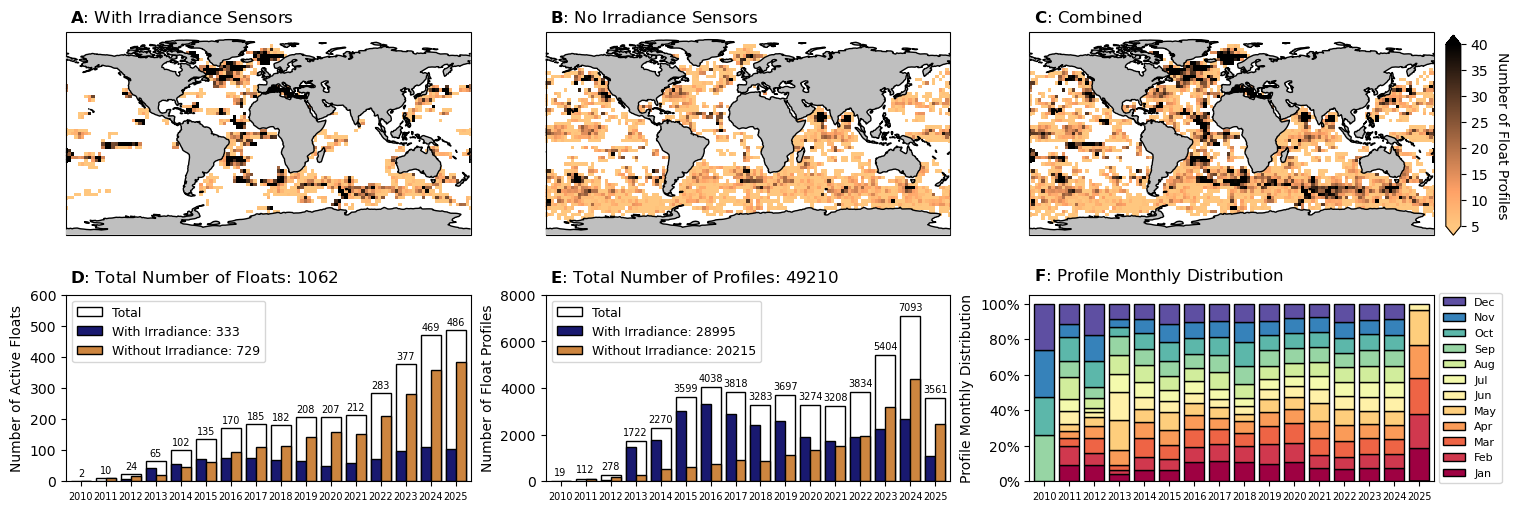

In [5]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_GLOBCOLOUR_ROESLER_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_GLOBCOLOUR_ROESLER_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])

df1a = ds1a[['EPPLEY_VGPM', 'BEHRENFELD_VGPM', 'WESTBERRY_CBPM', 'LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().reset_index().dropna()
df1b = ds1b[['EPPLEY_VGPM', 'BEHRENFELD_VGPM', 'WESTBERRY_CBPM', 'LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().reset_index().dropna()
df1 = ds1[['EPPLEY_VGPM', 'BEHRENFELD_VGPM', 'WESTBERRY_CBPM', 'LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().reset_index().dropna()

fig = plt.figure(figsize=[15, 5], constrained_layout=True)
gs = plt.GridSpec(2, 3, figure=fig, height_ratios=[1, 0.75])

ax0 = fig.add_subplot(gs[:1, :1], projection=ccrs.PlateCarree())
ax0.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax0.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax0.set_global()

ax1 = fig.add_subplot(gs[:1, 1:2], projection=ccrs.PlateCarree())
ax1.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax1.set_global()

ax2 = fig.add_subplot(gs[:1, 2:], projection=ccrs.PlateCarree())
ax2.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax2.set_global()

# Define latitude and longitude bins
lat_bins = np.arange(-90, 93, 3)
lon_bins = np.arange(-180, 183, 3)

# Create a 2D histogram of latitude and longitude
hist, lon_edges, lat_edges = np.histogram2d(df1a.LONGITUDE.values, 
                                            df1a.LATITUDE.values, 
                                            bins=[lon_bins, lat_bins])

# Convert the histogram to a DataArray
heatmap1 = xr.DataArray(hist, coords=[('longitude_bin', lon_bins[:-1]), ('latitude_bin', lat_bins[:-1])])
heatmap1 = heatmap1.where(heatmap1 != 0, np.nan)

# Create a 2D histogram of latitude and longitude
hist, lon_edges, lat_edges = np.histogram2d(df1b.LONGITUDE.values, 
                                            df1b.LATITUDE.values, 
                                            bins=[lon_bins, lat_bins])

# Convert the histogram to a DataArray
heatmap2 = xr.DataArray(hist, coords=[('longitude_bin', lon_bins[:-1]), ('latitude_bin', lat_bins[:-1])])
heatmap2 = heatmap2.where(heatmap2 != 0, np.nan)

# Create a 2D histogram of latitude and longitude
hist, lon_edges, lat_edges = np.histogram2d(df1.LONGITUDE.values, 
                                            df1.LATITUDE.values, 
                                            bins=[lon_bins, lat_bins])

# Convert the histogram to a DataArray
heatmap3 = xr.DataArray(hist, coords=[('longitude_bin', lon_bins[:-1]), ('latitude_bin', lat_bins[:-1])])
heatmap3 = heatmap3.where(heatmap3 != 0, np.nan)

im = heatmap1.T.plot(ax=ax0, vmin=5, vmax=40, cmap='copper_r', add_colorbar=False, transform=ccrs.PlateCarree())
im = heatmap2.T.plot(ax=ax1, vmin=5, vmax=40, cmap='copper_r', add_colorbar=False, transform=ccrs.PlateCarree())
im = heatmap3.T.plot(ax=ax2, vmin=5, vmax=40, cmap='copper_r', add_colorbar=False, transform=ccrs.PlateCarree())

cbar_ax = fig.add_axes([0.96, 0.54, 0.01, 0.4])
cbar = fig.colorbar(im, cax=cbar_ax, extend='both', ticks=np.arange(5, 50, 5))
cbar.set_label('Number of Float Profiles', rotation=270, labelpad=15)
#cbar.ax.yaxis.set_ticks_position('left')
#cbar.ax.yaxis.set_label_position('left')

ax0.text(0.01, 1.05, r'$\bf{A}$: With Irradiance Sensors', transform=ax0.transAxes, fontsize=12)
ax1.text(0.01, 1.05, r'$\bf{B}$: No Irradiance Sensors', transform=ax1.transAxes, fontsize=12)
ax2.text(0.01, 1.05, r'$\bf{C}$: Combined', transform=ax2.transAxes, fontsize=12)

ax3 = fig.add_subplot(gs[1:, :1])
ax4 = fig.add_subplot(gs[1:, 1:2])
ax5 = fig.add_subplot(gs[1:, 2:])

index = np.arange(2010, 2026, 1)

y1 = np.squeeze(df1a.groupby(df1a.DATETIME.dt.year)[['FLOAT']].nunique().reindex(index).values)
y2 = np.squeeze(df1b.groupby(df1b.DATETIME.dt.year)[['FLOAT']].nunique().reindex(index).values)
y3 = np.squeeze(df1.groupby(df1.DATETIME.dt.year)[['FLOAT']].nunique().reindex(index).values)

y4 = np.squeeze(df1a.groupby(df1a.DATETIME.dt.year).count()[['N_PROF']].reindex(index).values)
y5 = np.squeeze(df1b.groupby(df1b.DATETIME.dt.year).count()[['N_PROF']].reindex(index).values)
y6 = np.squeeze(df1.groupby(df1.DATETIME.dt.year).count()[['N_PROF']].reindex(index).values)

y = np.squeeze(df1.groupby([df1.DATETIME.dt.year, df1.DATETIME.dt.month]).count()[['N_PROF']])
y = y.unstack()
normalized_y = y.div(y.sum(axis=1), axis=0) #* 100

x = np.arange(len(y1))  # the label locations
width = 0.4  # the width of the bars

bars3 = ax3.bar(x, y3, width*2, color='w', edgecolor='k', label='Total')
bars1 = ax3.bar(x - width/2, y1, width, label=f'With Irradiance: {len(np.unique(df1a.FLOAT))}', color=colors[0], edgecolor='k')
bars2 = ax3.bar(x + width/2, y2, width, label=f'Without Irradiance: {len(np.unique(df1b.FLOAT))}', color=colors[1], edgecolor='k')

bars3 = ax4.bar(x, y6, width*2, color='w', edgecolor='k', label='Total')
bars1 = ax4.bar(x - width/2, y4, width, label=f'With Irradiance: {df1a.shape[0]}', color=colors[0], edgecolor='k')
bars2 = ax4.bar(x + width/2, y5, width, label=f'Without Irradiance: {df1b.shape[0]}', color=colors[1], edgecolor='k')

cmap = plt.colormaps.get_cmap('Spectral')(np.linspace(0, 1, 12))

normalized_y.plot.bar(ax=ax5, width=width*2, color=cmap, edgecolor='k', stacked=True, legend=False)

ax3.legend(loc=2, fontsize=9)
ax4.legend(loc=2, fontsize=9)

ax3.set_ylabel('Number of Active Floats')
ax4.set_ylabel('Number of Float Profiles')
ax5.set_ylabel('Profile Monthly Distribution')
ax5.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax5.set_xlabel('')

ax3.set_xticks(x)
ax4.set_xticks(x)
ax5.set_xticks(x)

ax3.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', 
                     '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'], fontsize=7, rotation=0)
ax4.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', 
                     '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'], fontsize=7, rotation=0)
ax5.set_xticklabels(['2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', 
                     '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025'], fontsize=7, rotation=0)

ax3.set_ylim(0, 600)
ax4.set_ylim(0, 8000)

ax3.set_xlim(-0.6, 15.6)
ax4.set_xlim(-0.6, 15.6)
ax5.set_xlim(-0.6, 15.6)

ax3.text(0.01, 1.05, r'$\bf{{D}}$:'+f' Total Number of Floats: {len(np.unique(df1.FLOAT))}', va='bottom', transform=ax3.transAxes, fontsize=12)
ax4.text(0.01, 1.05, r'$\bf{{E}}$:'+f' Total Number of Profiles: {np.nansum(y6):.0f}', va='bottom', transform=ax4.transAxes, fontsize=12)
ax5.text(0.01, 1.05, r'$\bf{F}$: Profile Monthly Distribution', va='bottom', transform=ax5.transAxes, fontsize=12)

months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
legend_patches = [patches.Patch(facecolor=color, edgecolor='k', label=label) for label, color in zip(months, cmap)]
legend_patches = legend_patches[::-1]
months = months[::-1]
ax5.legend(handles=legend_patches, labels=months, loc='upper right', bbox_to_anchor=(1.18, 1.04), fontsize=8)

for i in range(len(y3)):
    ax3.text(x[i], y3[i]+15, f'{y3[i]:.0f}', fontsize=7, ha='center')

for i in range(len(y6)):
    ax4.text(x[i], y6[i]+250, f'{y6[i]:.0f}', fontsize=7, ha='center')

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_01.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_01.eps", bbox_inches='tight', dpi=300)

### Figure 2

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


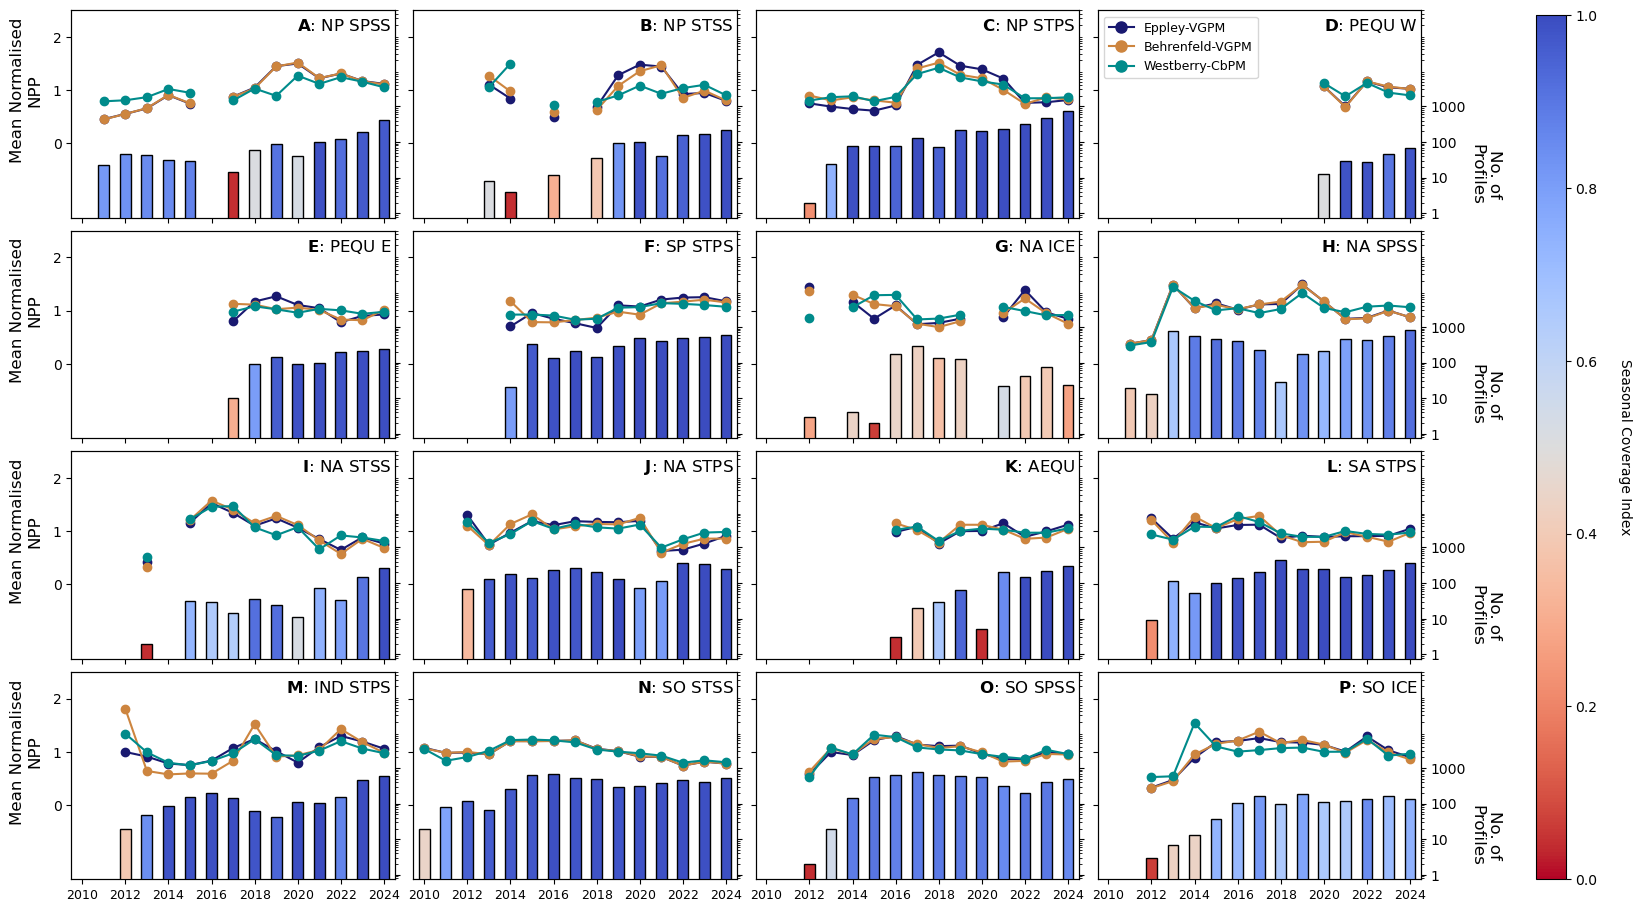

In [6]:
#Define biome names
bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS',
         'NA ICE', 'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

ds1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM', 'BEHRENFELD_VGPM', 'WESTBERRY_CBPM']]

names = [bname[1:]]
biomes = np.arange(2, 18, 1)
letters = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O','P']

# Create figure and GridSpec
fig = plt.figure(figsize=[15, 9], constrained_layout=True)
gs = plt.GridSpec(4, 4, figure=fig)

# Define the axes in a 4x4 grid
axes = [fig.add_subplot(gs[i, j]) for i in range(4) for j in range(4)]
twin_axes = [ax.twinx() for ax in axes]
#sci_data = []

for idx, (b, ax, twin_ax) in enumerate(zip(biomes, axes, twin_axes)):

    df1 = ds1.where(ds1.BIOME == b, drop=True).to_dataframe().reset_index(drop=True).dropna()
    df1 = df1.set_index(pd.DatetimeIndex(df1.DATETIME)).drop(columns=['BIOME', 'DATETIME'])
    filtered_df = df1.copy()
    for col in df1.columns:
        lower = df1[col].quantile(0.025)
        upper = df1[col].quantile(0.975)
        filtered_df = filtered_df[(filtered_df[col] >= lower) & (filtered_df[col] <= upper)]
    df1m = filtered_df.groupby(filtered_df.index.year).mean().reindex(np.arange(2010, 2025, 1))
    df1m = df1m / df1m.mean()
    df1c = filtered_df.groupby(filtered_df.index.year).count().reindex(np.arange(2010, 2025, 1))
    monthly_counts = (filtered_df.groupby([filtered_df.index.year, filtered_df.index.month]).size().unstack(fill_value=0))
    monthly_counts = monthly_counts.reindex(columns=np.arange(1, 13), fill_value=0)

    results = monthly_counts.apply(lambda row: final_sci(row, biome_number=b), axis=1)

    results_df = pd.DataFrame(results.tolist(), index=monthly_counts.index, columns=['SCI', 'Coverage', 'Entropy'])
    sci_per_year = results_df['SCI']
    cov = results_df['Coverage']
    ent = results_df['Entropy']

    df1m.reset_index(drop=True).plot(ax=ax, marker='o', color=colors, legend=False)
    sci_aligned = sci_per_year.reindex(df1c.index, fill_value=0)  # or fill_value=np.nan
    sci_vals = sci_aligned.reset_index(drop=True).values
    nor = mpl.colors.Normalize(vmin=0, vmax=1, clip=True)

    cmap = mpl.cm.coolwarm_r  # or any other matplotlib colormap

    bar_colors = cmap(nor(sci_vals))
    df1c.reset_index(drop=True).EPPLEY_VGPM.plot.bar(
    ax=twin_ax, 
    color=bar_colors, 
    edgecolor='k', 
    width=0.5)

    ax.set_ylim(-1.4, 2.5)
    ax.set_xlabel('')
    ax.set_xticks(np.arange(0, 16, 2))
    ax.set_xticklabels(np.arange(2010, 2026, 2), fontsize=9)
    t = f'$\\mathbf{{{letters[b-2]}}}$'
    t2 = f'{names[0][b-2]}'#\nSCI = {sci_per_year.mean():.2f}±{sci_per_year.std():.2f}'
    #ax.set_title(t + ': ' + t2, fontsize=12)
    ax.text(0.99, 0.90, t + ': ' + t2, transform=ax.transAxes, fontsize=12, ha='right')
    twin_ax.set_yscale('log')
    twin_ax.set_ylim(0.75, 500000)
    ax.set_yticks(np.arange(0, 3, 1))
    twin_ax.set_yticks([1, 10, 100, 1000])
    twin_ax.set_yticklabels(['1', '10', '100', '1000'])

    # Turn off x-ticklabels for all but the bottom row
    if idx < 12:
        ax.set_xticklabels([])

    # Turn off y-ticklabels for all but the first column
    if idx % 4 != 0:
        ax.set_yticklabels([])

    # Turn off twin_ax y-ticklabels for all but the last column
    if (idx + 1) % 4 != 0:
        twin_ax.set_yticklabels([])
        
axes[0].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[0].transAxes, rotation=90, ha='center')
axes[4].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[4].transAxes, rotation=90, ha='center')
axes[8].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[8].transAxes, rotation=90, ha='center')
axes[12].text(-0.14, 0.28, 'Mean Normalised\nNPP', fontsize=12, transform=axes[12].transAxes, rotation=90, ha='center')

twin_axes[3].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[3].transAxes, rotation=270, ha='center')
twin_axes[7].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[7].transAxes, rotation=270, ha='center')
twin_axes[11].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[11].transAxes, rotation=270, ha='center')
twin_axes[15].text(1.2, 0.08, 'No. of\nProfiles', fontsize=12, transform=twin_axes[15].transAxes, rotation=270, ha='center')

algos = ['Eppley-VGPM', 'Behrenfeld-VGPM', 'Westberry-CbPM']
legend_elements = [plt.Line2D([0], [0], marker='o', color=color, markerfacecolor=color, markersize=8, label=name) 
                   for color, name in zip(colors, algos)]
axes[3].legend(handles=legend_elements, loc=2, fontsize=9)

cbar_ax = fig.add_axes([1.02, 0.03, 0.02, 0.96])  # narrow vertical bar on right

# Create the colorbar in that axis
sma = plt.cm.ScalarMappable(cmap=cmap, norm=nor)
sma.set_array([])  # needed for colorbar to work
cbar = fig.colorbar(sma, cax=cbar_ax)
cbar.set_label('Seasonal Coverage Index', rotation=270, labelpad=25)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_02.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_02.eps", bbox_inches='tight', dpi=300)

### Figure 3

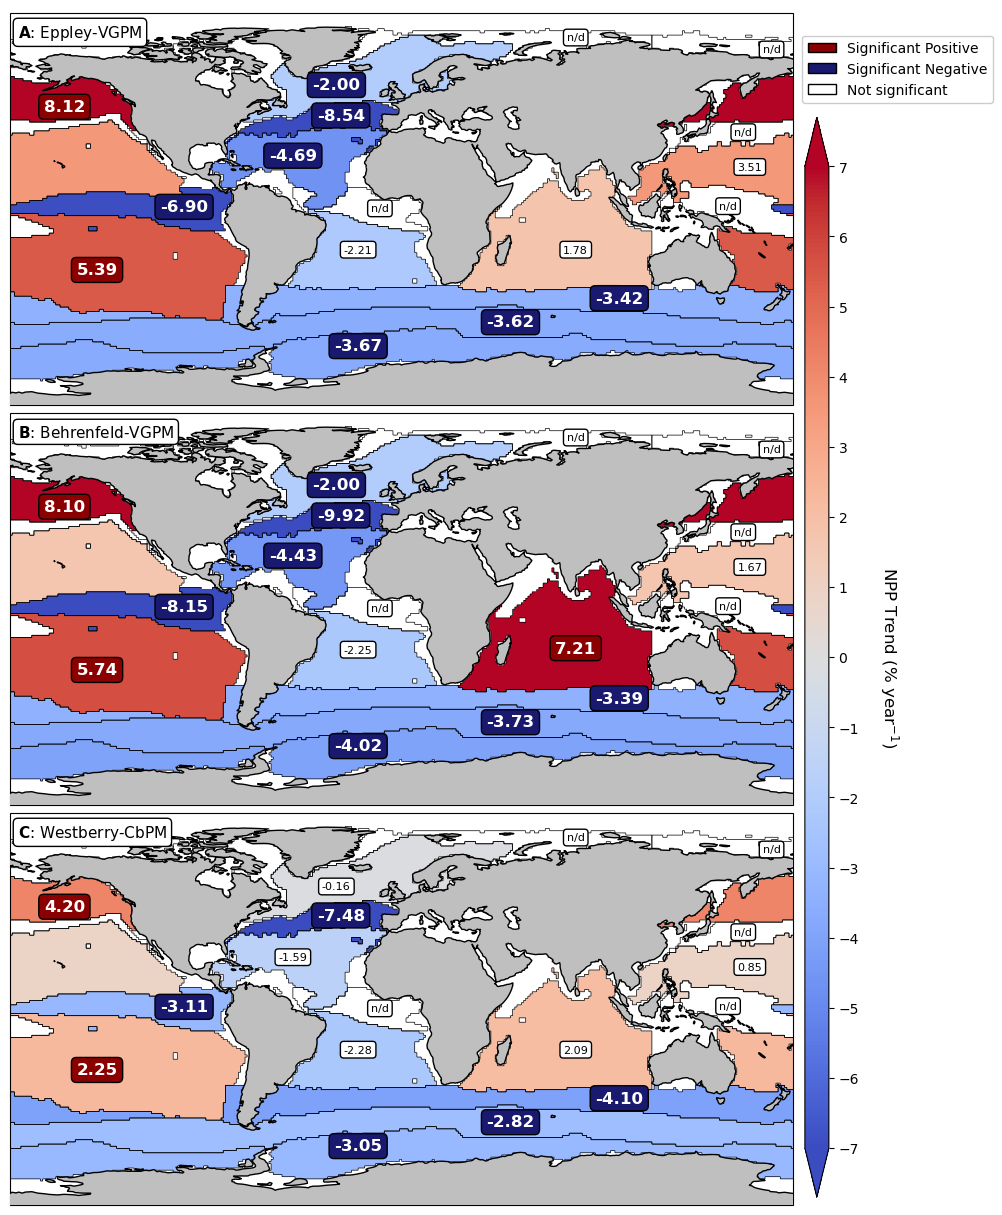

In [7]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

model = 'Huber-Loss'

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm1_biomes = calculate_trends_biomes(ds_vgpm1, 'EPPLEY_VGPM', quality_control=False, normalise=True, model=model, sci_criteria=0.7)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm2_biomes = calculate_trends_biomes(ds_vgpm2, 'BEHRENFELD_VGPM', quality_control=False, normalise=True, model=model, sci_criteria=0.7)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
cbpm2_biomes = calculate_trends_biomes(ds_cbpm2, 'WESTBERRY_CBPM', quality_control=False, normalise=True, model=model, sci_criteria=0.7)

biomes = xr.open_dataset(f'{resdir}/Time_Varying_Biomes_25KM.nc')
biomes_array = biomes['MeanBiomes'].values
unique_values = np.unique(biomes_array)
unique_values = unique_values[:-1]
lats = biomes['lat'].values
lons = biomes['lon'].values
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

vgpm1_dict = dict(zip(np.arange(1, 18), vgpm1_biomes.iloc[:, 0].values))
vgpm2_dict = dict(zip(np.arange(1, 18), vgpm2_biomes.iloc[:, 0].values))
cbpm2_dict = dict(zip(np.arange(1, 18), cbpm2_biomes.iloc[:, 0].values))

max_biome = int(max(vgpm1_dict)) + 1
lookup_array = np.full(max_biome, np.nan)
for biome, slope in vgpm1_dict.items():
    lookup_array[int(biome)] = slope

vgpm1_slopes = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

max_biome = int(max(vgpm2_dict)) + 1
lookup_array = np.full(max_biome, np.nan)
for biome, slope in vgpm2_dict.items():
    lookup_array[int(biome)] = slope
    
vgpm2_slopes = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

max_biome = int(max(cbpm2_dict)) + 1
lookup_array = np.full(max_biome, np.nan)
for biome, slope in cbpm2_dict.items():
    lookup_array[int(biome)] = slope
    
cbpm2_slopes = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

pos_x = [170, -155, 157, 160, 150, -100, -140, 80, -30, -28, -50, -10, -20, 80, 100, 50, -20]
pos_y = [72, 45, 34, 18, 0, -1, -30, 77.5, 55, 41, 22.5, -1, -20, -20, -43, -54, -65]
vmin = -7
vmax = 7

fig = plt.figure(figsize=[8, 12], constrained_layout=True)
gs = plt.GridSpec(3, 1, figure=fig)

ax0 = fig.add_subplot(gs[:1, :], projection=ccrs.PlateCarree())
ax0.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax0.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax0.set_global()

vgpm1_slopes.plot(ax=ax0, vmin=vmin, vmax=vmax, cmap='coolwarm', add_colorbar=False)
for value in unique_values:
    mask = biomes_array == value
    ax0.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

for i in range(17):
    if np.isnan(vgpm1_biomes['p_value'][i]):
        ax0.text(pos_x[i], pos_y[i], 'n/d', transform=ccrs.PlateCarree(),
                 fontsize=8,  ha='center', zorder=6, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'))
    else:
        if (vgpm1_biomes['p_value'][i] > 0.05):
            fontweight='normal'
            fontsize=8
            boxcolor='w'
            fontcolor='k'
        else:
            fontweight='bold'
            fontsize=12
            fontcolor='w'
            if (vgpm1_biomes['slope'][i] > 0):
                boxcolor='darkred'
            else: 
                boxcolor='midnightblue'

        ax0.text(pos_x[i], pos_y[i], f'{vgpm1_biomes['slope'][i]:.2f}', transform=ccrs.PlateCarree(),
                 fontsize=fontsize, fontweight=fontweight, color=fontcolor,  ha='center', zorder=6, 
                 bbox=dict(facecolor=boxcolor, edgecolor='k', boxstyle='round'))

ax1 = fig.add_subplot(gs[1:2, :], projection=ccrs.PlateCarree())
ax1.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax1.set_global()

vgpm2_slopes.plot(ax=ax1, vmin=vmin, vmax=vmax, cmap='coolwarm', add_colorbar=False)
for value in unique_values:
    mask = biomes_array == value
    ax1.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

for i in range(17):
    if np.isnan(vgpm2_biomes['p_value'][i]):
        ax1.text(pos_x[i], pos_y[i], 'n/d', transform=ccrs.PlateCarree(),
                 fontsize=8,  ha='center', zorder=6, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'))
    else:
        if (vgpm2_biomes['p_value'][i] > 0.05):
            fontweight='normal'
            fontsize=8
            boxcolor='w'
            fontcolor='k'
        else:
            fontweight='bold'
            fontsize=12
            fontcolor='w'
            if (vgpm2_biomes['slope'][i] > 0):
                boxcolor='darkred'
            else: 
                boxcolor='midnightblue'

        ax1.text(pos_x[i], pos_y[i], f'{vgpm2_biomes['slope'][i]:.2f}', transform=ccrs.PlateCarree(),
                 fontsize=fontsize, fontweight=fontweight, color=fontcolor,  ha='center', zorder=6, 
                 bbox=dict(facecolor=boxcolor, edgecolor='k', boxstyle='round'))

ax2 = fig.add_subplot(gs[2:, :], projection=ccrs.PlateCarree())
ax2.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax2.set_global()

im = cbpm2_slopes.plot(ax=ax2, vmin=vmin, vmax=vmax, cmap='coolwarm', add_colorbar=False)
for value in unique_values:
    mask = biomes_array == value
    ax2.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

for i in range(17):
    if np.isnan(cbpm2_biomes['p_value'][i]):
        ax2.text(pos_x[i], pos_y[i], 'n/d', transform=ccrs.PlateCarree(),
                 fontsize=8,  ha='center', zorder=6, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'))
    else:
        if (cbpm2_biomes['p_value'][i] > 0.05):
            fontweight='normal'
            fontsize=8
            boxcolor='w'
            fontcolor='k'
        else:
            fontweight='bold'
            fontsize=12
            fontcolor='w'
            if (cbpm2_biomes['slope'][i] > 0):
                boxcolor='darkred'
            else: 
                boxcolor='midnightblue'

        ax2.text(pos_x[i], pos_y[i], f'{cbpm2_biomes['slope'][i]:.2f}', transform=ccrs.PlateCarree(),
                 fontsize=fontsize, fontweight=fontweight, color=fontcolor,  ha='center', zorder=6, 
                 bbox=dict(facecolor=boxcolor, edgecolor='k', boxstyle='round'))

legend_axes = fig.add_axes([1.02, 0.90, 0.2, 0.1])

legend_elements = [patches.Patch(facecolor='darkred', edgecolor='k', label='Significant Positive'),
                   patches.Patch(facecolor='midnightblue', edgecolor='k', label='Significant Negative'), 
                   patches.Patch(facecolor='w', edgecolor='k', label='Not significant')]

legend = legend_axes.legend(handles=legend_elements, loc='center', fontsize=10)
legend_axes.axis('off')
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(1)

cbar_ax = fig.add_axes([1.004, 0.01, 0.03, 0.9])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.arange(vmin, vmax+1, 1), extend='both')
#cbar.set_label('NPP Trend (mg C m$^{-2}$ d$^{-1}$ year$^{-1}$)', labelpad=30, rotation=270, fontsize=12)
cbar.set_label('NPP Trend (% year$^{-1}$)', labelpad=30, rotation=270, fontsize=12)

ax0.text(0.01, 0.94, r'$\bf{{A}}$: Eppley-VGPM', transform=ax0.transAxes, fontsize=11, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'), zorder=6)
ax1.text(0.01, 0.94, r'$\bf{{B}}$: Behrenfeld-VGPM', transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'), zorder=6)
ax2.text(0.01, 0.94, r'$\bf{{C}}$: Westberry-CbPM', transform=ax2.transAxes, fontsize=11, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'), zorder=6)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_03.png", bbox_inches='tight', dpi=300)
#fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_03.eps", bbox_inches='tight', dpi=300)

### Figure 4

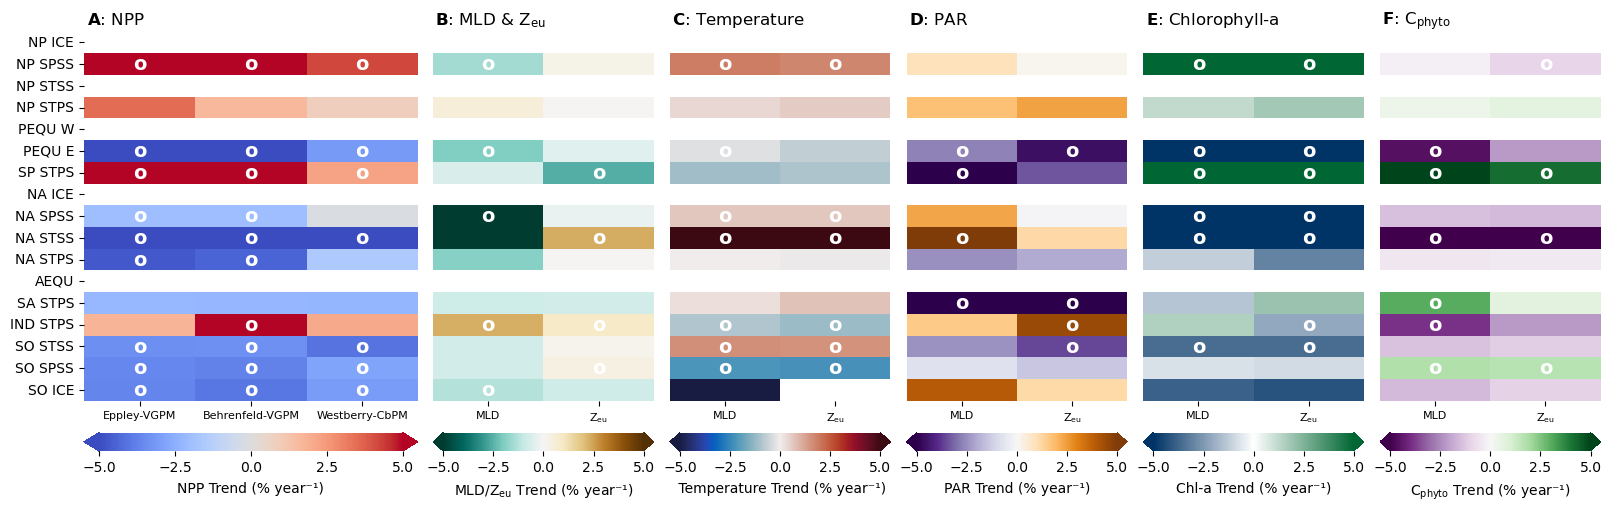

In [8]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm1_biomes = calculate_trends_biomes(ds_vgpm1, 'EPPLEY_VGPM', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm2_biomes = calculate_trends_biomes(ds_vgpm2, 'BEHRENFELD_VGPM', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
cbpm2_biomes = calculate_trends_biomes(ds_cbpm2, 'WESTBERRY_CBPM', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_mld = ds1[['DATETIME', 'BIOME', 'MLD']].to_dataframe().dropna().reset_index(drop=True)
mld_biomes = calculate_trends_biomes(ds_mld, 'MLD', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_zeu = ds1[['DATETIME', 'BIOME', 'ZEU']].to_dataframe().dropna().reset_index(drop=True)
zeu_biomes = calculate_trends_biomes(ds_zeu, 'ZEU', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_chla = ds1[['DATETIME', 'BIOME', 'MLD_CHLA']].to_dataframe().dropna().reset_index(drop=True)
chla_biomes = calculate_trends_biomes(ds_chla, 'MLD_CHLA', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_cphyto = ds1[['DATETIME', 'BIOME', 'MLD_CPHYTO']].to_dataframe().dropna().reset_index(drop=True)
cphyto_biomes = calculate_trends_biomes(ds_cphyto, 'MLD_CPHYTO', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_temp = ds1[['DATETIME', 'BIOME', 'MLD_TEMP']].to_dataframe().dropna().reset_index(drop=True)
temp_biomes = calculate_trends_biomes(ds_temp, 'MLD_TEMP', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_par = ds1[['DATETIME', 'BIOME', 'MLD_DOWNWELLING_PAR']].to_dataframe().dropna().reset_index(drop=True)
par_biomes = calculate_trends_biomes(ds_par, 'MLD_DOWNWELLING_PAR', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_chla = ds1[['DATETIME', 'BIOME', 'ZEU_CHLA']].to_dataframe().dropna().reset_index(drop=True)
chla_biomes2 = calculate_trends_biomes(ds_chla, 'ZEU_CHLA', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_cphyto = ds1[['DATETIME', 'BIOME', 'ZEU_CPHYTO']].to_dataframe().dropna().reset_index(drop=True)
cphyto_biomes2 = calculate_trends_biomes(ds_cphyto, 'ZEU_CPHYTO', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_temp = ds1[['DATETIME', 'BIOME', 'ZEU_TEMP']].to_dataframe().dropna().reset_index(drop=True)
temp_biomes2 = calculate_trends_biomes(ds_temp, 'ZEU_TEMP', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)

ds_par = ds1[['DATETIME', 'BIOME', 'ZEU_DOWNWELLING_PAR']].to_dataframe().dropna().reset_index(drop=True)
par_biomes2 = calculate_trends_biomes(ds_par, 'ZEU_DOWNWELLING_PAR', quality_control=False, normalise=True, model='Huber-Loss', sci_criteria=0.7)


vmin = -5
vmax = 5

bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS', 'NA ICE',
         'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

# Setup figure and grid
fig = plt.figure(figsize=[16, 5], constrained_layout=True)
gs = plt.GridSpec(2, 6, figure=fig, width_ratios=[1, 0.66, 0.66, 0.66, 0.66, 0.66], height_ratios=[1, 0.05])

# Axes in top row (row 0), columns 0 to 5
axes = [fig.add_subplot(gs[0, i]) for i in range(6)]

# Colorbar axes in bottom row (row 1), same columns
caxes = [fig.add_subplot(gs[1, i]) for i in range(6)]

# Data for first heatmap (3 cols)
data1 = pd.DataFrame({
    'Eppley-VGPM': vgpm1_biomes.slope.values,
    'Behrenfeld-VGPM': vgpm2_biomes.slope.values,
    'Westberry-CbPM': cbpm2_biomes.slope.values
}, index=bname)

pvals_stack = np.vstack([
    vgpm1_biomes.p_value.values,
    vgpm2_biomes.p_value.values,
    cbpm2_biomes.p_value.values
]).T

annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)

sns.heatmap(
    data1,
    cmap='coolwarm',
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[0],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[0],
    yticklabels=bname,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': mld_biomes.slope.values,
    'Z$_{eu}$': zeu_biomes.slope.values
}, index=bname)

pvals_stack = np.vstack([
    mld_biomes.p_value.values,
    zeu_biomes.p_value.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1,
    cmap=plt.cm.BrBG_r,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[1],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[1],
    yticklabels=False,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': temp_biomes.slope.values,
    'Z$_{eu}$': temp_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    temp_biomes.p_value.values,
    temp_biomes2.p_value.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1,
    cmap=cmo.cm.balance,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[2],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[2],
    yticklabels=False,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': par_biomes.slope.values,
    'Z$_{eu}$': par_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    par_biomes.p_value.values,
    par_biomes2.p_value.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1,
    cmap=plt.cm.PuOr_r,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[3],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[3],
    yticklabels=False,
    xticklabels=True)

colors = ["#003366", "#FFFFFF", "#006633"]  # dark blue, white, dark green (lighter than black)
chla_cmap = mpl.colors.LinearSegmentedColormap.from_list("BlueWhiteGreenLight", colors)

data1 = pd.DataFrame({
    'MLD': chla_biomes.slope.values,
    'Z$_{eu}$': chla_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    chla_biomes.p_value.values,
    chla_biomes2.p_value.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1,
    cmap=chla_cmap,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[4],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[4],
    yticklabels=False,
    xticklabels=True)

data1 = pd.DataFrame({
    'MLD': cphyto_biomes.slope.values,
    'Z$_{eu}$': cphyto_biomes2.slope.values
}, index=bname)

pvals_stack = np.vstack([
    cphyto_biomes.p_value.values,
    cphyto_biomes2.p_value.values
]).T
annot_df = pd.DataFrame(np.where(pvals_stack < 0.05, 'o', ''), index=bname, columns=data1.columns)
sns.heatmap(
    data1,
    cmap=plt.cm.PRGn,
    vmin=vmin,
    vmax=vmax,
    annot=annot_df,
    fmt='',
    annot_kws={'color': 'w', 'fontsize': 14, 'fontweight': 'bold'},
    cbar_ax=caxes[5],
    cbar_kws={'extend': 'both', 'orientation': 'horizontal'},
    ax=axes[5],
    yticklabels=False,
    xticklabels=True)

# Add colorbar labels rotated 270 degrees
cbar_labels = [
    "NPP Trend (% year⁻¹)", "MLD/Z$_{eu}$ Trend (% year⁻¹)", " Temperature Trend (% year⁻¹)",
    "PAR Trend (% year⁻¹)", "Chl-a Trend (% year⁻¹)", "C$_{phyto}$ Trend (% year⁻¹)"]

for cax, label in zip(caxes, cbar_labels):
    cax.set_xlabel(label, fontsize=10, labelpad=5, ha='center')
    cax.set_xticks(np.arange(-5, 7.5, 2.5))

for ax in axes:
    plt.setp(ax.get_xticklabels(), fontsize=8, rotation=0)

axes[0].text(0.01, 1.02, r'$\bf{{A}}$: NPP', transform=axes[0].transAxes, fontsize=12)
axes[1].text(0.01, 1.02, r'$\bf{{B}}$: MLD & Z$_{eu}$', transform=axes[1].transAxes, fontsize=12)
axes[2].text(0.01, 1.02, r'$\bf{{C}}$: Temperature', transform=axes[2].transAxes, fontsize=12) 
axes[3].text(0.01, 1.02, r'$\bf{{D}}$: PAR', transform=axes[3].transAxes, fontsize=12) 
axes[4].text(0.01, 1.02, r'$\bf{{E}}$: Chlorophyll-a', transform=axes[4].transAxes, fontsize=12) 
axes[5].text(0.01, 1.02, r'$\bf{{F}}$: C$_{phyto}$', transform=axes[5].transAxes, fontsize=12) 

plt.show()

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_04.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_04.eps", bbox_inches='tight', dpi=300)

### Figure 5

In [23]:
biomes = xr.open_dataset(f'{resdir}/Time_Varying_Biomes_25KM.nc').MeanBiomes

fname = '/Volumes/Tommy/NPP/OUTPUTS/1998_2024_NPP_EPPLEY_VGPM_25KM_8D.nc'
sat_vgpm1 = xr.open_dataset(fname).sel(time=slice('2010-01-01', '2024-12-31'))
sat_vgpm1['biomes'] = biomes

fname = '/Volumes/Tommy/NPP/OUTPUTS/1998_2024_NPP_BEHRENFELD_VGPM_25KM_8D.nc'
sat_vgpm2 = xr.open_dataset(fname).sel(time=slice('2010-01-01', '2024-12-31'))
sat_vgpm2['biomes'] = biomes

fname = '/Volumes/Tommy/NPP/OUTPUTS/1998_2024_NPP_WESTBERRY_CBPM_25KM_8D.nc'
sat_cbpm2 = xr.open_dataset(fname).sel(time=slice('2010-01-01', '2024-12-31'))
sat_cbpm2['biomes'] = biomes

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm1_biomes = calculate_trends_biomes(ds_vgpm1, 'EPPLEY_VGPM', quality_control=False, normalise=False, model='Huber-Loss', sci_criteria=0.7)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm2_biomes = calculate_trends_biomes(ds_vgpm2, 'BEHRENFELD_VGPM', quality_control=False, normalise=False, model='Huber-Loss', sci_criteria=0.7)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
cbpm2_biomes = calculate_trends_biomes(ds_cbpm2, 'WESTBERRY_CBPM', quality_control=False, normalise=False, model='Huber-Loss', sci_criteria=0.7)

argo_locs = ds1[['LATITUDE', 'LONGITUDE', 'DATETIME']].to_dataframe().dropna()

sat_vgpm1_resampled = []
sat_vgpm2_resampled = []
sat_cbpm2_resampled = []

for i in tqdm(range(argo_locs.shape[0])):

    d = argo_locs.iloc[i]

    sel = sat_vgpm1.sel(
                    lat=d.LATITUDE,
                    lon=d.LONGITUDE,
                    time=d.DATETIME,
                    method='nearest'
                )
    sat_vgpm1_resampled.append(sel['Eppley-VGPM'].values)

    sel = sat_vgpm2.sel(
                    lat=d.LATITUDE,
                    lon=d.LONGITUDE,
                    time=d.DATETIME,
                    method='nearest'
                )
    sat_vgpm2_resampled.append(sel['Behrenfeld-VGPM'].values)

    sel = sat_cbpm2.sel(
                    lat=d.LATITUDE,
                    lon=d.LONGITUDE,
                    time=d.DATETIME,
                    method='nearest'
                )
    sat_cbpm2_resampled.append(sel['Westberry-CbPM'].values)

sat_vgpm1_resampled = pd.Series(sat_vgpm1_resampled)
sat_vgpm2_resampled = pd.Series(sat_vgpm2_resampled)
sat_cbpm2_resampled = pd.Series(sat_cbpm2_resampled)

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
ds_vgpm1['EPPLEY_VGPM'] = sat_vgpm1_resampled.astype(float).values
vgpm1_sat_resampled_biomes = calculate_trends_biomes(ds_vgpm1, 'EPPLEY_VGPM', quality_control=False, normalise=False, 
                                                     model='Huber-Loss', sci_criteria=0.7)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
ds_vgpm2['BEHRENFELD_VGPM'] = sat_vgpm2_resampled.astype(float).values
vgpm2_sat_resampled_biomes = calculate_trends_biomes(ds_vgpm2, 'BEHRENFELD_VGPM', quality_control=False, normalise=False, 
                                                     model='Huber-Loss', sci_criteria=0.7)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
ds_cbpm2['WESTBERRY_CBPM'] = sat_cbpm2_resampled.astype(float).values
cbpm2_sat_resampled_biomes = calculate_trends_biomes(ds_cbpm2, 'WESTBERRY_CBPM', quality_control=False, normalise=False, 
                                                     model='Huber-Loss', sci_criteria=0.7)



100%|██████████| 39696/39696 [08:58<00:00, 73.78it/s] 


AttributeError: 'Normalize' object has no attribute 'cdf'

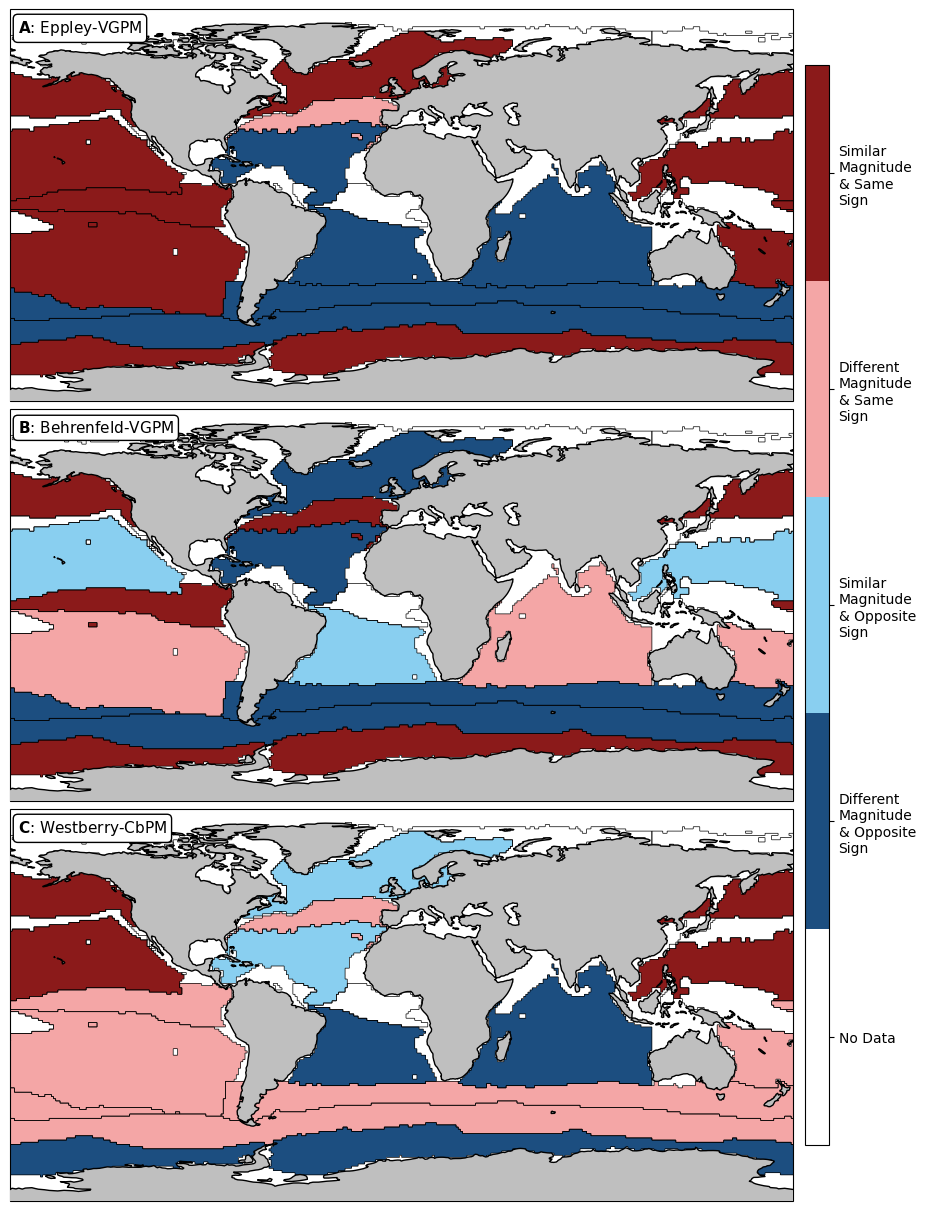

In [25]:
result_vgpm1 = compare_trends(vgpm1_biomes, vgpm1_sat_resampled_biomes)
result_vgpm2 = compare_trends(vgpm2_biomes, vgpm2_sat_resampled_biomes)
result_cbpm2 = compare_trends(cbpm2_biomes, cbpm2_sat_resampled_biomes)

biomes = xr.open_dataset(f'{resdir}/Time_Varying_Biomes_25KM.nc')
biomes_array = biomes['MeanBiomes'].values
unique_values = np.unique(biomes_array)
unique_values = unique_values[:-1]
lats = biomes['lat'].values
lons = biomes['lon'].values
lon_mesh, lat_mesh = np.meshgrid(lons, lats)

def make_biome_to_slope(lookup_array):
    def biome_to_slope(biome):
        if np.isnan(biome):
            return np.nan
        biome_int = int(biome)
        if biome_int < 0 or biome_int >= len(lookup_array):
            return np.nan
        return lookup_array[biome_int]
    return biome_to_slope

biome_class_map = dict(zip(range(1, 18), result_vgpm1.classification_code))

max_biome = int(max(biome_class_map)) + 1
lookup_array = np.full(18, np.nan)
for biome, slope in biome_class_map.items():
    lookup_array[int(biome)] = slope

vgpm1_cats = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

biome_class_map = dict(zip(range(1, 18), result_vgpm2.classification_code))

max_biome = int(max(biome_class_map)) + 1
lookup_array = np.full(18, np.nan)
for biome, slope in biome_class_map.items():
    lookup_array[int(biome)] = slope

vgpm2_cats = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

biome_class_map = dict(zip(range(1, 18), result_cbpm2.classification_code))

max_biome = int(max(biome_class_map)) + 1
lookup_array = np.full(18, np.nan)
for biome, slope in biome_class_map.items():
    lookup_array[int(biome)] = slope

cbpm2_cats = xr.apply_ufunc(
    biome_to_slope,
    biomes['MeanBiomes'],
    vectorize=True,
    dask='parallelized' if biomes['MeanBiomes'].chunks else False,
    output_dtypes=[float],)

colors = [
    '#FFFFFF',  # 0 Unclassified
    '#1C4E80',  # 1 Sig. & Opposite Sign (dark blue)
    '#89CFF0',  # 2 Not Sig. & Opposite Sign (light blue)
    '#F4A6A6',  # 3 Sig. & Same Sign (light red)
    '#8B1A1A'   # 4 Not Sig. & Same Sign (dark red)
]

# Create the colormap
cmap = mpl.colors.ListedColormap(colors)

fig = plt.figure(figsize=[8, 12], constrained_layout=True)
gs = plt.GridSpec(3, 1, figure=fig)

ax0 = fig.add_subplot(gs[0, :], projection=ccrs.PlateCarree())
ax0.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax0.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax0.set_global()

im = vgpm1_cats.plot(ax=ax0, cmap=cmap, add_colorbar=False, vmin=0, vmax=5)
for value in unique_values:
    mask = biomes_array == value
    ax0.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

ax1 = fig.add_subplot(gs[1, :], projection=ccrs.PlateCarree())
ax1.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax1.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax1.set_global()

im = vgpm2_cats.plot(ax=ax1, cmap=cmap, add_colorbar=False, vmin=0, vmax=5)
for value in unique_values:
    mask = biomes_array == value
    ax1.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

ax2 = fig.add_subplot(gs[2, :], projection=ccrs.PlateCarree())
ax2.add_feature(cartopy.feature.LAND, facecolor='0.75', zorder=5)
ax2.add_feature(cartopy.feature.COASTLINE, linewidth=1, zorder=5)
ax2.set_global()

im = cbpm2_cats.plot(ax=ax2, cmap=cmap, add_colorbar=False, vmin=0, vmax=5)
for value in unique_values:
    mask = biomes_array == value
    ax2.contour(lon_mesh, lat_mesh, mask, 
                levels=[0.5], colors='k', 
                linestyles='-', linewidths=0.5, 
                transform=ccrs.PlateCarree())

cbar_ax = fig.add_axes([1.004, 0.05, 0.03, 0.9])
cbar = fig.colorbar(im, cax=cbar_ax, ticks=np.arange(0.5, 5.5, 1))
cbar.set_ticklabels([
    'No Data',
    'Different\nMagnitude\n& Opposite\nSign',
    'Similar\nMagnitude\n& Opposite\nSign',
    'Different\nMagnitude\n& Same\nSign',
    'Similar\nMagnitude\n& Same\nSign'
])

ax0.text(0.01, 0.94, r'$\bf{{A}}$: Eppley-VGPM', transform=ax0.transAxes, fontsize=11, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'), zorder=6)
ax1.text(0.01, 0.94, r'$\bf{{B}}$: Behrenfeld-VGPM', transform=ax1.transAxes, fontsize=11, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'), zorder=6)
ax2.text(0.01, 0.94, r'$\bf{{C}}$: Westberry-CbPM', transform=ax2.transAxes, fontsize=11, bbox=dict(facecolor='w', edgecolor='k', boxstyle='round'), zorder=6)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_05.png", bbox_inches='tight', dpi=300)
#fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_05.eps", bbox_inches='tight', dpi=300)

## Supplementary Figures

### Figure S01

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


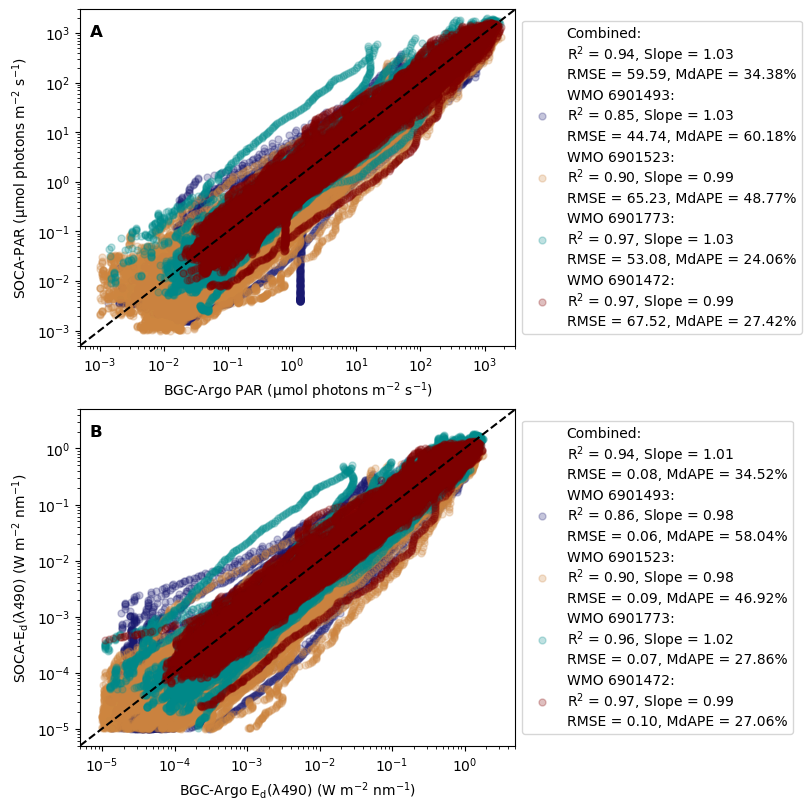

In [17]:
# Prepare data groups
data_groups = [
    {
        "ax": 0,
        "title": r'$\bf{A}$',
        "datasets": [
            ("Combined", soca_globcolour_par_data, 'w'),
            ("WMO 6901493", soca_globcolour_par_data3, colors[0]),
            ("WMO 6901523", soca_globcolour_par_data2, colors[1]),
            ("WMO 6901773", soca_globcolour_par_data4, colors[2]),
            ("WMO 6901472", soca_globcolour_par_data1, colors[3]),
        ],
        "compute_stats": True,
    },
    {
        "ax": 1,
        "title": r'$\bf{B}$',
        "datasets": [
            ("Combined", soca_globcolour_ed490_data, 'w'),
            ("WMO 6901493", soca_globcolour_ed490_data3, colors[0]),
            ("WMO 6901523", soca_globcolour_ed490_data2, colors[1]),
            ("WMO 6901773", soca_globcolour_ed490_data4, colors[2]),
            ("WMO 6901472", soca_globcolour_ed490_data1, colors[3]),
        ],
        "compute_stats": True,
    }
]

fig = plt.figure(figsize=[8, 8], constrained_layout=True)
gs = plt.GridSpec(2, 1, figure=fig)
axes = [fig.add_subplot(gs[i, :]) for i in range(2)]

# Main loop for plotting
for group in data_groups:
    ax = axes[group["ax"]]
    for label, data, color in group["datasets"]:
        x, y = data['measured'], data['modelled']
        if group["compute_stats"]:
            rmse = np.sqrt(mean_squared_error(x, y))
            mape = np.median(np.abs((x - y) / x)) * 100
            r2 = r2_score(np.log10(x), np.log10(y))
            slope, inter = np.polyfit(np.log10(x), np.log10(y), 1)
            label = f'{label}:\nR$^2$ = {r2:.2f}, Slope = {slope:.2f}\nRMSE = {rmse:.2f}, MdAPE = {mape:.2f}%'
        else:
            label = f'{label}'
        ax.plot(x, y, 'o', markersize=5, alpha=0.25, lw=0, c=color, label=label)

    # Reference 1:1 line
    if group["ax"] == 0:
        ax.plot([5e-4, 3000], [5e-4, 3000], c='k', ls='--')
        ax.set_xlim(5e-4, 3000)
        ax.set_ylim(5e-4, 3000)
        ax.set_ylabel("SOCA-PAR (μmol photons m$^{-2}$ s$^{-1}$)")
        ax.set_xlabel("BGC-Argo PAR (μmol photons m$^{-2}$ s$^{-1}$)")
    else:
        ax.plot([5e-6, 5], [5e-6, 5], c='k', ls='--')
        ax.set_xlim(5e-6, 5)
        ax.set_ylim(5e-6, 5)
        ax.set_ylabel("SOCA-E$_d$(λ490) (W m$^{-2}$ nm$^{-1}$)")
        ax.set_xlabel("BGC-Argo E$_d$(λ490) (W m$^{-2}$ nm$^{-1}$)")

    # Axis settings
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)
    ax.text(0.02, 0.92, group["title"], transform=ax.transAxes, fontsize=12)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S01.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S01.eps", bbox_inches='tight', dpi=300)

### Figure S02

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


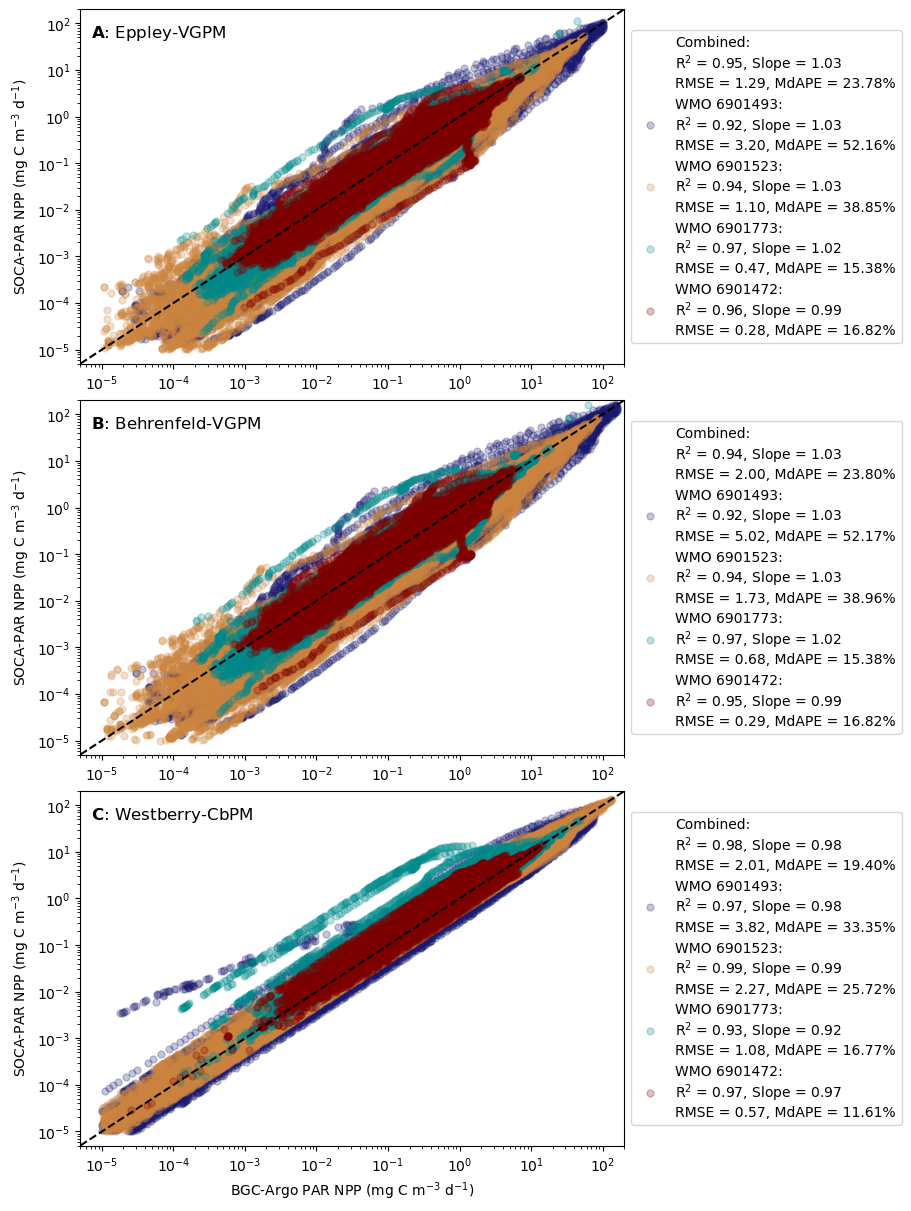

In [18]:
# Prepare data groups
data_groups = [
    {
        "ax": 0,
        "title": r'$\bf{A}$: Eppley-VGPM',
        "datasets": [
            ("Combined", soca_globcolour_eppley_vgpm_data, 'w'),
            ("WMO 6901493", soca_globcolour_eppley_vgpm_data3, colors[0]),
            ("WMO 6901523", soca_globcolour_eppley_vgpm_data2, colors[1]),
            ("WMO 6901773", soca_globcolour_eppley_vgpm_data4, colors[2]),
            ("WMO 6901472", soca_globcolour_eppley_vgpm_data1, colors[3]),
        ],
        "compute_stats": True,
    },
    {
        "ax": 1,
        "title": r'$\bf{B}$: Behrenfeld-VGPM',
        "datasets": [
            ("Combined", soca_globcolour_behrenfeld_vgpm_data, 'w'),
            ("WMO 6901493", soca_globcolour_behrenfeld_vgpm_data3, colors[0]),
            ("WMO 6901523", soca_globcolour_behrenfeld_vgpm_data2, colors[1]),
            ("WMO 6901773", soca_globcolour_behrenfeld_vgpm_data4, colors[2]),
            ("WMO 6901472", soca_globcolour_behrenfeld_vgpm_data1, colors[3]),
        ],
        "compute_stats": True,
    },
    {
        "ax": 2,
        "title": r'$\bf{C}$: Westberry-CbPM',
        "datasets": [
            ("Combined", soca_globcolour_westberry_cbpm_data, 'w'),
            ("WMO 6901493", soca_globcolour_westberry_cbpm_data3, colors[0]),
            ("WMO 6901523", soca_globcolour_westberry_cbpm_data2, colors[1]),
            ("WMO 6901773", soca_globcolour_westberry_cbpm_data4, colors[2]),
            ("WMO 6901472", soca_globcolour_westberry_cbpm_data1, colors[3]),
        ],
        "compute_stats": True,
    },
]

# Plot setup
fig = plt.figure(figsize=[9, 12], constrained_layout=True)
gs = plt.GridSpec(3, 1, figure=fig)
axes = [fig.add_subplot(gs[i, :]) for i in range(3)]

# Main loop for plotting
for group in data_groups:
    ax = axes[group["ax"]]
    for label, data, color in group["datasets"]:
        x, y = data['measured'], data['modelled']
        if group["compute_stats"]:
            rmse = np.sqrt(mean_squared_error(x, y))
            mape = np.median(np.abs((x - y) / x)) * 100
            r2 = r2_score(np.log10(x), np.log10(y))
            slope, inter = np.polyfit(np.log10(x), np.log10(y), 1)
            label = f'{label}:\nR$^2$ = {r2:.2f}, Slope = {slope:.2f}\nRMSE = {rmse:.2f}, MdAPE = {mape:.2f}%'
        else:
            label = f'{label}'
        ax.plot(x, y, 'o', markersize=5, alpha=0.25, lw=0, c=color, label=label)

    # Reference 1:1 line
    ax.plot([5e-6, 200], [5e-6, 200], c='k', ls='--')

    # Axis settings
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlim(5e-6, 200)
    ax.set_ylim(5e-6, 200)
    ax.set_ylabel("SOCA-PAR NPP (mg C m$^{-3}$ d$^{-1}$)")
    if group["ax"] == 2:
        ax.set_xlabel("BGC-Argo PAR NPP (mg C m$^{-3}$ d$^{-1}$)")
    else:
        ax.set_xlabel("")
    
    ax.text(0.02, 0.92, group["title"], transform=ax.transAxes, fontsize=12)
    ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=10)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S02.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S02.eps", bbox_inches='tight', dpi=300)

### Figure S03

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


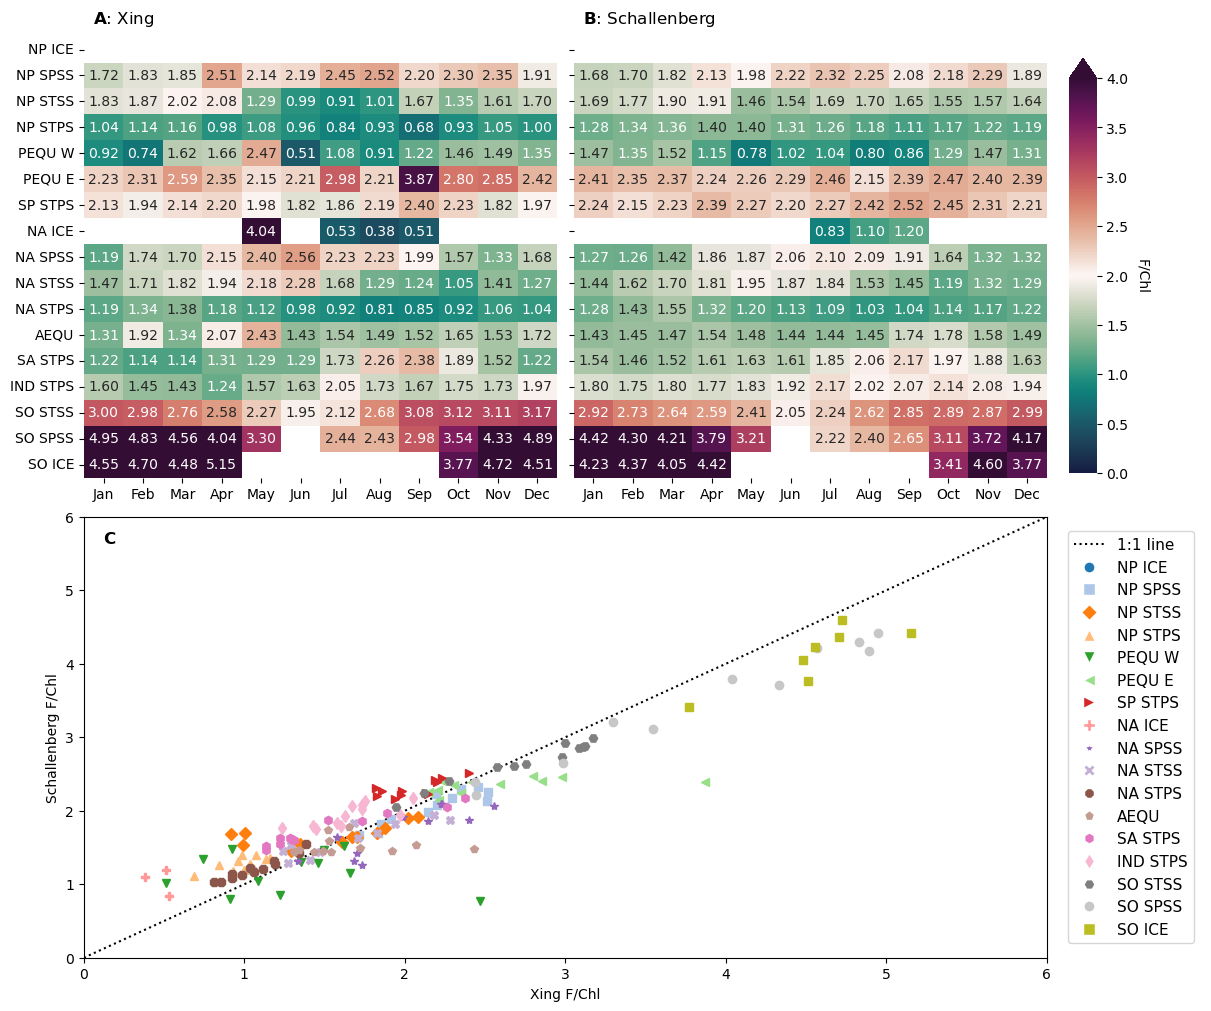

In [19]:
fname = f'{resdir}/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_XING.csv'
xing_fchl = pd.read_csv(fname, index_col='BIOME').reindex(range(1,18))

fname = f'{resdir}/BIOME_MONTHLY_CHLA_CONVERSION_FACTOR_SCHALLENBERG.csv'
schallenberg_fchl = pd.read_csv(fname, index_col='BIOME').reindex(range(1,18))


bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS', 'NA ICE',
         'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']
month = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig = plt.figure(figsize=[12, 10], constrained_layout=True)
gs = plt.GridSpec(2, 3, figure=fig, width_ratios=[1, 1, 0.3])

ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1])
ax_cbar = fig.add_subplot(gs[0, 2]) 

sns.heatmap(
    1/xing_fchl,
    cmap=cmo.cm.curl,
    vmin=0,
    vmax=4,
    center=2,
    annot=True,
    fmt=".2f", 
    cbar=True,
    cbar_ax=ax_cbar,
    cbar_kws={'extend':'max'},
    ax=ax0)

ax0.set_yticklabels(bname, rotation=0)
ax0.set_xticklabels(month, rotation=0)
ax0.set_ylabel('')

ax = sns.heatmap(
    schallenberg_fchl,
    cmap=cmo.cm.curl,
    vmin=0,
    vmax=4,
    center=2,
    annot=True,
    fmt=".2f", 
    cbar=False,
    ax=ax1)

ax1.set_xticklabels(month, rotation=0)
ax1.set_yticklabels('')
ax1.set_ylabel('')

ax_cbar.set_ylabel('F/Chl', rotation=270, labelpad=15)
pos = ax_cbar.get_position()
ax_cbar.set_position([pos.x0+0.03, pos.y0+0.02, pos.width * 0.2, pos.height * 0.9])

# Example markers and colors (expand as needed)
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', '8', 'p', 'h', 'd', 'H', 'o', 's']
marker_colors = plt.cm.tab20.colors  # A colormap with 20 distinct colors
biomes = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS',
         'NA ICE', 'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

ax_legend = fig.add_subplot(gs[1, 2])
ax_legend.axis('off')
# Custom biome marker handles
biome_handles = [
    Line2D([0], [0],
           marker=markers[i % len(markers)],
           color='w',
           markerfacecolor=marker_colors[i % len(marker_colors)],
           markersize=8,
           label=biome)
    for i, biome in enumerate(bname)
]

# Custom line handle for 1:1 line
line_handle = Line2D([0], [0], color='k', linestyle=':', label='1:1 line')

# Combine all handles
legend_handles = [line_handle] + biome_handles

# Custom legend
ax_legend.legend(handles=legend_handles, loc='center', ncol=1, fontsize=11)

ax2 = fig.add_subplot(gs[1, :2])

xmin = 0
xmax = 6
x_vals = np.linspace(xmin, xmax, 100)
y_vals = x_vals
tolerance = 0.10  # 10%

ax2.plot(x_vals, y_vals, ls=':', c='k', label='1:1 line')
ax2.set_ylim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax2.set_xlabel('Xing F/Chl')
ax2.set_ylabel('Schallenberg F/Chl')

biome_idx_map = list(zip(range(1, 18), bname))  # [(2, 'NP SPSS'), ..., (17, 'SO ICE')]


group_schallenberg = schallenberg_fchl.stack()
group_xing = 1/xing_fchl.stack().reindex(group_schallenberg.index)

for i, (idx, biome) in enumerate(biome_idx_map):
    try:
        x = group_xing.xs(idx, level=0)
        y = group_schallenberg.xs(idx, level=0)
    except KeyError:
        continue  # skip missing data

    marker = markers[i % len(markers)]
    color = marker_colors[i % len(marker_colors)]
    ax2.plot(x, y, marker=marker, color=color, lw=0, label=biome)

ax0.text(0.02, 1.03, r'$\bf{A}$: Xing', transform=ax0.transAxes, fontsize=12)
ax1.text(0.02, 1.03, r'$\bf{B}$: Schallenberg', transform=ax1.transAxes, fontsize=12)
ax2.text(0.02, 0.94, r'$\bf{C}$', transform=ax2.transAxes, fontsize=12)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S03.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S03.eps", bbox_inches='tight', dpi=300)

### Figure S04

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


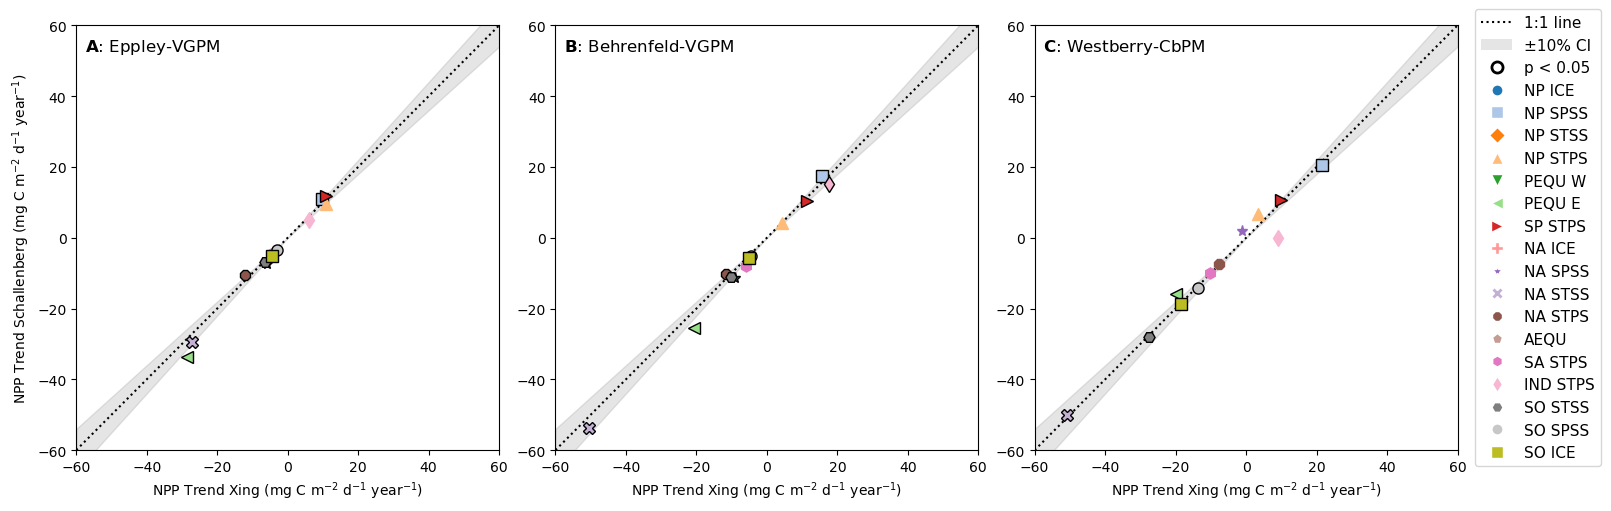

In [20]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

model = 'Huber-Loss'
sci_criteria = 0.7

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm1_xing = calculate_trends_biomes(ds_vgpm1, 'EPPLEY_VGPM', quality_control=False, normalise=False, model=model, sci_criteria=sci_criteria)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm2_xing = calculate_trends_biomes(ds_vgpm2, 'BEHRENFELD_VGPM', quality_control=False, normalise=False, model=model, sci_criteria=sci_criteria)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
cbpm2_xing = calculate_trends_biomes(ds_cbpm2, 'WESTBERRY_CBPM', quality_control=False, normalise=False, model=model, sci_criteria=sci_criteria)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_SCHALLENBERG_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_SCHALLENBERG_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm1_schallenberg = calculate_trends_biomes(ds_vgpm1, 'EPPLEY_VGPM', quality_control=False, normalise=False, model=model, sci_criteria=sci_criteria)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
vgpm2_schallenberg = calculate_trends_biomes(ds_vgpm2, 'BEHRENFELD_VGPM', quality_control=False, normalise=False, model=model, sci_criteria=sci_criteria)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
cbpm2_schallenberg = calculate_trends_biomes(ds_cbpm2, 'WESTBERRY_CBPM', quality_control=False, normalise=False, model=model, sci_criteria=sci_criteria)

# Example markers and colors (expand as needed)
markers = ['o', 's', 'D', '^', 'v', '<', '>', 'P', '*', 'X', '8', 'p', 'h', 'd', 'H', 'o', 's']
marker_colors = plt.cm.tab20.colors  # A colormap with 20 distinct colors
biomes = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS',
         'NA ICE', 'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

fig = plt.figure(figsize=[16, 5], constrained_layout=True)
gs = plt.GridSpec(1, 4, figure=fig, width_ratios=[1,1,1,0.3])
ax_legend = fig.add_subplot(gs[:, 3])
ax_legend.axis('off')
# Custom biome marker handles
biome_handles = [
    Line2D([0], [0],
           marker=markers[i % len(markers)],
           color='w',
           markerfacecolor=marker_colors[i % len(marker_colors)],
           markersize=8,
           label=biome)
    for i, biome in enumerate(biomes)
]

sig_marker = Line2D([0], [0],
                    marker='o',
                    color='w',
                    markerfacecolor='white',
                    markeredgecolor='black',
                    markeredgewidth=2,
                    markersize=8,
                    label='p < 0.05')

# Custom line handle for 1:1 line
line_handle = Line2D([0], [0], color='k', linestyle=':', label='1:1 line')

# Custom patch handle for ±10% CI
fill_handle = Patch(facecolor='gray', alpha=0.2, label='±10% CI')

# Combine all handles
legend_handles = [line_handle, fill_handle] + [sig_marker] + biome_handles

# Custom legend
ax_legend.legend(handles=legend_handles, loc='center', ncol=1, fontsize=11)

ax0 = fig.add_subplot(gs[:, 0])
ax1 = fig.add_subplot(gs[:, 1])
ax2 = fig.add_subplot(gs[:, 2])

xmin = -60
xmax = 60
x_vals = np.linspace(xmin, xmax, 100)
y_vals = x_vals
tolerance = 0.10  # 10%

lower_bound = y_vals * (1 - tolerance)
upper_bound = y_vals * (1 + tolerance)

ax0.plot(x_vals, y_vals, ls=':', c='k', label='1:1 line')
ax0.fill_between(x_vals, lower_bound, upper_bound, color='gray', alpha=0.2, label='±10% CI')
ax0.set_ylim(xmin, xmax)
ax0.set_xlim(xmin, xmax)
ax0.set_xlabel('NPP Trend Xing (mg C m$^{-2}$ d$^{-1}$ year$^{-1}$)')
ax0.set_ylabel('NPP Trend Schallenberg (mg C m$^{-2}$ d$^{-1}$ year$^{-1}$)')

ax1.plot(x_vals, y_vals, ls=':', c='k', label='1:1 line')
ax1.fill_between(x_vals, lower_bound, upper_bound, color='gray', alpha=0.2, label='±10% CI')
ax1.set_ylim(xmin, xmax)
ax1.set_xlim(xmin, xmax)
ax1.set_xlabel('NPP Trend Xing (mg C m$^{-2}$ d$^{-1}$ year$^{-1}$)')

ax2.plot(x_vals, y_vals, ls=':', c='k', label='1:1 line')
ax2.fill_between(x_vals, lower_bound, upper_bound, color='gray', alpha=0.2, label='±10% CI')
ax2.set_ylim(xmin, xmax)
ax2.set_xlim(xmin, xmax)
ax2.set_xlabel('NPP Trend Xing (mg C m$^{-2}$ d$^{-1}$ year$^{-1}$)')

# Loop through each data point
for i, (x, y, z, j) in enumerate(zip(vgpm1_xing.slope, vgpm1_schallenberg.slope, vgpm1_xing.p_value, vgpm1_schallenberg.p_value)):
    marker = markers[i % len(markers)]
    color = marker_colors[i % len(marker_colors)]
    b = biomes[i % len(biomes)]
    label = f'{b}'  # or custom label
    if (z < 0.05) & (j < 0.05):
        mec = 'k'
    else:
        mec = color
    ax0.errorbar(x, y, fmt=marker, ms=8, color=color, markeredgecolor=mec,
                label=label, lw=1, capsize=5)

for i, (x, y, z, j) in enumerate(zip(vgpm2_xing.slope, vgpm2_schallenberg.slope, vgpm2_xing.p_value, vgpm2_schallenberg.p_value)):
    marker = markers[i % len(markers)]
    color = marker_colors[i % len(marker_colors)]
    b = biomes[i % len(biomes)]
    label = f'{b}'  # or custom label
    if (z < 0.05) & (j < 0.05):
        mec = 'k'
    else:
        mec = color
    ax1.errorbar(x, y, fmt=marker, ms=8, color=color, markeredgecolor=mec,
                label=label, lw=1, capsize=5)

for i, (x, y, z, j) in enumerate(zip(cbpm2_xing.slope, cbpm2_schallenberg.slope, cbpm2_xing.p_value, cbpm2_schallenberg.p_value)):
    marker = markers[i % len(markers)]
    color = marker_colors[i % len(marker_colors)]
    b = biomes[i % len(biomes)]
    label = f'{b}'  # or custom label
    if (z < 0.05) & (j < 0.05):
        mec = 'k'
    else:
        mec = color
    ax2.errorbar(x, y, fmt=marker, ms=8, color=color, markeredgecolor=mec,
                label=label, lw=1, capsize=5)

ax0.text(0.02, 0.94, r'$\bf{{A}}$: Eppley-VGPM', transform=ax0.transAxes, fontsize=12)
ax1.text(0.02, 0.94, r'$\bf{{B}}$: Behrenfeld-VGPM', transform=ax1.transAxes, fontsize=12)
ax2.text(0.02, 0.94, r'$\bf{{C}}$: Westberry-CbPM', transform=ax2.transAxes, fontsize=12)

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S04.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S04.eps", bbox_inches='tight', dpi=300)

### Figure S05

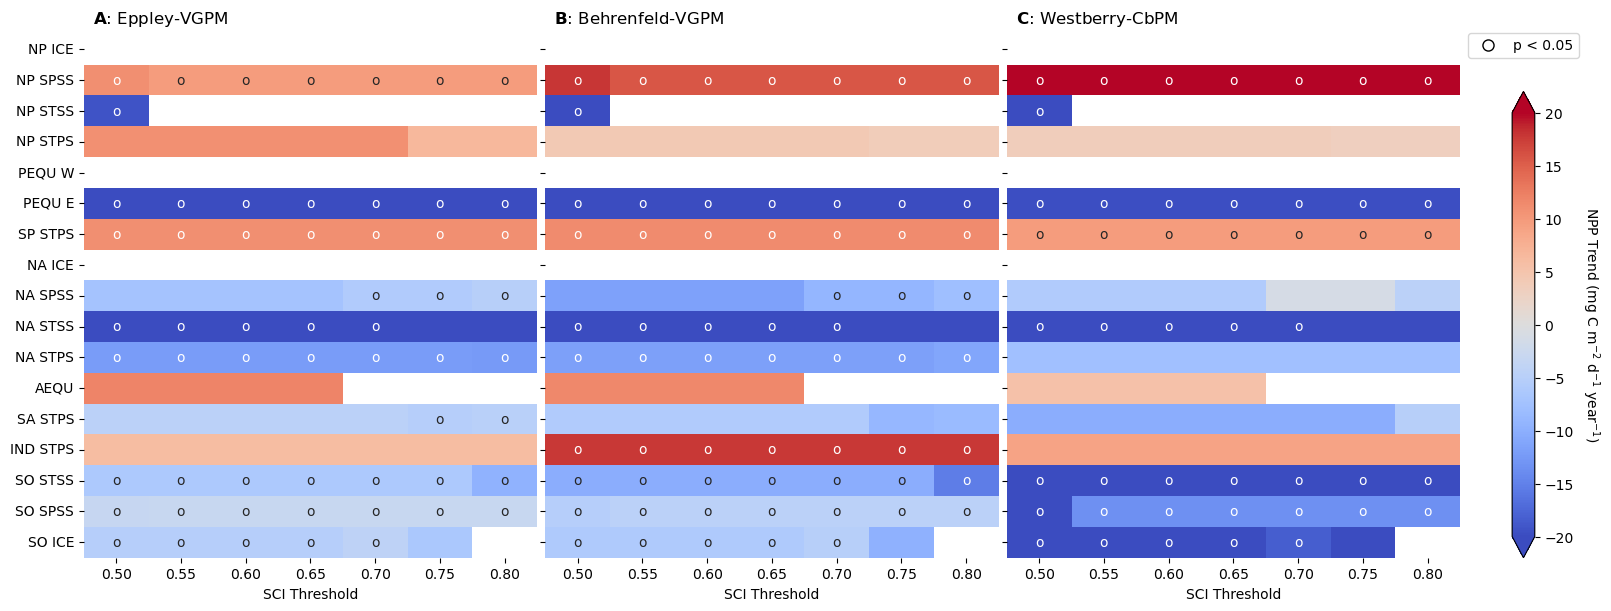

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


In [21]:
fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_WITH_PAR.nc'
ds1a = xr.open_dataset(fname, decode_times=True)

fname = f'{resdir}/BGC_ARGO_NPP_RESULTS_XING_CLIM_KD490_FLOATS_NO_PAR.nc'
ds1b = xr.open_dataset(fname, decode_times=True)

ds1 = xr.merge([ds1a, ds1b])
threshold_date = np.datetime64('2025-01-01')
mask =  (ds1.DATETIME < threshold_date)
ds1 = ds1.where(mask.compute(), drop=True)

thresholds = np.arange(0.5, 0.85, 0.05)  # from 0 to 0.8

ds_vgpm1 = ds1[['DATETIME', 'BIOME', 'EPPLEY_VGPM']].to_dataframe().dropna().reset_index(drop=True)
sensitivity_vgpm1 = run_sci_sensitivity_analysis(ds_vgpm1, var='EPPLEY_VGPM', model='Huber-Loss', normalise=False, thresholds=thresholds)

ds_vgpm2 = ds1[['DATETIME', 'BIOME', 'BEHRENFELD_VGPM']].to_dataframe().dropna().reset_index(drop=True)
sensitivity_vgpm2 = run_sci_sensitivity_analysis(ds_vgpm2, var='BEHRENFELD_VGPM', model='Huber-Loss', normalise=False, thresholds=thresholds)

ds_cbpm2 = ds1[['DATETIME', 'BIOME', 'WESTBERRY_CBPM']].to_dataframe().dropna().reset_index(drop=True)
sensitivity_cbpm2 = run_sci_sensitivity_analysis(ds_cbpm2, var='WESTBERRY_CBPM', model='Huber-Loss', normalise=False, thresholds=thresholds)

bname = ['NP ICE', 'NP SPSS', 'NP STSS', 'NP STPS', 'PEQU W', 'PEQU E', 'SP STPS', 'NA ICE',
         'NA SPSS', 'NA STSS', 'NA STPS', 'AEQU', 'SA STPS', 'IND STPS', 
         'SO STSS', 'SO SPSS', 'SO ICE']

fig = plt.figure(figsize=[16, 6], constrained_layout=True)
gs = plt.GridSpec(2, 4, figure=fig, width_ratios=[1, 1, 1, 0.05], height_ratios=[0.05, 1])

ax_legend = fig.add_subplot(gs[0, 3])
ax_legend.axis('off')
sig_marker = Line2D([0], [0],
                    lw=0,
                    marker='o',
                    markerfacecolor='w',
                    markeredgecolor='k',
                    markersize=8,
                    label='p < 0.05')

legend_handles = [sig_marker]

# Custom legend
ax_legend.legend(handles=legend_handles, loc='center', ncol=1, fontsize=10)

# Create axes for colorbar (small left column)
cax = fig.add_subplot(gs[1, 3])

# Axes for heatmaps
ax0 = fig.add_subplot(gs[:, 0])
ax1 = fig.add_subplot(gs[:, 1])
ax2 = fig.add_subplot(gs[:, 2])

# Common cmap and norm for all heatmaps
cmap = 'coolwarm'
vmin, vmax = -20, 20
nor = mpl.colors.Normalize(vmin=vmin, vmax=vmax)

for ax, ds in zip([ax0, ax1, ax2], [sensitivity_vgpm1, sensitivity_vgpm2, sensitivity_cbpm2]):
    df_plot = ds.reset_index()
    pivot = df_plot.pivot(index='biome', columns='sci_criteria', values='slope')
    mask = df_plot.pivot(index='biome', columns='sci_criteria', values='p_value') < 0.05
    annot = mask.replace({True: 'o', False: ''})
    
    sns.heatmap(
        pivot, cmap=cmap, center=0, vmin=vmin, vmax=vmax,
        annot=annot, fmt='',
        cbar=False,
        ax=ax
    )

ax0.set_ylabel('')
ax1.set_ylabel('')
ax2.set_ylabel('')

ax0.set_yticklabels(bname, rotation=0)
ax1.set_yticklabels('')
ax2.set_yticklabels('')

ax0.set_xlabel('SCI Threshold')
ax1.set_xlabel('SCI Threshold')
ax2.set_xlabel('SCI Threshold')

ax0.set_xticklabels(['0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80'], rotation=0)
ax1.set_xticklabels(['0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80'], rotation=0)
ax2.set_xticklabels(['0.50', '0.55', '0.60', '0.65', '0.70', '0.75', '0.80'], rotation=0)

# Create a ScalarMappable for the colorbar with the same cmap and norm
sma = mpl.cm.ScalarMappable(cmap=cmap, norm=nor)
sma.set_array([])  # dummy array for colorbar

# Add the colorbar on the left axis, vertical orientation
fig.colorbar(sma, cax=cax, orientation='vertical', extend='both')

# Optionally, set colorbar label
cax.set_ylabel('NPP Trend (mg C m$^{-2}$ d$^{-1}$ year$^{-1}$)', rotation=270, labelpad=20)

ax0.text(0.02, 1.02, r'$\bf{{A}}$: Eppley-VGPM', transform=ax0.transAxes, fontsize=12)
ax1.text(0.02, 1.02, r'$\bf{{B}}$: Behrenfeld-VGPM', transform=ax1.transAxes, fontsize=12)
ax2.text(0.02, 1.02, r'$\bf{{C}}$: Westberry-CbPM', transform=ax2.transAxes, fontsize=12)

plt.show()

fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S05.png", bbox_inches='tight', dpi=300)
fig.savefig(f"{figdir}/BGC_ARGO_NPP_PAPER_FIGURE_S05.eps", bbox_inches='tight', dpi=300)